In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(ggthemes)
    library(uwot)
    library(pheatmap)
    library(harmony)
    library(tibble)
    library(tidyr)
    library(rlang)
    library(purrr)
    library(glue)
})
source('typing_utils.r')

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following object is masked from ‘package:rlang’:

    :=


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




# Load data

In [2]:
# load AMP
amp.p2.counts.path <- "/data/srlab/fzhang/amp/results/2020_01_22_AMP_cite_seq_QC/mRNA_exprs_2020-01-24.rds"
amp.p2.meta.path <- "/data/srlab1/public/srcollab/AMP_Phase_2/singlecell_result/fine_cluster_all_celltypes_82samples_2021-04-23.rds"
sc <- readRDS(amp.p2.counts.path)
sc.meta <- readRDS(amp.p2.meta.path)

sc.meta <- sc.meta %>%
  filter(cell_type %in% c("Stromal cell"))
names(sc.meta)[2] <- 'sid'
sc <- sc[, rownames(sc.meta)]
dim(sc)

[1] 33538 88031

In [3]:
# load both sublining and lining fibros from xenium
sl.fibrocell.path <- "out_rds/_sublining_fibroblast.rds"
l.fibrocell.path <- "out_rds/_lining_fibroblast.rds"
sl.fibrocell <- readRDS(sl.fibrocell.path)
sl.fibrocell$originaltype <- "Sublining"
l.fibrocell <- readRDS(l.fibrocell.path)
l.fibrocell$originaltype <- "Lining"
xen <- merge(
  sl.fibrocell,
  y = l.fibrocell,
  project = "fibro"
)
xen <- JoinLayers(xen)
xen

An object of class Seurat 
4008 features across 954603 samples within 1 assay 
Active assay: RNA (4008 features, 0 variable features)
 2 layers present: data, counts

In [4]:
# filter AMPp2 to the same set of genes in the same order and convert to Seurat
common <- intersect(rownames(sc), rownames(xen))
sc <- CreateSeuratObject(sc[common, ],
                 meta.data = sc.meta,
                 project = 'AMPp2')
sc <- NormalizeData(sc, normalization.method = "LogNormalize", scale.factor = median(sc$nCount_RNA), verbose = F)

In [5]:
# define lining vs sublining
fibro_to_layer <- c(
  "F-1: SFRP1+ sublining"    = "Sublining",
  "M-u1: SERPINF1+ sublining"= "Sublining",
  "F-2: CD34+ sublining"     = "Sublining",
  "F-5: CD82+ sublining"     = "Sublining",
  "F-3: CLIC5+ lining"       = "Lining",
  "F-0: VCAM1+ lining"       = "Lining",
  "F-8: DKK3+ sublining"     = "Sublining",
  "F-7: NOTCH3+ sublining"   = "Sublining",
  "F-6: Proliferating sublining" = "Sublining",
  "F-9: DKK3+ lining"        = "Lining",
  "F-4: POSTN+ sublining"    = "Sublining",
  "M-u2: SMAD1+ mural"       = NA
)

sc@meta.data$cell_type <- unname(
  fibro_to_layer[as.character(sc@meta.data$cluster_name)]
)
sc <- sc[, !is.na(sc$cell_type)]
sc

An object of class Seurat 
4004 features across 87926 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 2 layers present: counts, data

# Call lining vs sublining fibroblasts

## Get discriminatory genes from sc

In [6]:
# select genes that differentiate L vs SL fibros in AMPp2
res <- FindHVGsFromGroups(sc, group_var = "cell_type", logFC_thresh = 0.1)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 693 


row,Lining,Sublining
<int>,<chr>,<chr>
1,PRG4,CXCL12
2,CRTAC1,DPT
3,CLU,ASPN
4,HTRA1,AEBP1
5,MMP3,COL6A1
6,HBEGF,WISP2
7,TIMP3,THY1
8,ERRFI1,MFAP5
9,DEFB1,IGF1


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 954603 cells 
  Single-cell counts dimensions: 4004 genes x 87926 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 1042529 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 2 layers present: counts.xen, counts.sc
  Merged object dimensions: 4004 genes x 1042529 cells 
  Cells by modality: 

    sc    xen 
 87926 954603 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 208 
  SC median nCount_RNA: 2351 
  Selected normalization scale factor: 1279.5 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 693 
  HVGs present in merged object: 693 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  COL6A1, AEBP1, COL5A1, THY1, CXCL12, THBS2, C3, ASPN, COMP, GAS6 
	   OLFML3, PDGFRB, MMP14, CDH11, LOXL1, NID1, DPT, SFRP4, PTGFRN, IGF1 
	   WISP2, GXYLT2, SPON2, FBLN2, TMEM119, SFRP1, TPM1, COL5A2, POSTN, CTSK 
Negative:  PRG4, CRTAC1, ERRFI1, HTRA1, HBEGF, MMP3, TIMP3, SEMA5A, NTN4, GPR1 
	   CLU, GABRA4, TSPAN7, VEGFC, S100A4, SEMA3A, CD55, SEMA3C, SEMA3E, SOX5 
	   ITGA6, MMP1, C2orf40, VCAM1, SELP, COLEC12, APP, SLC9A3R1, PLEKHA1, MET 
PC_ 2 
Positive:  COMP, POSTN, MAP1B, MYLK, PALLD, WWTR1, ACTA2, DIO2, GAS6, CXCL12 
	   SFRP4, PDE5A, NID1, CTHRC1, TGFB3, OLFM2, FGFBP2, NEXN, ANGPT1, SFRP1 
	   IL32, MME, NOTCH3, C3, PI16, SLIT3, SMOC1, HES4, DPT, DDR2 
Negative:  SEMA3C, ERRFI1, PRG4, VCAM1, TIMP3, ANPEP, CRTAC1, APP, ABI3BP, VEGFC 
	   LRP1, HTRA1, S1PR3, HBEGF, MRC2, FSTL1, COLEC12, SOX5, CD55, GPR1 
	   SEMA3A, ANXA2, CTGF, AXL, NPTN, PLEKHA1, PDPN, SGK1, FOXO1, TRIM47 
PC_ 3 
Positive:  CXCL12, AHR, CP, SLC5A3, EPHX1, FZD4, ADAMTS1, C3, CFH, SFRP1 
	   

  Printing PCA diagnostic plots... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



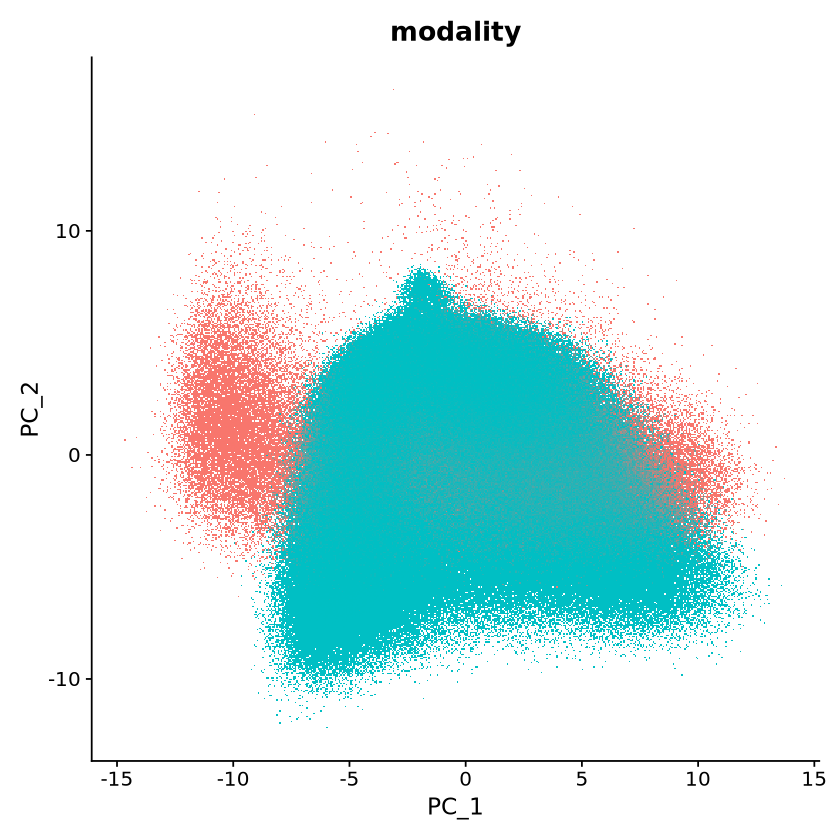

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[6/7] Running Harmony... 


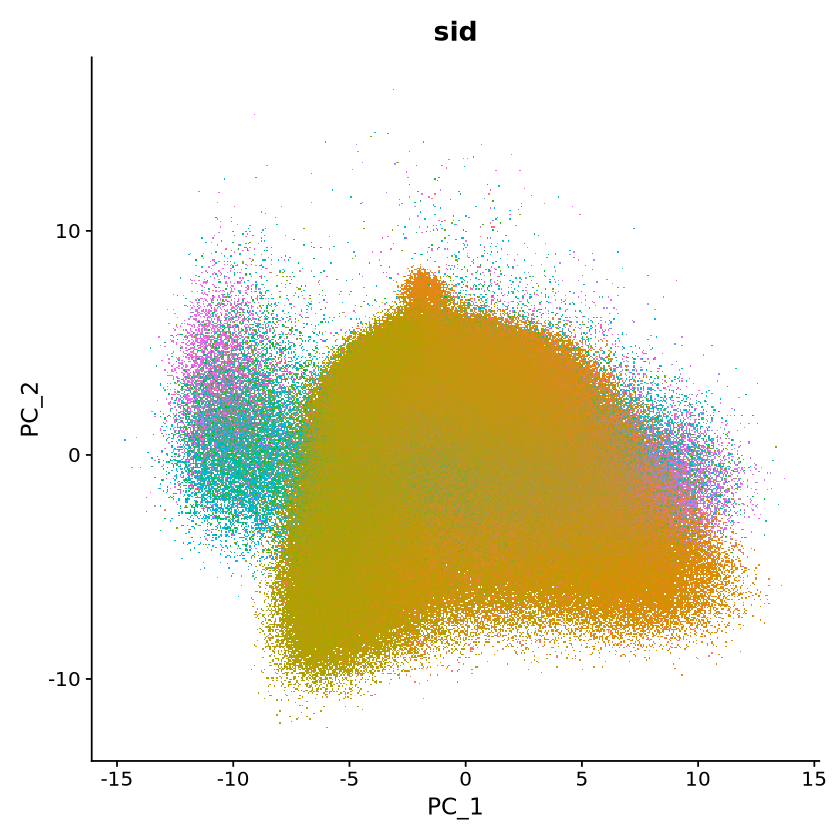

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 52126450)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


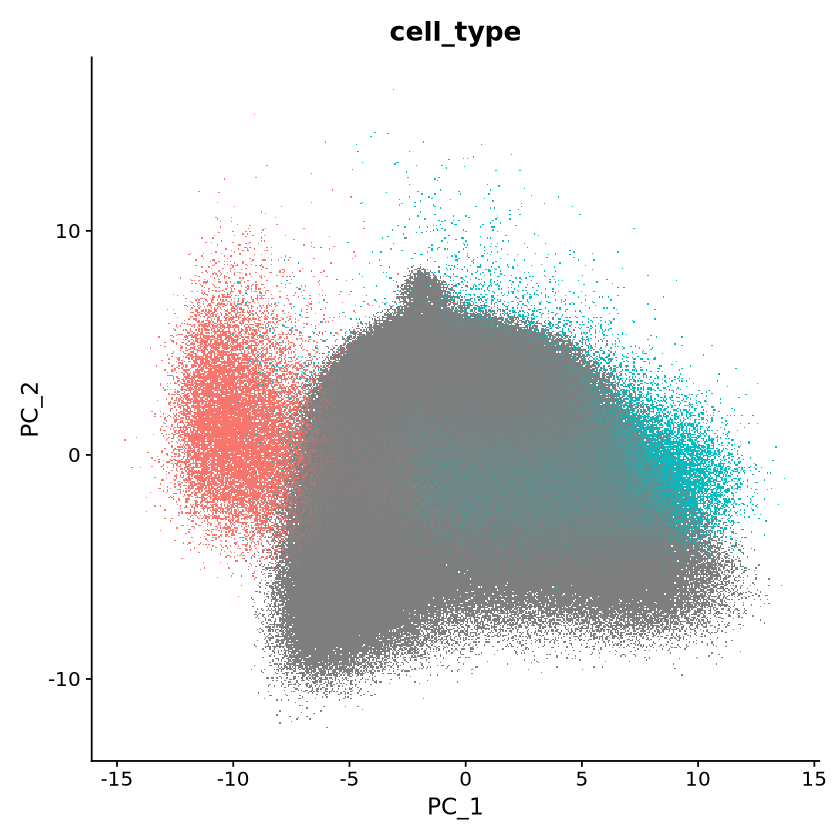

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



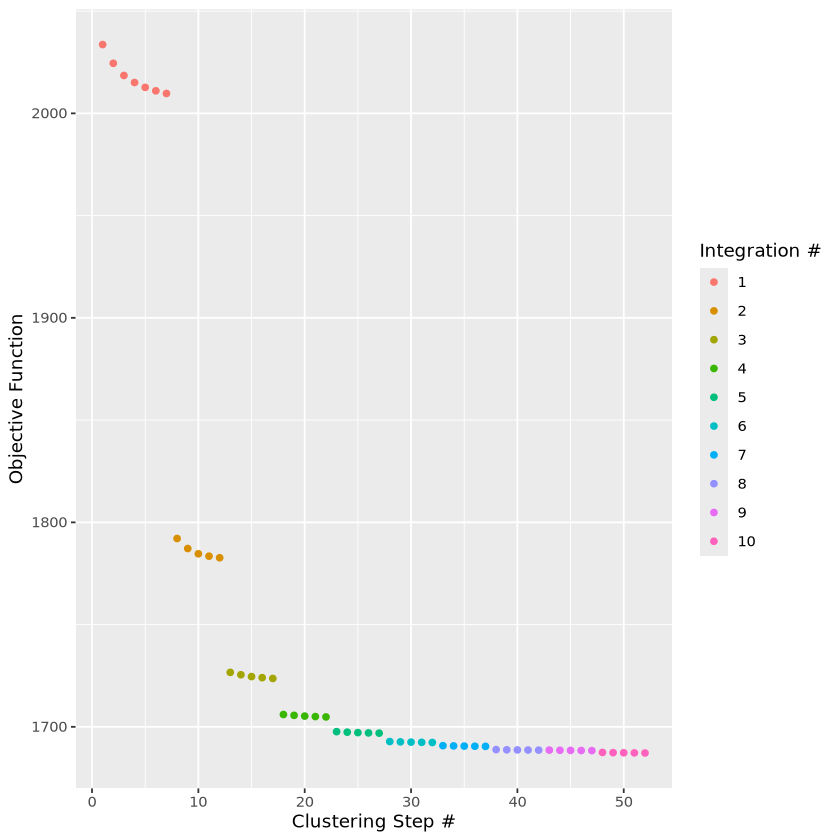

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



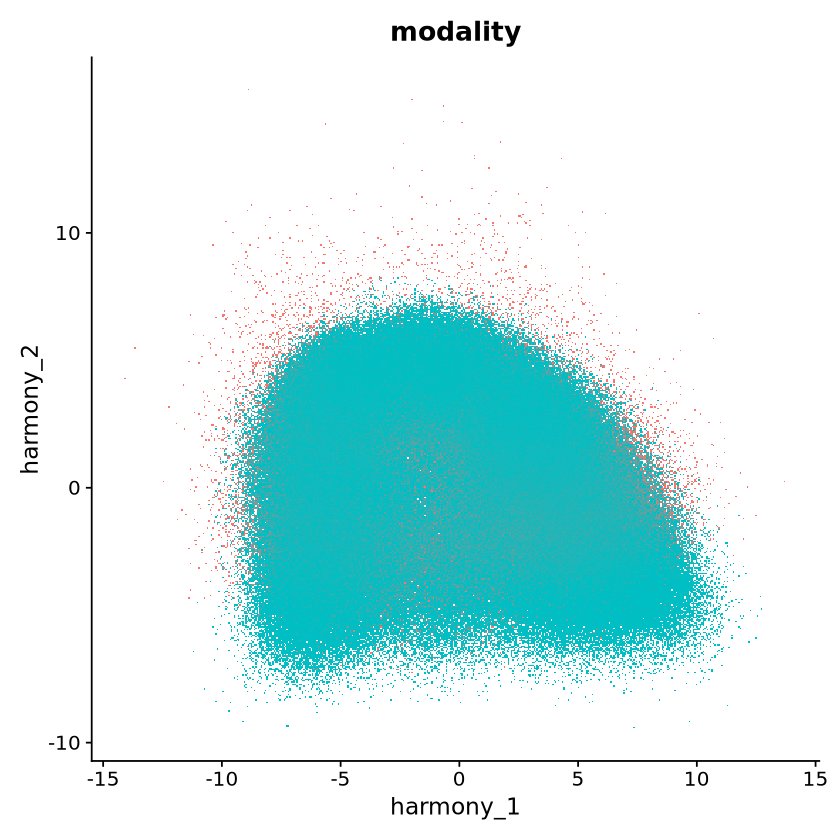

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[7/7] Running UMAP on the Harmony reduction... 


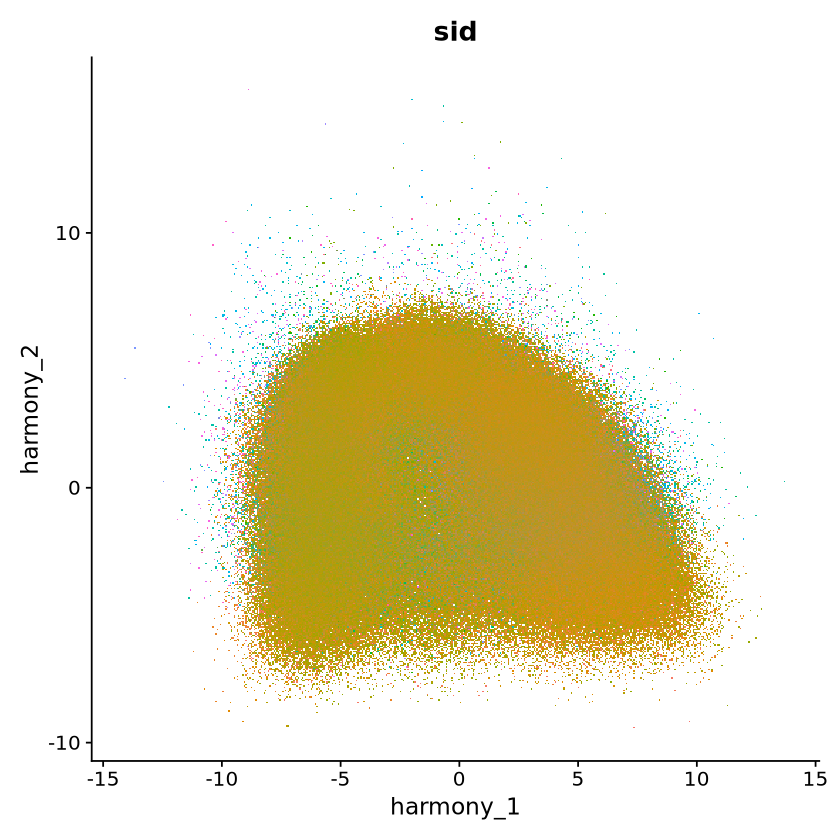

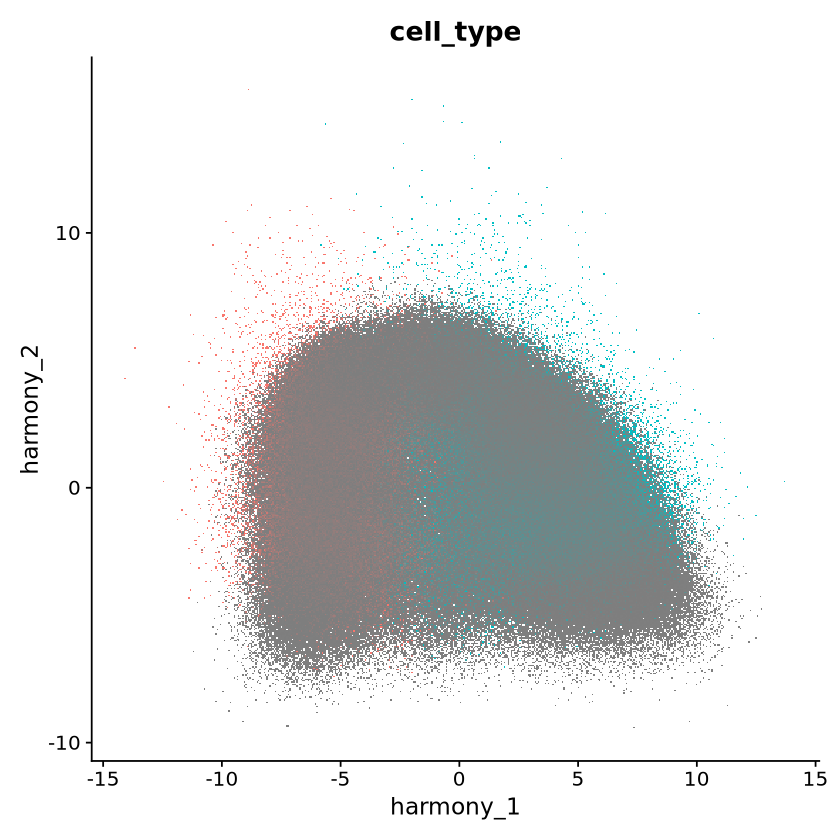

In [7]:
f_merged <- BuildIntegratedReference(
    xen = xen,
    sc = sc,
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cell_type"
)

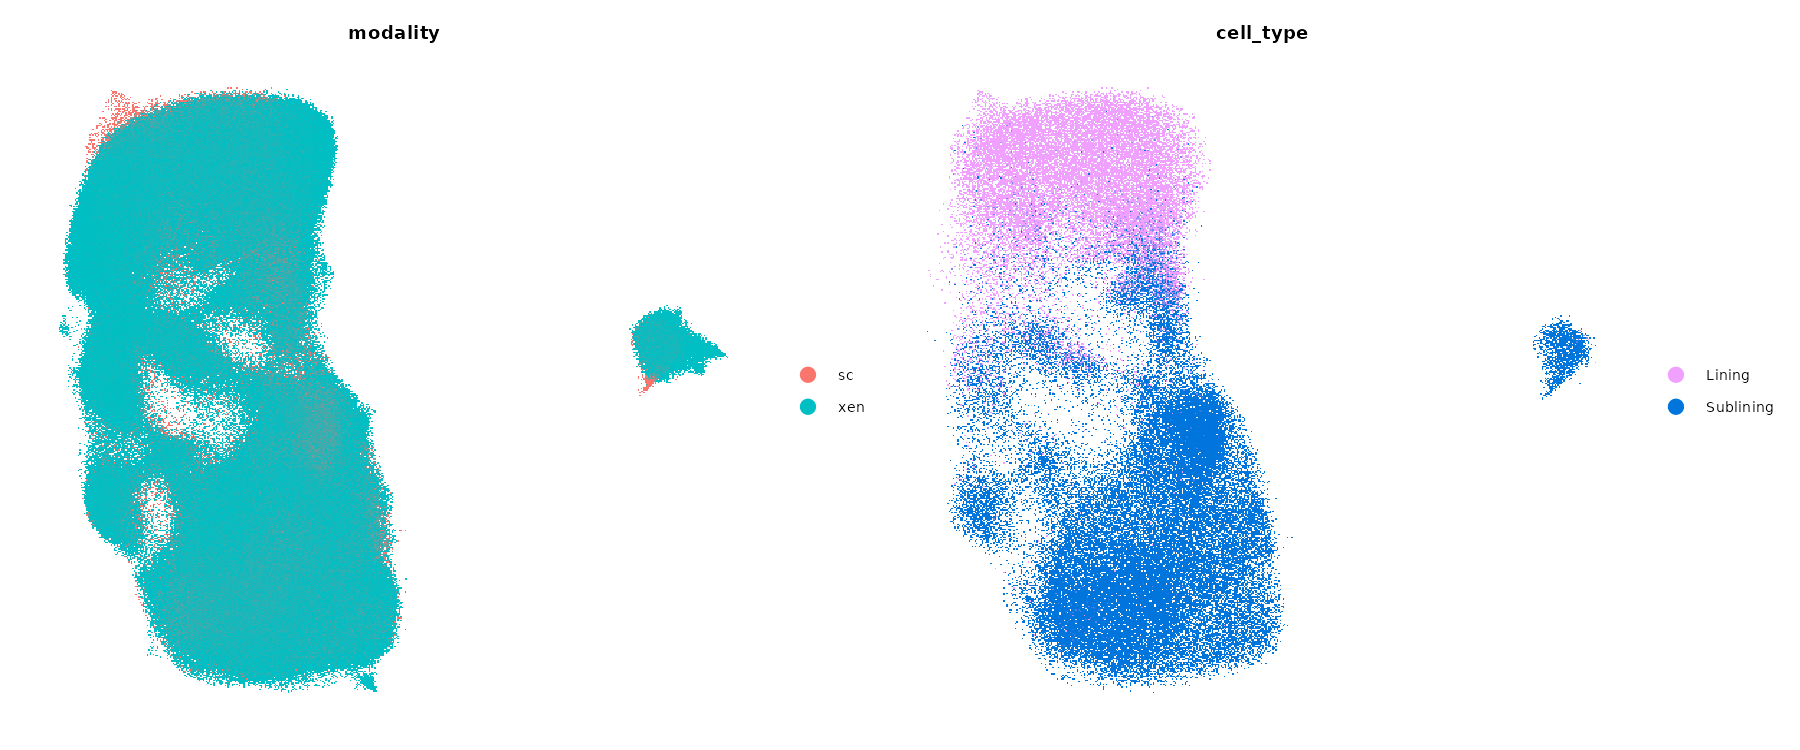

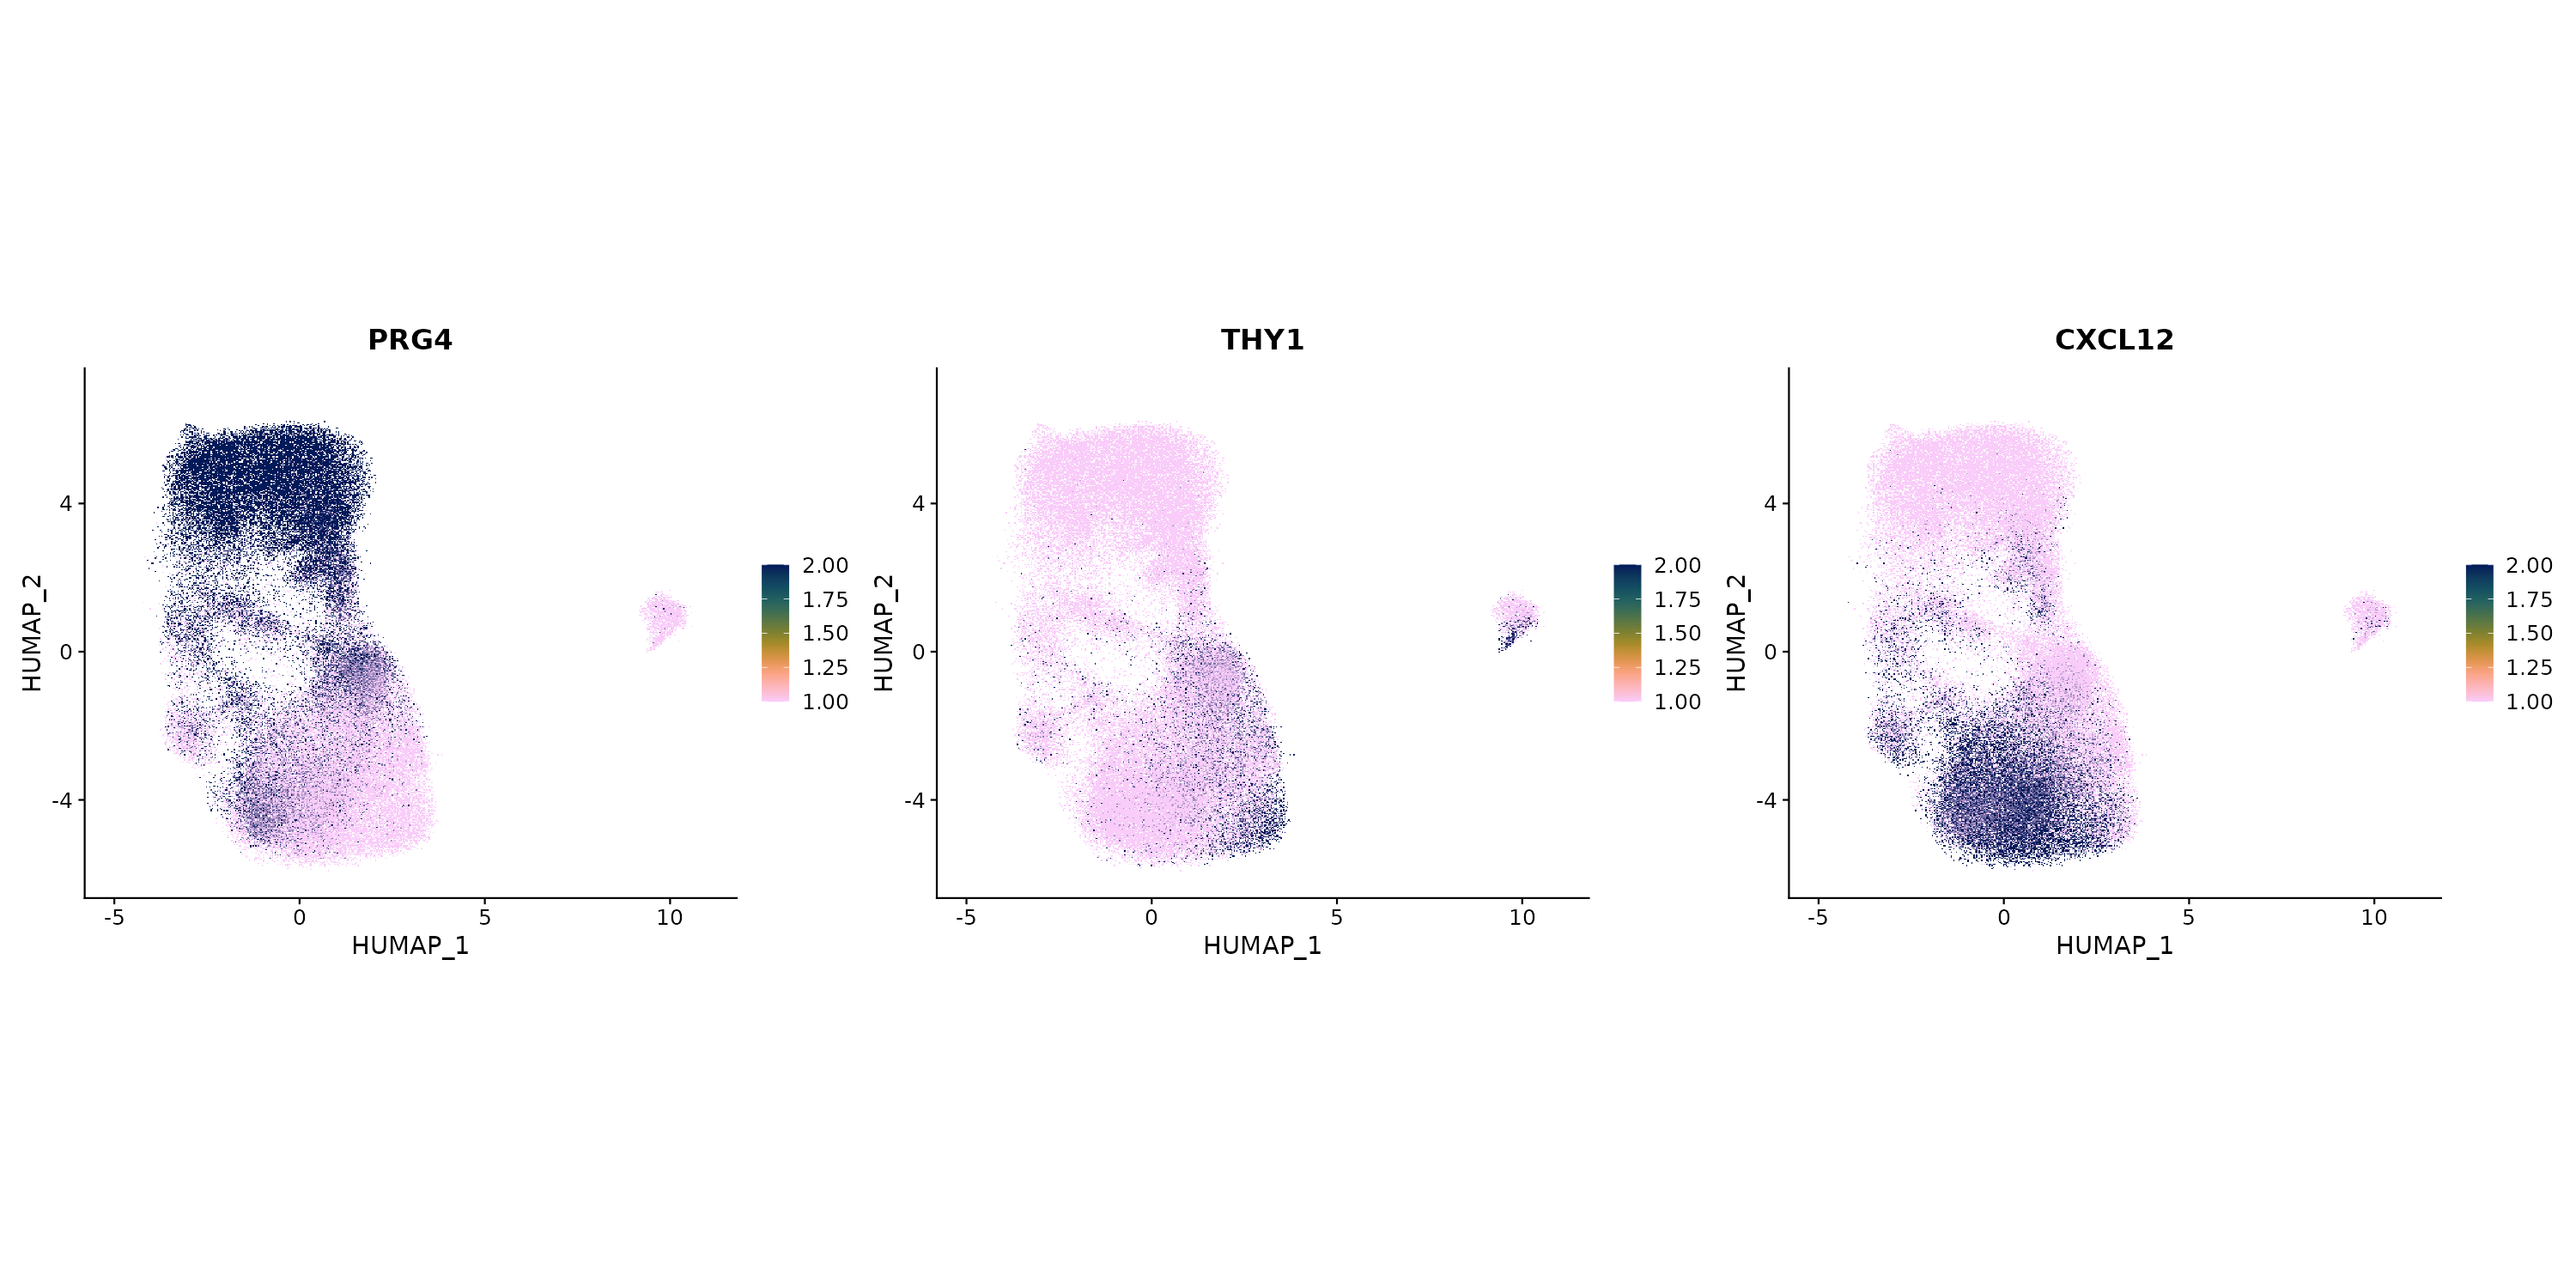

In [8]:
ShowTransferDiagnostics(
    merged = f_merged,
    annotation_var = "cell_type",
    genes_to_visualize = c("PRG4", "THY1", "CXCL12")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cell_type 
  Using n_neighbors = 50 and min_ratio = 1.1 

[2/4] Computing nearest-neighbor graph from Harmony embedding... 
  Graph computation complete. 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cell_type 
  Xen cells without transferred labels: 109402 

[4/4] Plotting unlabeled cells and final xen label map... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



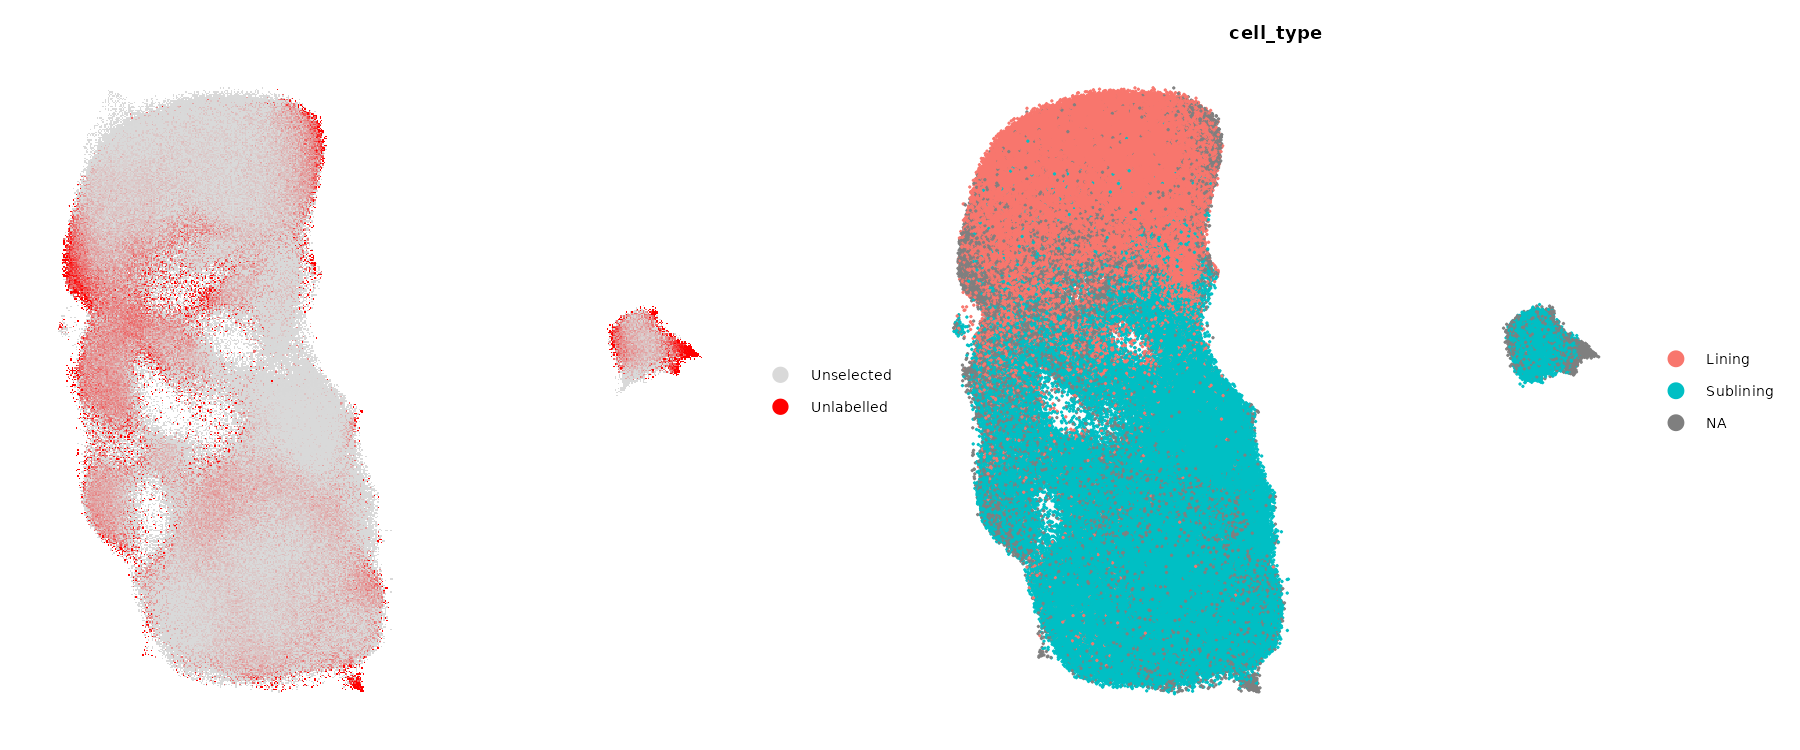

In [9]:
source('typing_utils.r')
f_merged <- TransferLabelsGraph(
    merged = f_merged,
    annotation_var = "cell_type",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [17]:
# verify that the new lining vs sublining assignment is better than the one from the coarse typing notebook
expr <- GetAssayData(xen, layer = "data")
clusters.markers.original <- presto::wilcoxauc(expr, xen[["originaltype"]][,1])

expr <- GetAssayData(f_merged[, f_merged$modality == "xen"], layer = "data")
clusters.markers.new <- presto::wilcoxauc(expr, f_merged[, f_merged$modality == "xen"][["cell_type"]][,1])

expr <- GetAssayData(f_merged[, f_merged$modality == "sc"], layer = "data")
clusters.markers.truth <- presto::wilcoxauc(expr, f_merged[, f_merged$modality == "sc"][["cell_type"]][,1])

[1] 0.7938913

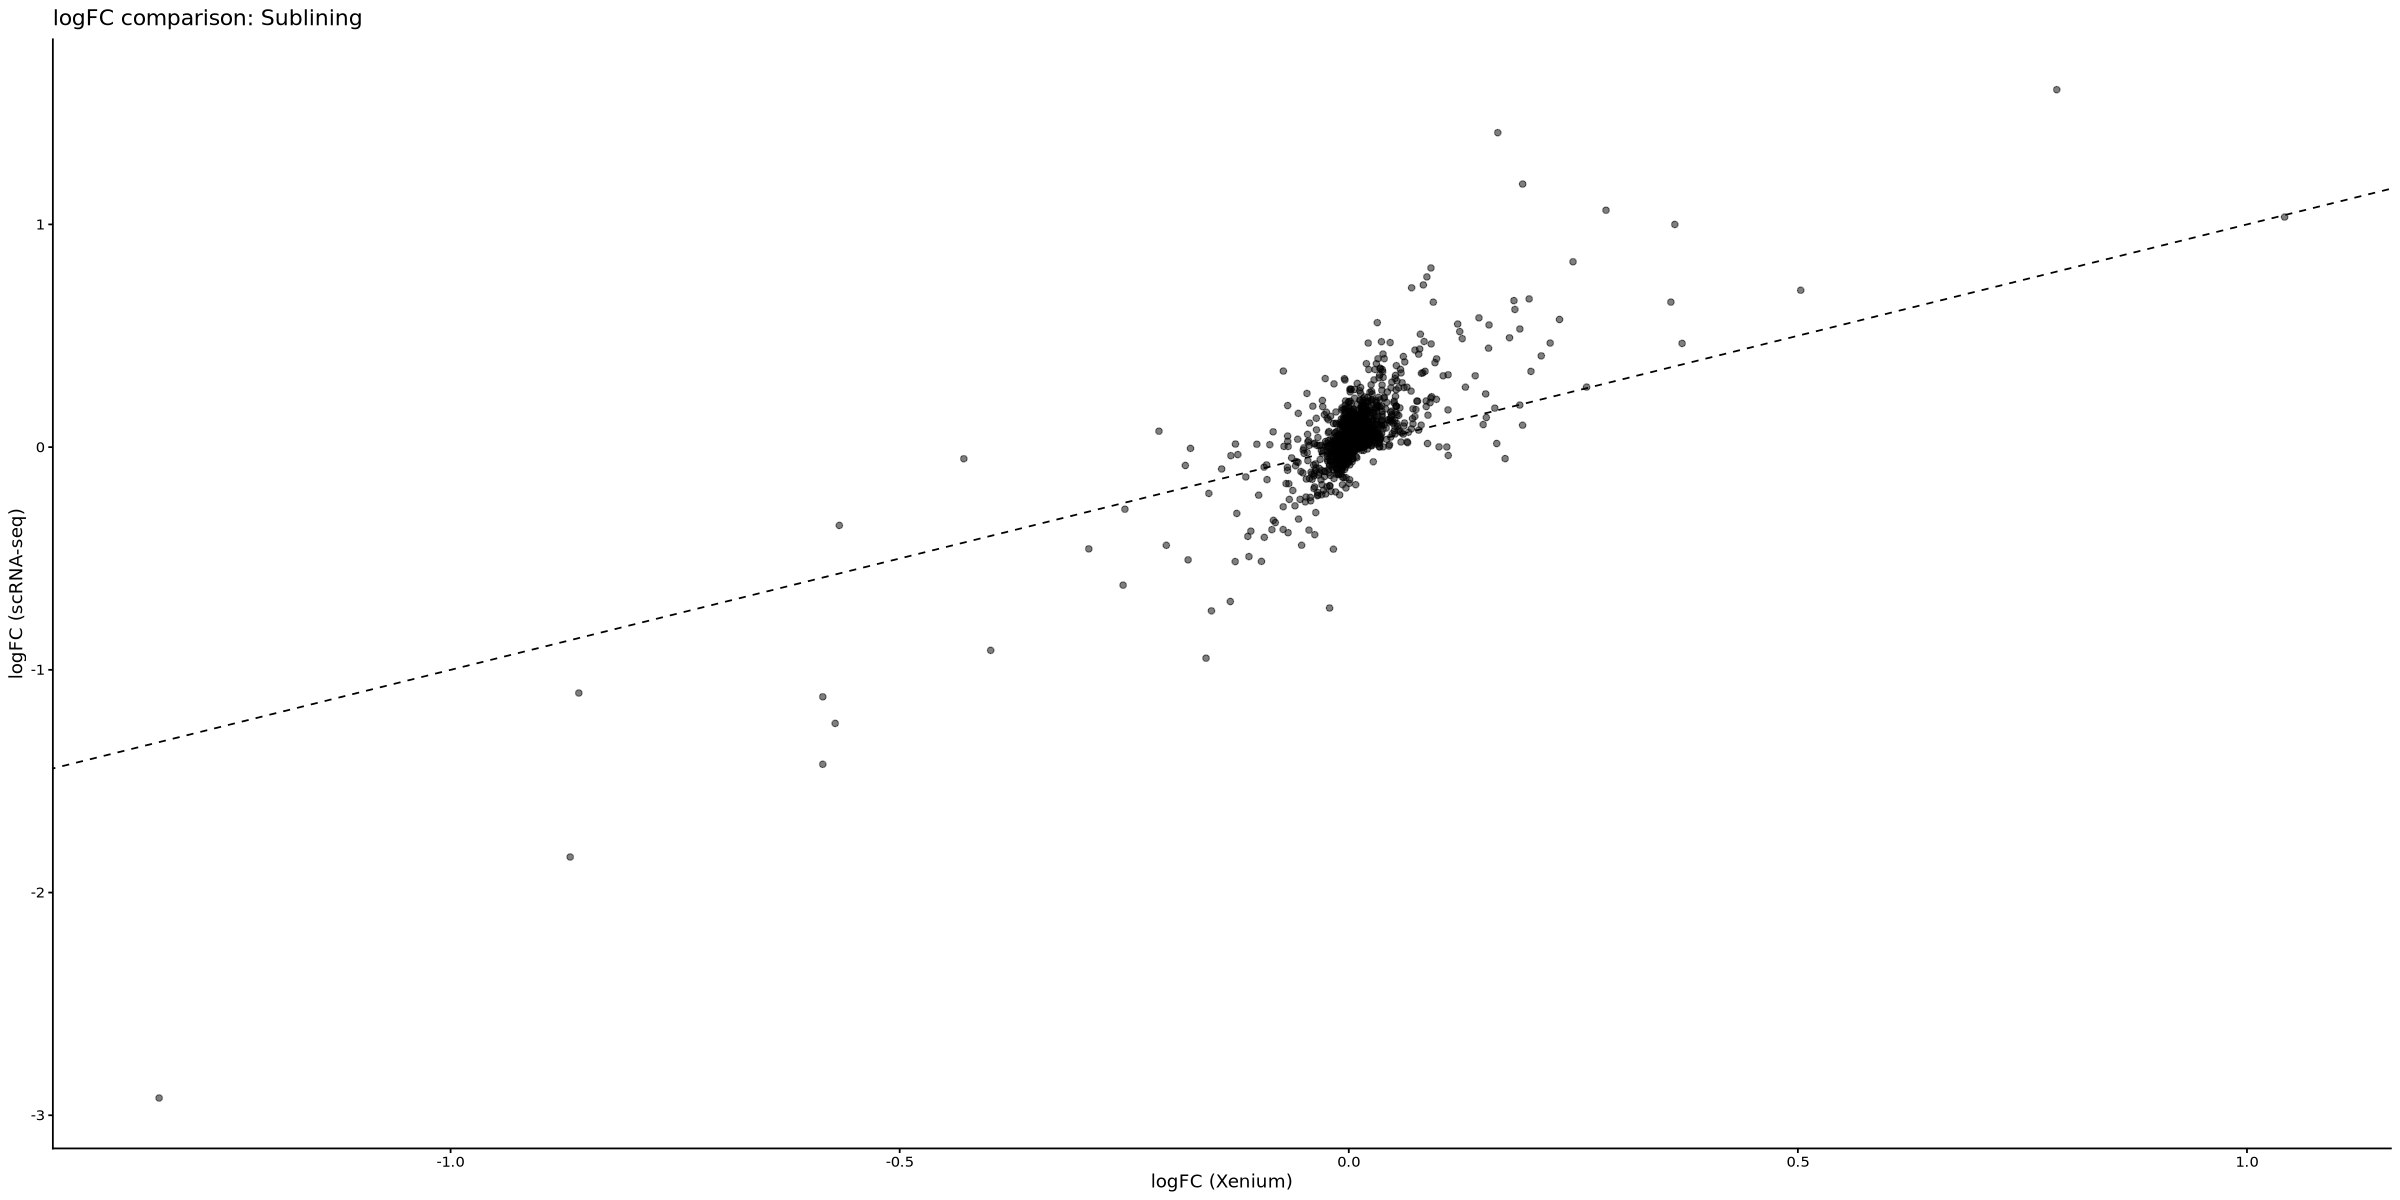

In [22]:
# old sl vs l assignment
PlotStateLogFCComparison(
  markers_sc = clusters.markers.truth,
  markers_xen = clusters.markers.original,
  cell_state = "Sublining"
)$correlation

[1] 0.8532797

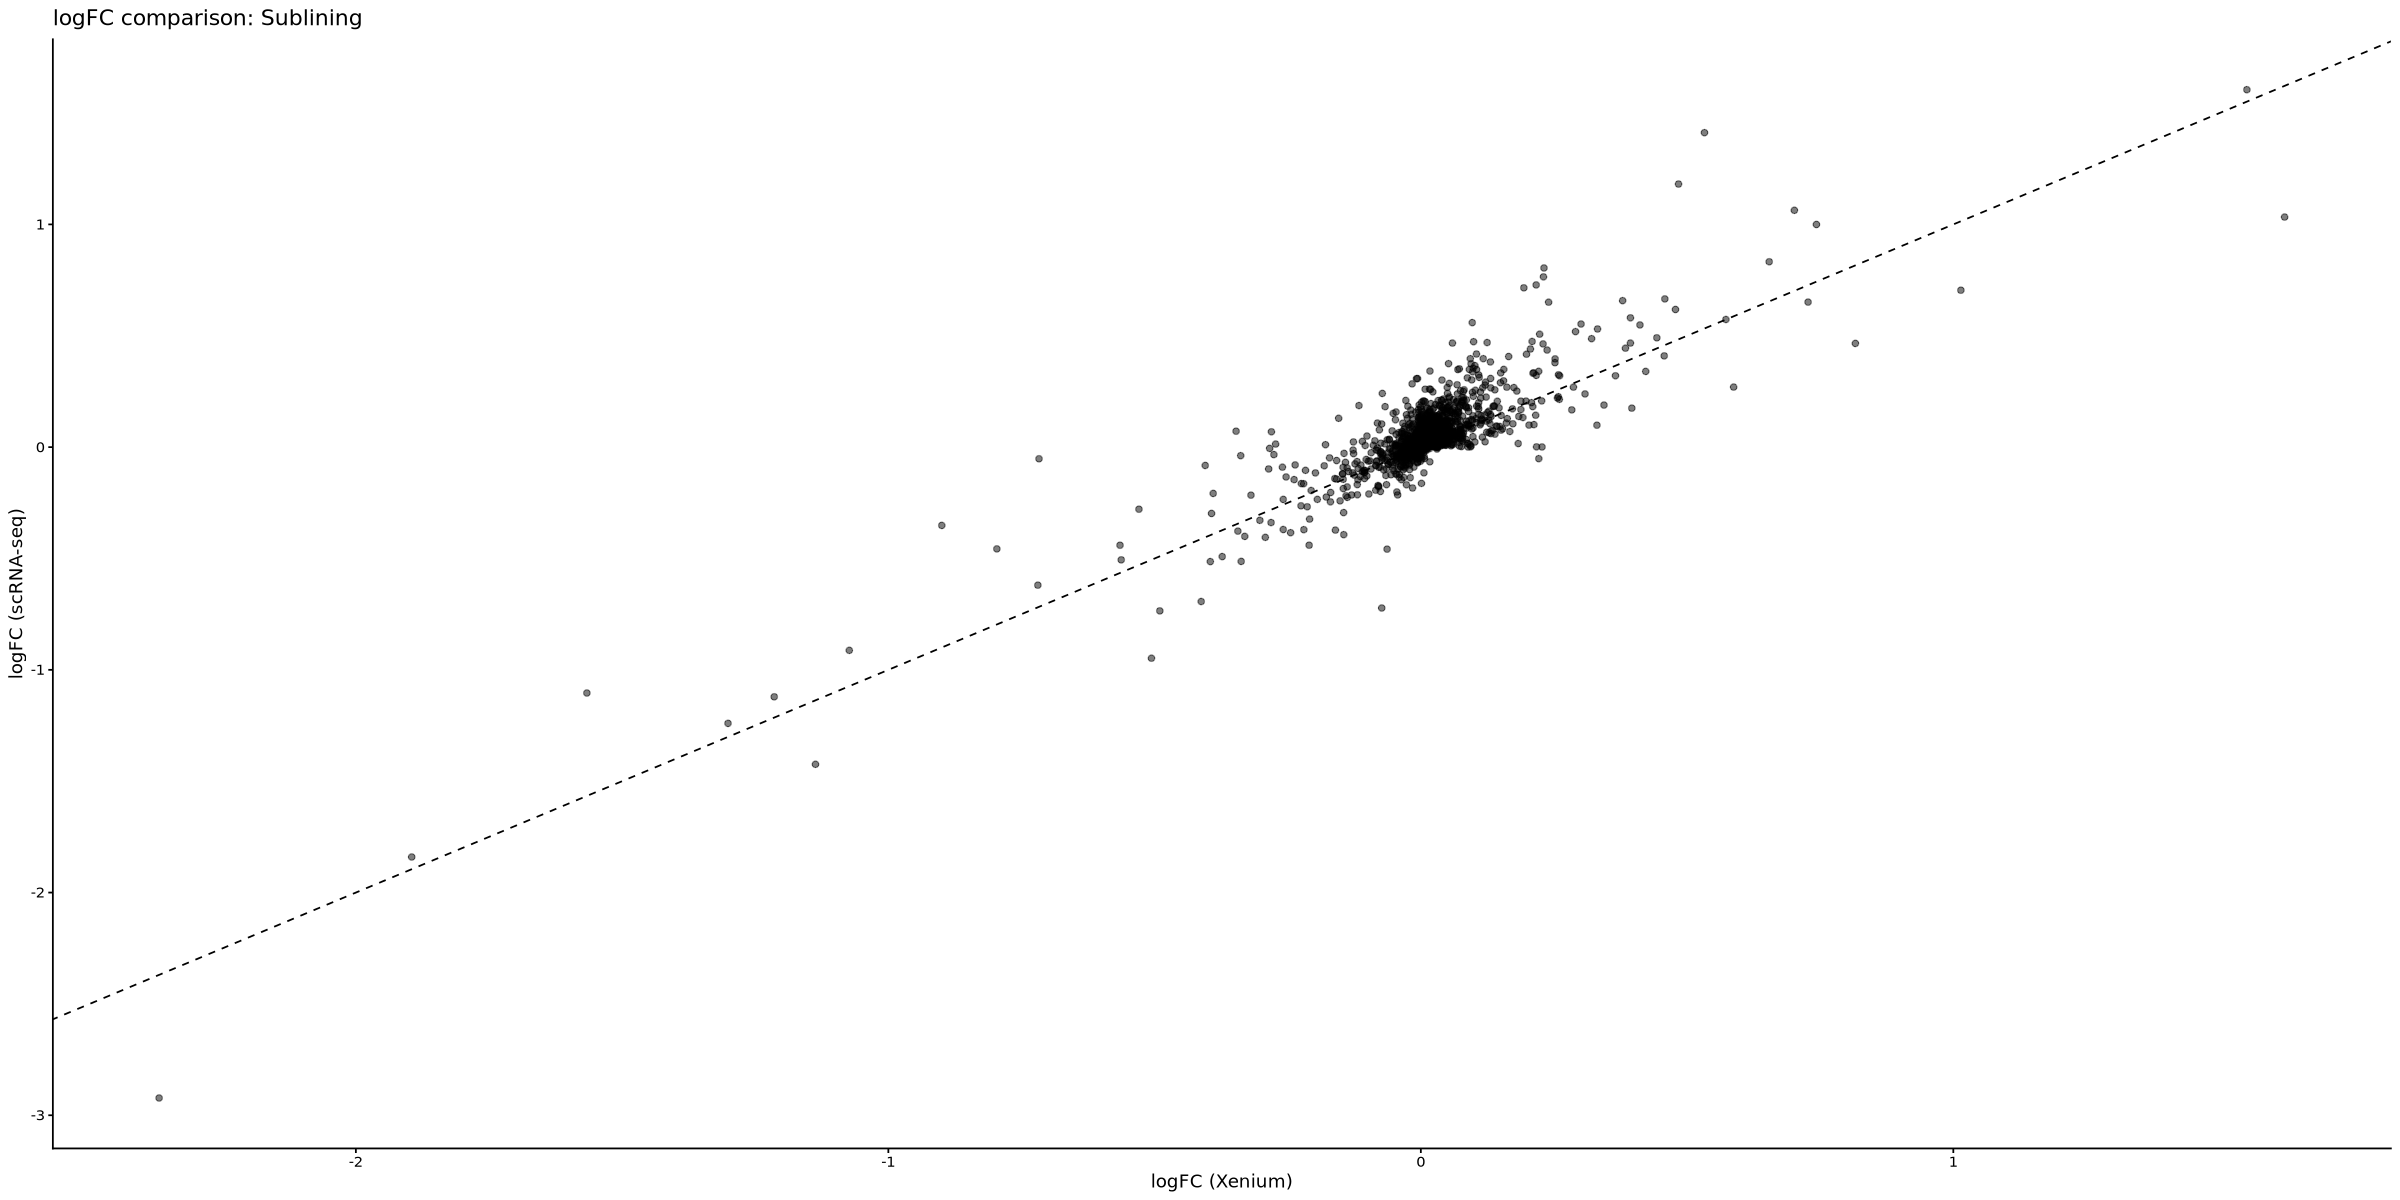

In [23]:
# new sl vs l assignment
PlotStateLogFCComparison(
  markers_sc = clusters.markers.truth,
  markers_xen = clusters.markers.new,
  cell_state = "Sublining"
)$correlation

In [10]:
# examine top markers from new assignment
ShowClusterMarkers(f_merged[, f_merged$modality == "xen"], "cell_type", n_show = 5)

Removing NA values from labels



row,Lining,Sublining
<int>,<chr>,<chr>
1,PRG4,COL6A1
2,CRTAC1,CXCL12
3,MMP3,C3
4,HTRA1,COL5A1
5,TIMP3,WISP2


Removing NA values from labels



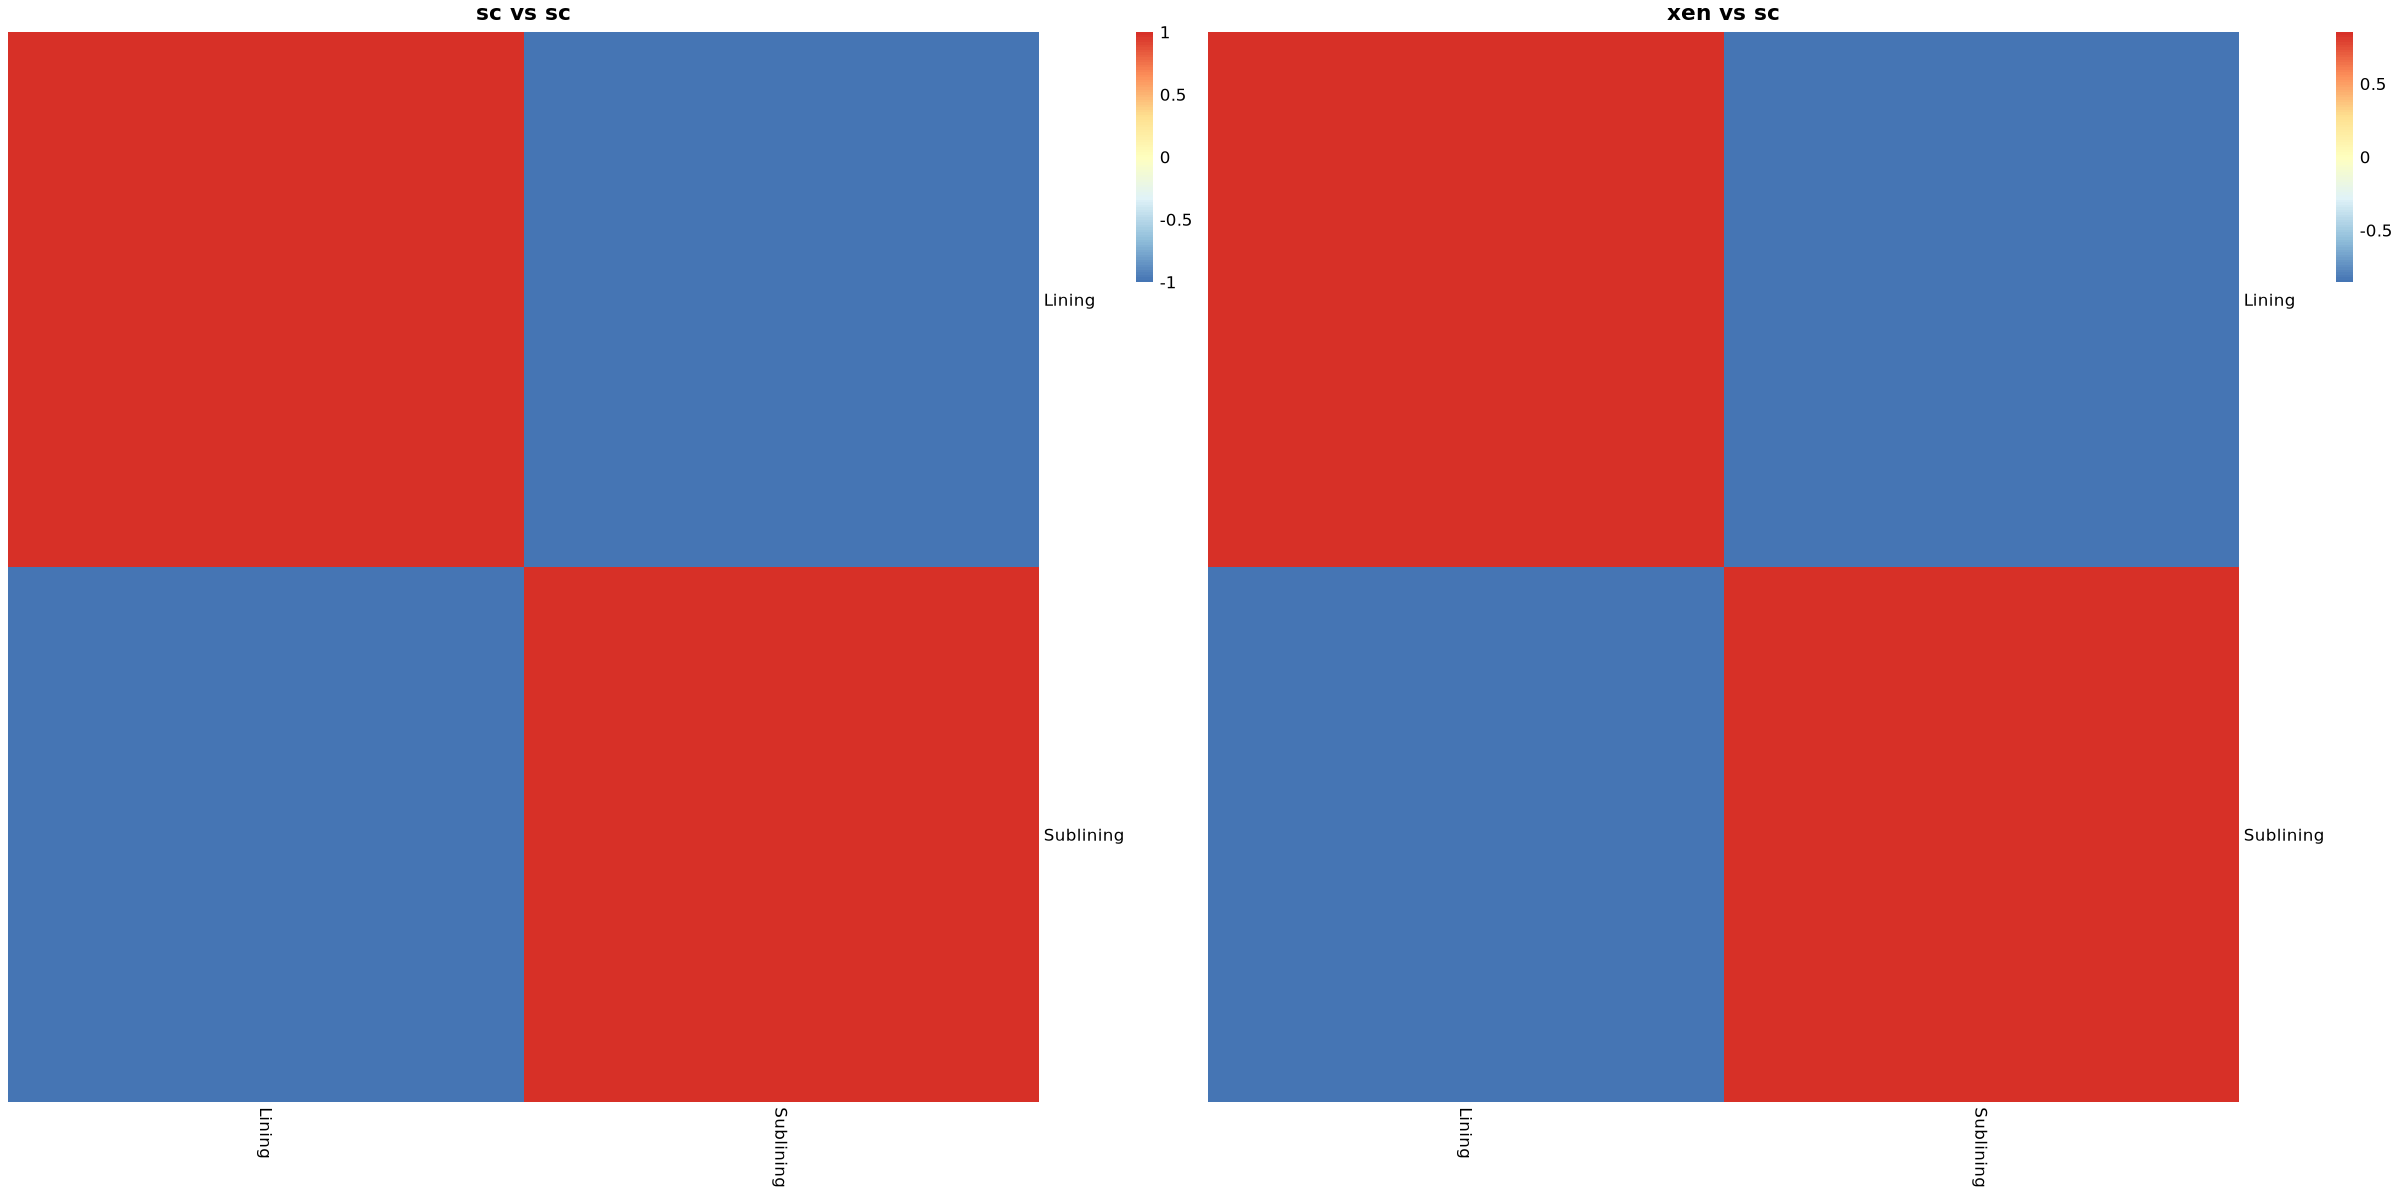

In [11]:
source('typing_utils.r')
res <- CompareMarkerCorrelations(f_merged[,f_merged$modality == "xen"],
                                 f_merged[,f_merged$modality == "sc"], "cell_type")

[1] 0.8532797

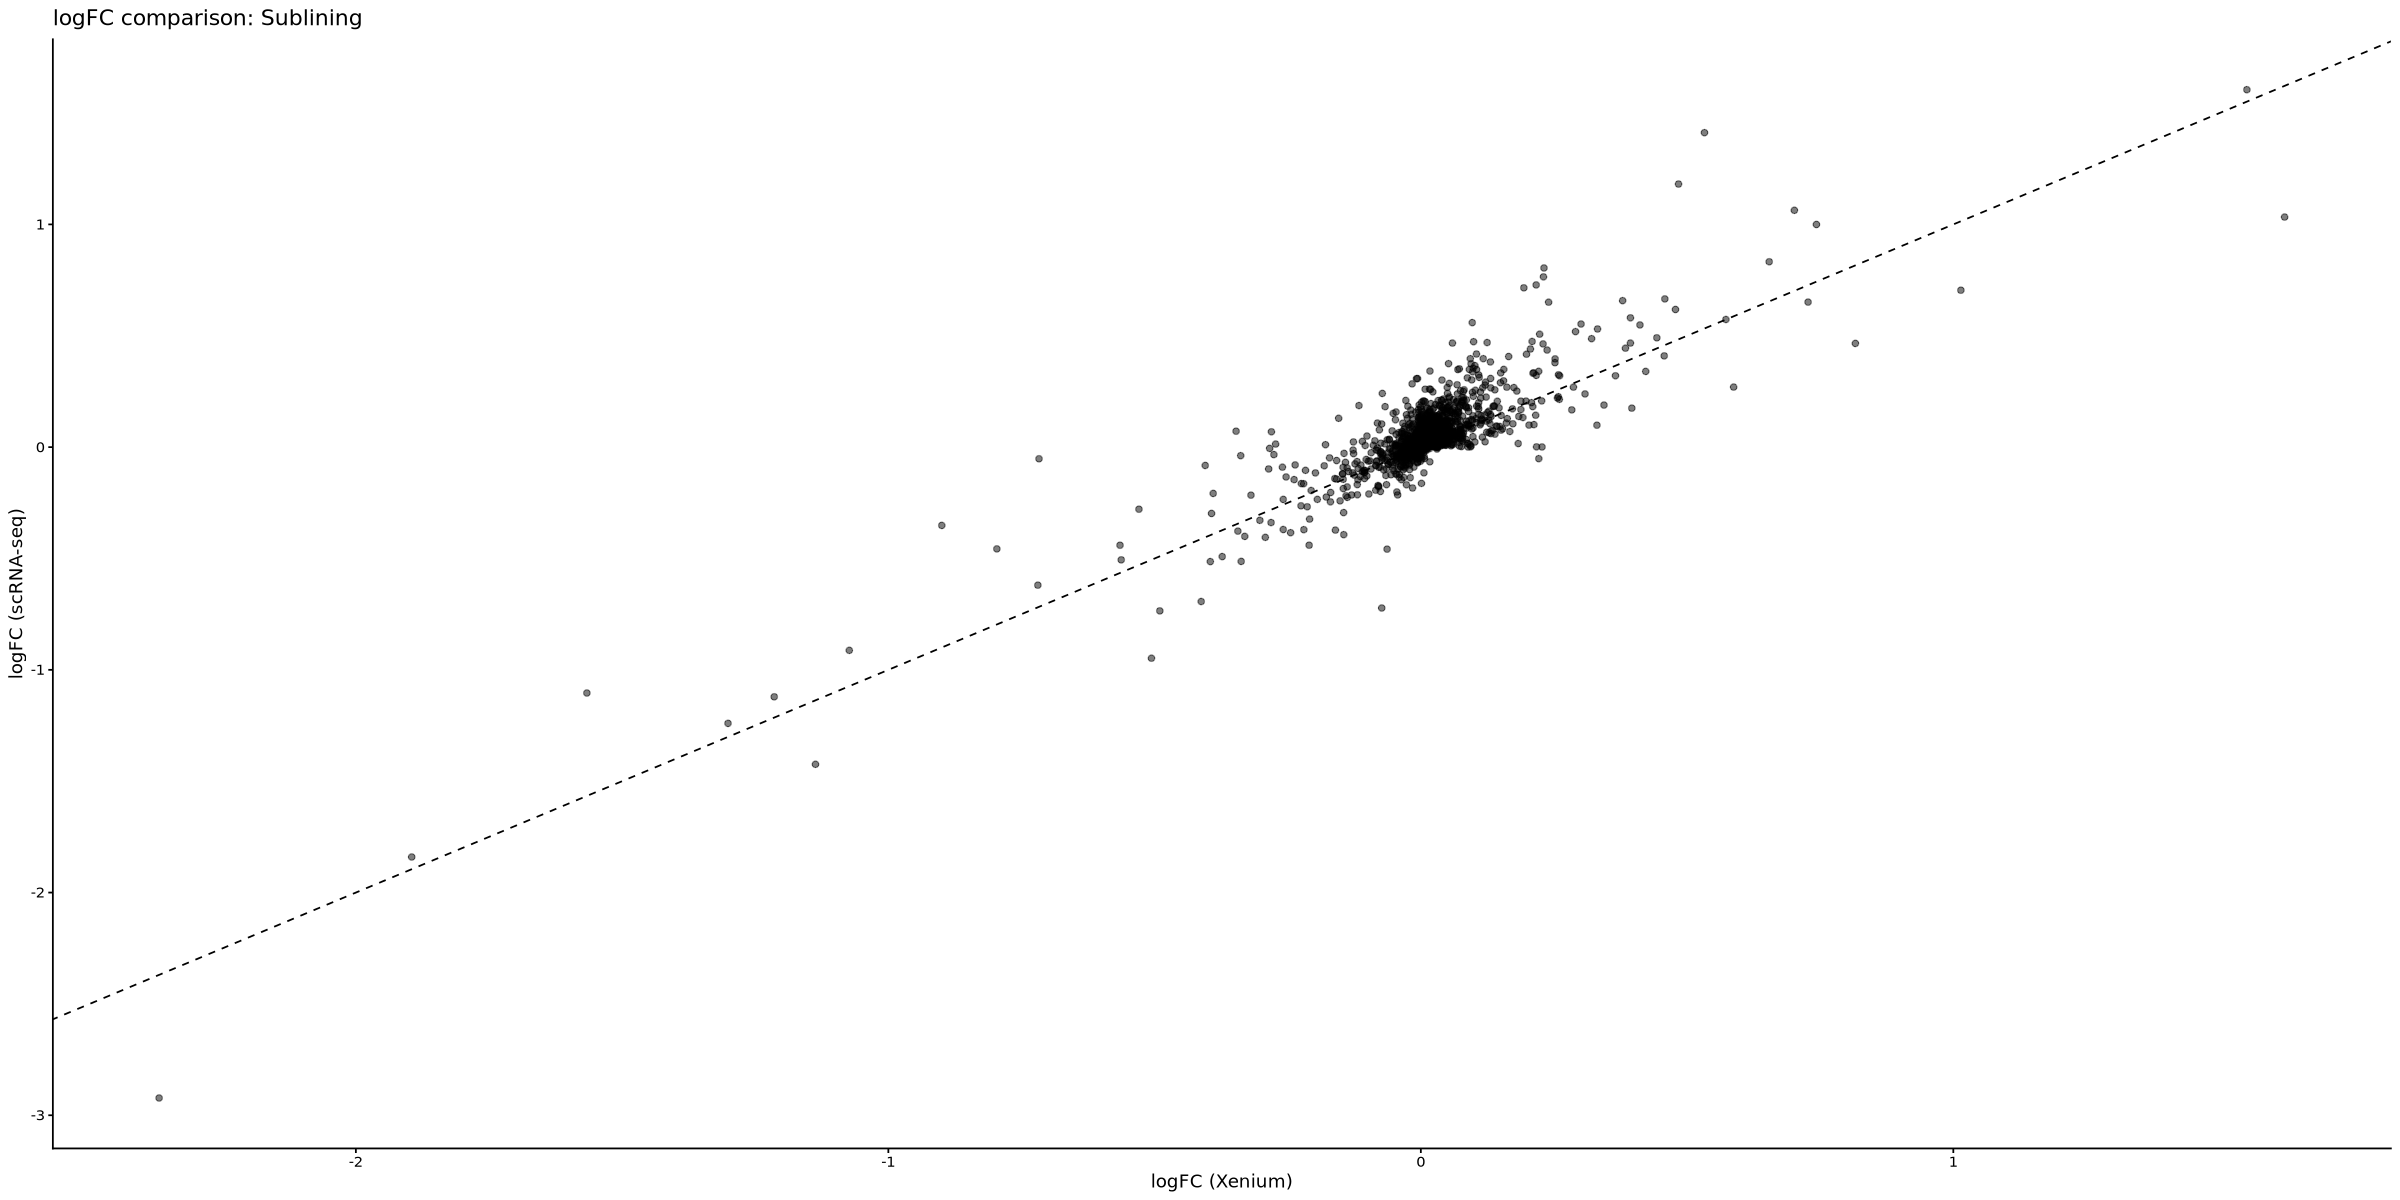

In [12]:
sl_res <- PlotStateLogFCComparison(
  markers_sc = res$markers.sc,
  markers_xen = res$markers.xen,
  cell_state = "Sublining"
)

sl_res$correlation

## Save resulting cell types into original xenium object

In [24]:
xen_sl.meta <- f_merged@meta.data %>%
    filter(cell_type == "Sublining") %>%
    filter(modality == "xen")
rownames(xen_sl.meta) <- sub("^xen_", "", rownames(xen_sl.meta))
xen_sl <- subset(xen, cells = rownames(xen_sl.meta))
xen_sl$celltypes.med <- "Sublining"
dim(xen_sl)
saveRDS(xen_sl, "out_rds/intermediate/_Sublining.rds")

xen_l.meta <- f_merged@meta.data %>%
    filter(cell_type == "Lining") %>%
    filter(modality == "xen")
rownames(xen_l.meta) <- sub("^xen_", "", rownames(xen_l.meta))
xen_l <- subset(xen, cells = rownames(xen_l.meta))
xen_l$celltypes.med <- "Lining"
dim(xen_l)
saveRDS(xen_l, "out_rds/intermediate/_Lining.rds")

[1]   4008 521081

[1]   4008 324120

# Call sublining subtypes

In [ ]:
xen_sl <- readRDS("out_rds/intermediate/_Sublining.rds")

## Get discriminatory genes from sc

In [25]:
# select genes that differentiate sublining types in AMPp2
res <- FindHVGsFromGroups(sc[, sc$cell_type == "Sublining"], group_var = "cluster_name", logFC_thresh = 0.2)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 491 


row,F-1: SFRP1+ sublining,F-2: CD34+ sublining,F-4: POSTN+ sublining,F-5: CD82+ sublining,F-6: Proliferating sublining,F-7: NOTCH3+ sublining,F-8: DKK3+ sublining,M-u1: SERPINF1+ sublining
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CXCL12,MFAP5,ASPN,PRG4,SOCS3,C3,DKK3,ACTA2
2,SFRP1,FBLN2,POSTN,CLU,ATF3,CFH,ASPN,MCAM
3,CP,TNXB,COMP,CRTAC1,KLF4,FBLN2,CRTAC1,TPM1
4,IGF1,ACKR3,AEBP1,VCAM1,CYR61,GAS6,TPPP3,TINAGL1
5,CFH,ASPN,CTHRC1,HTRA1,NR4A1,CXCL12,S100A10,NOTCH3
6,WISP2,CD248,COL5A2,TNC,KLF2,ITM2A,S100A4,RGS5
7,CYP1B1,PRG4,TNC,STEAP4,MCL1,COL4A1,COMP,COL18A1
8,C2orf40,FSTL1,THBS2,MMP3,IRF1,THY1,EMP1,BCAM
9,EPHX1,CD55,CTSK,COLEC12,CXCL12,SOD3,PLP2,MYLK


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 521081 cells 
  Single-cell counts dimensions: 4004 genes x 60803 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 581884 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 2 layers present: counts.xen, counts.sc
  Merged object dimensions: 4004 genes x 581884 cells 
  Cells by modality: 

    sc    xen 
 60803 521081 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 211 
  SC median nCount_RNA: 2073 
  Selected normalization scale factor: 1142 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 491 
  HVGs present in merged object: 491 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  COL5A1, ASPN, SFRP4, COL6A1, ANGPTL2, ADAMTS2, THY1, COL5A2, LOXL2, FMOD 
	   NBL1, COMP, THBS2, MFAP5, ADAM12, POSTN, AEBP1, S100A10, DKK3, EMP1 
	   CTSK, SPON2, GJA1, LOXL1, MMP14, FAP, FSTL1, CTHRC1, TPPP3, LRRC15 
Negative:  CXCL12, CLU, CP, AHR, RSPO3, VCAM1, C2orf40, SLC5A3, PTGER4, STEAP4 
	   HLA-DRB1, FGF10, TFPI, TIMP3, FMO2, ANGPT1, PDE4B, EPHX1, ADAMTS1, SEMA3E 
	   FOXC1, IGFBP2, EEF1B2, DLX4, H3F3B, SYNPO2, EBF1, IL6ST, RASD1, CFH 
PC_ 2 
Positive:  PRG4, TIMP3, TNXB, CLU, CRTAC1, S100A4, S100A10, SDC2, ANXA2, FSTL1 
	   ACKR3, SEMA3C, TGFBR3, LRP1, CD55, CTGF, VCAM1, ERRFI1, CREB5, PLTP 
	   CD248, NTN4, ANPEP, TPPP3, CADM3, PROCR, CD44, COLEC12, SEMA3E, LDHA 
Negative:  POSTN, TPM1, ADAM12, AEBP1, CTHRC1, SPON2, COMP, NOTCH3, GAS6, ACTN1 
	   EPAS1, COL5A1, THY1, MYLK, COL5A2, CDH11, ACTA2, GXYLT2, SFRP4, CACNA1C 
	   CTSK, MYO1D, COL11A1, THBS2, LRRC15, HES4, MMP14, TMEM119, P4HA3, NES 
PC_ 3 
Positive:  S100A4, S100A10, MFAP5, TPPP3, FABP3, DKK3, CD

  Printing PCA diagnostic plots... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



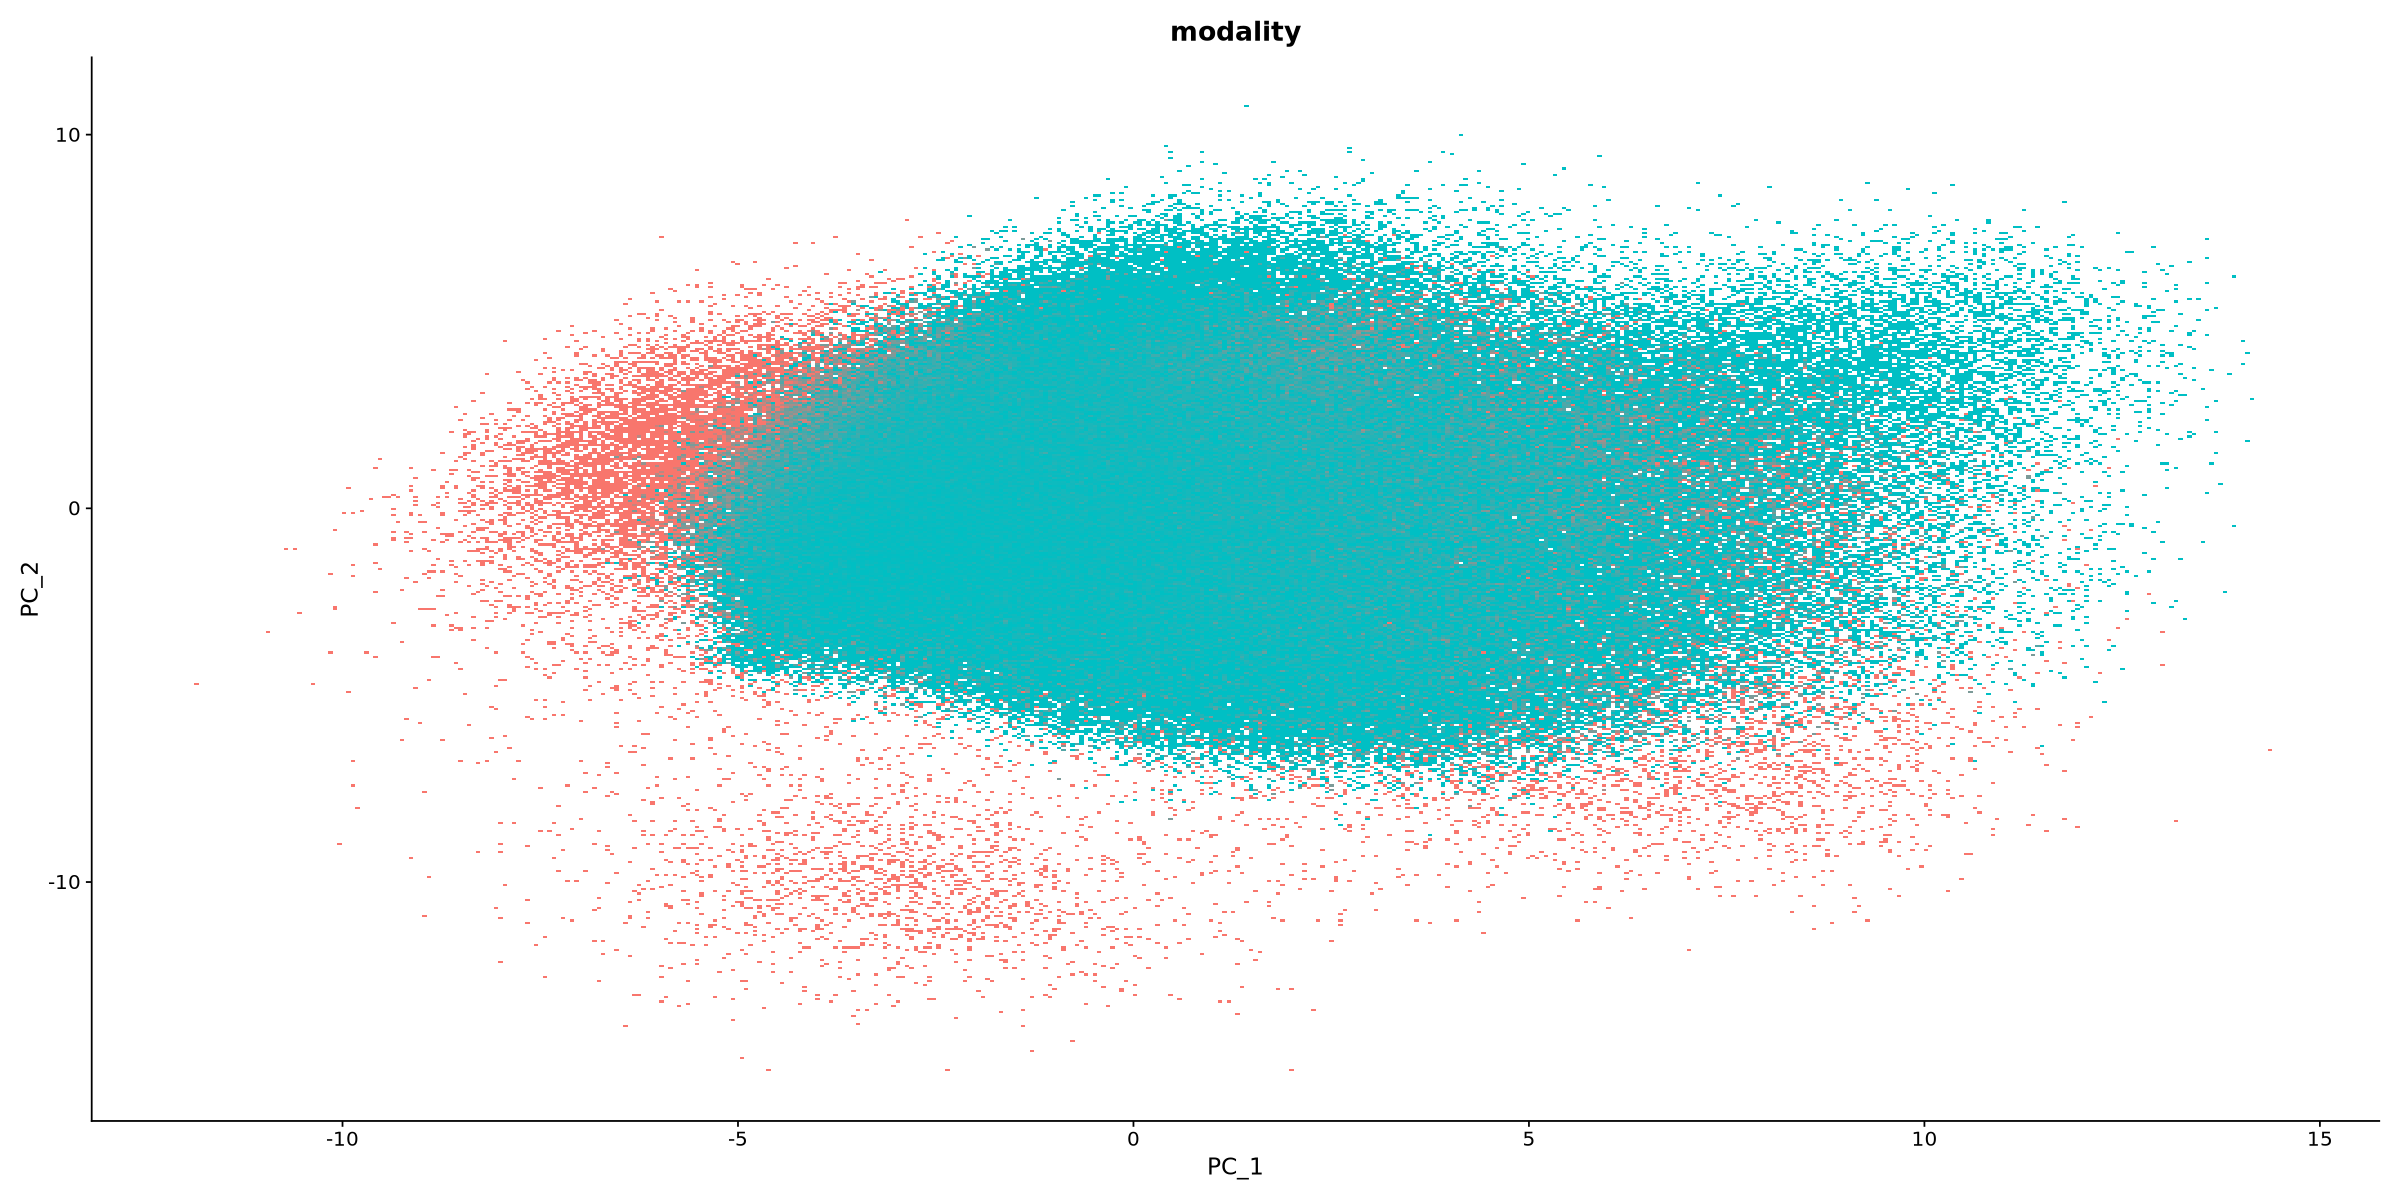

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[6/7] Running Harmony... 


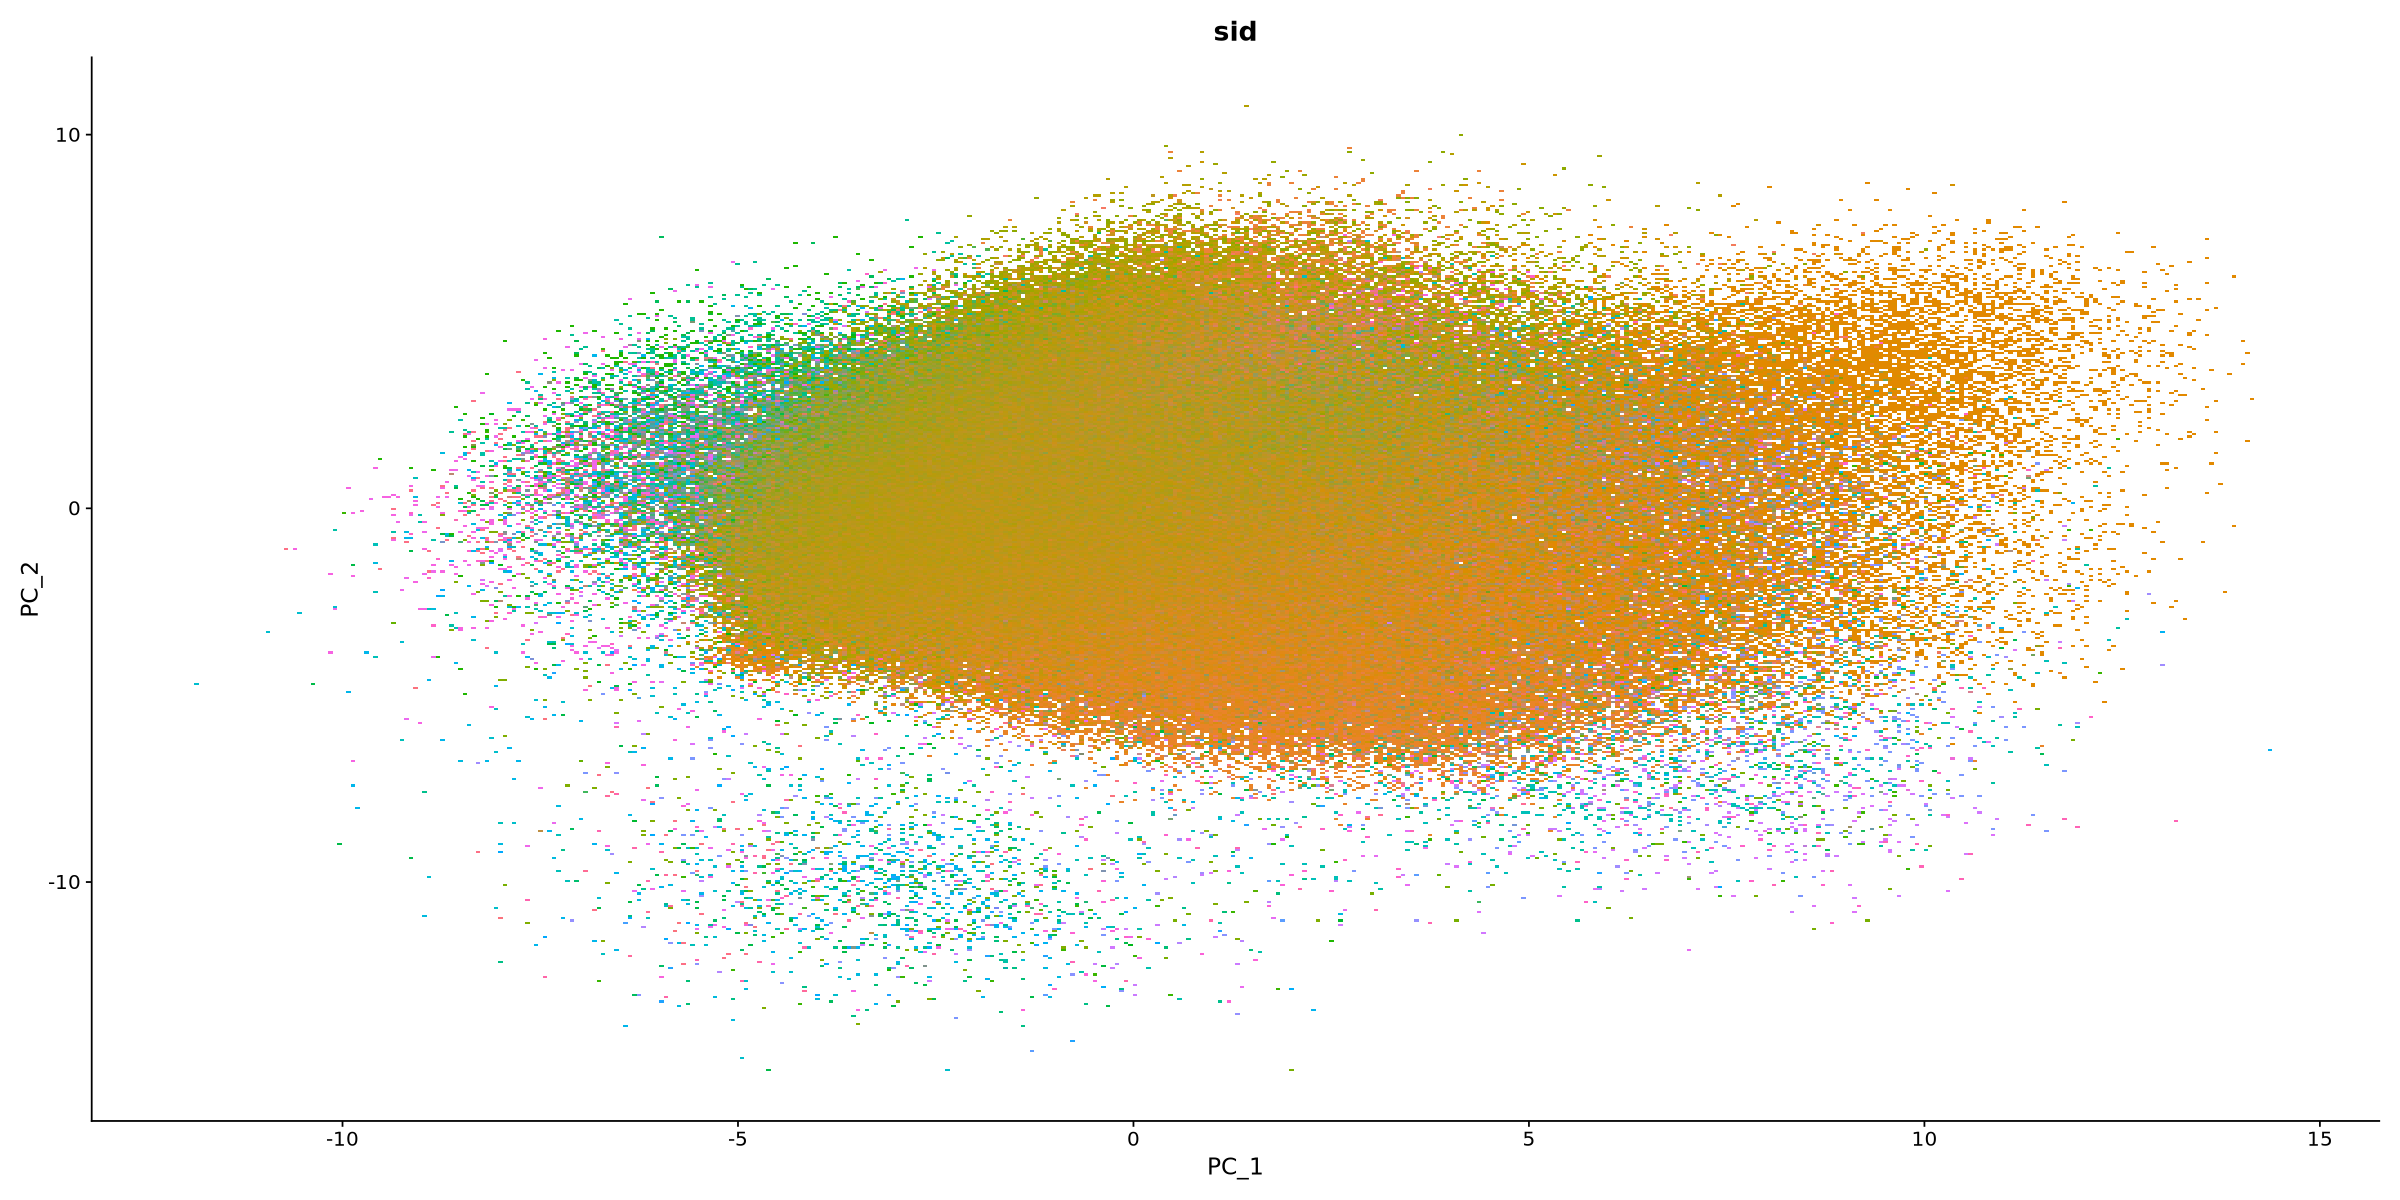

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 29094200)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


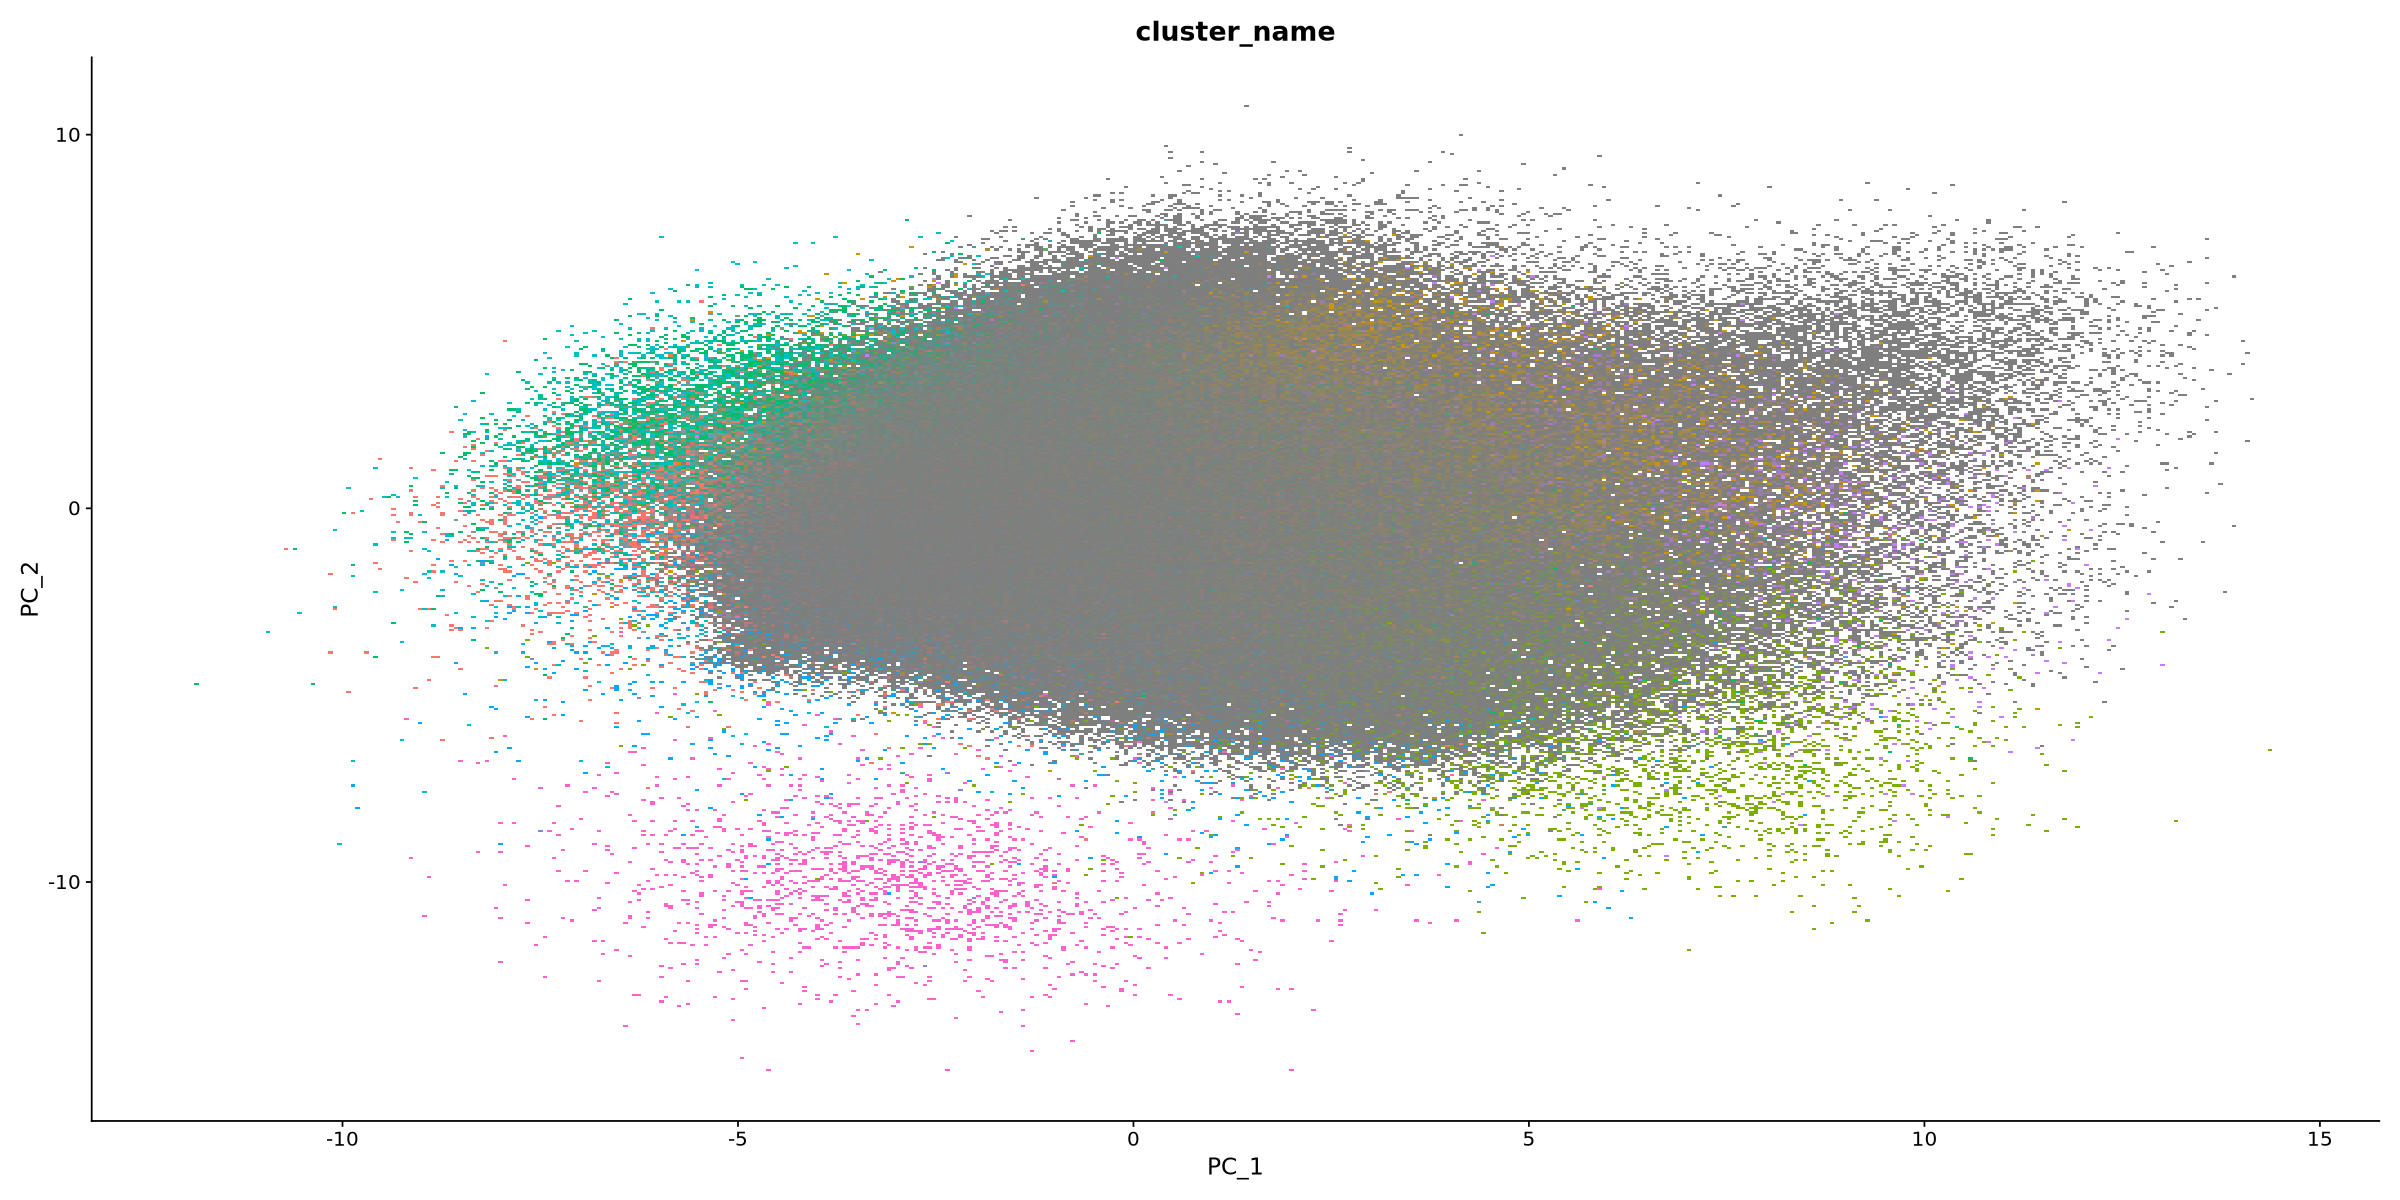

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



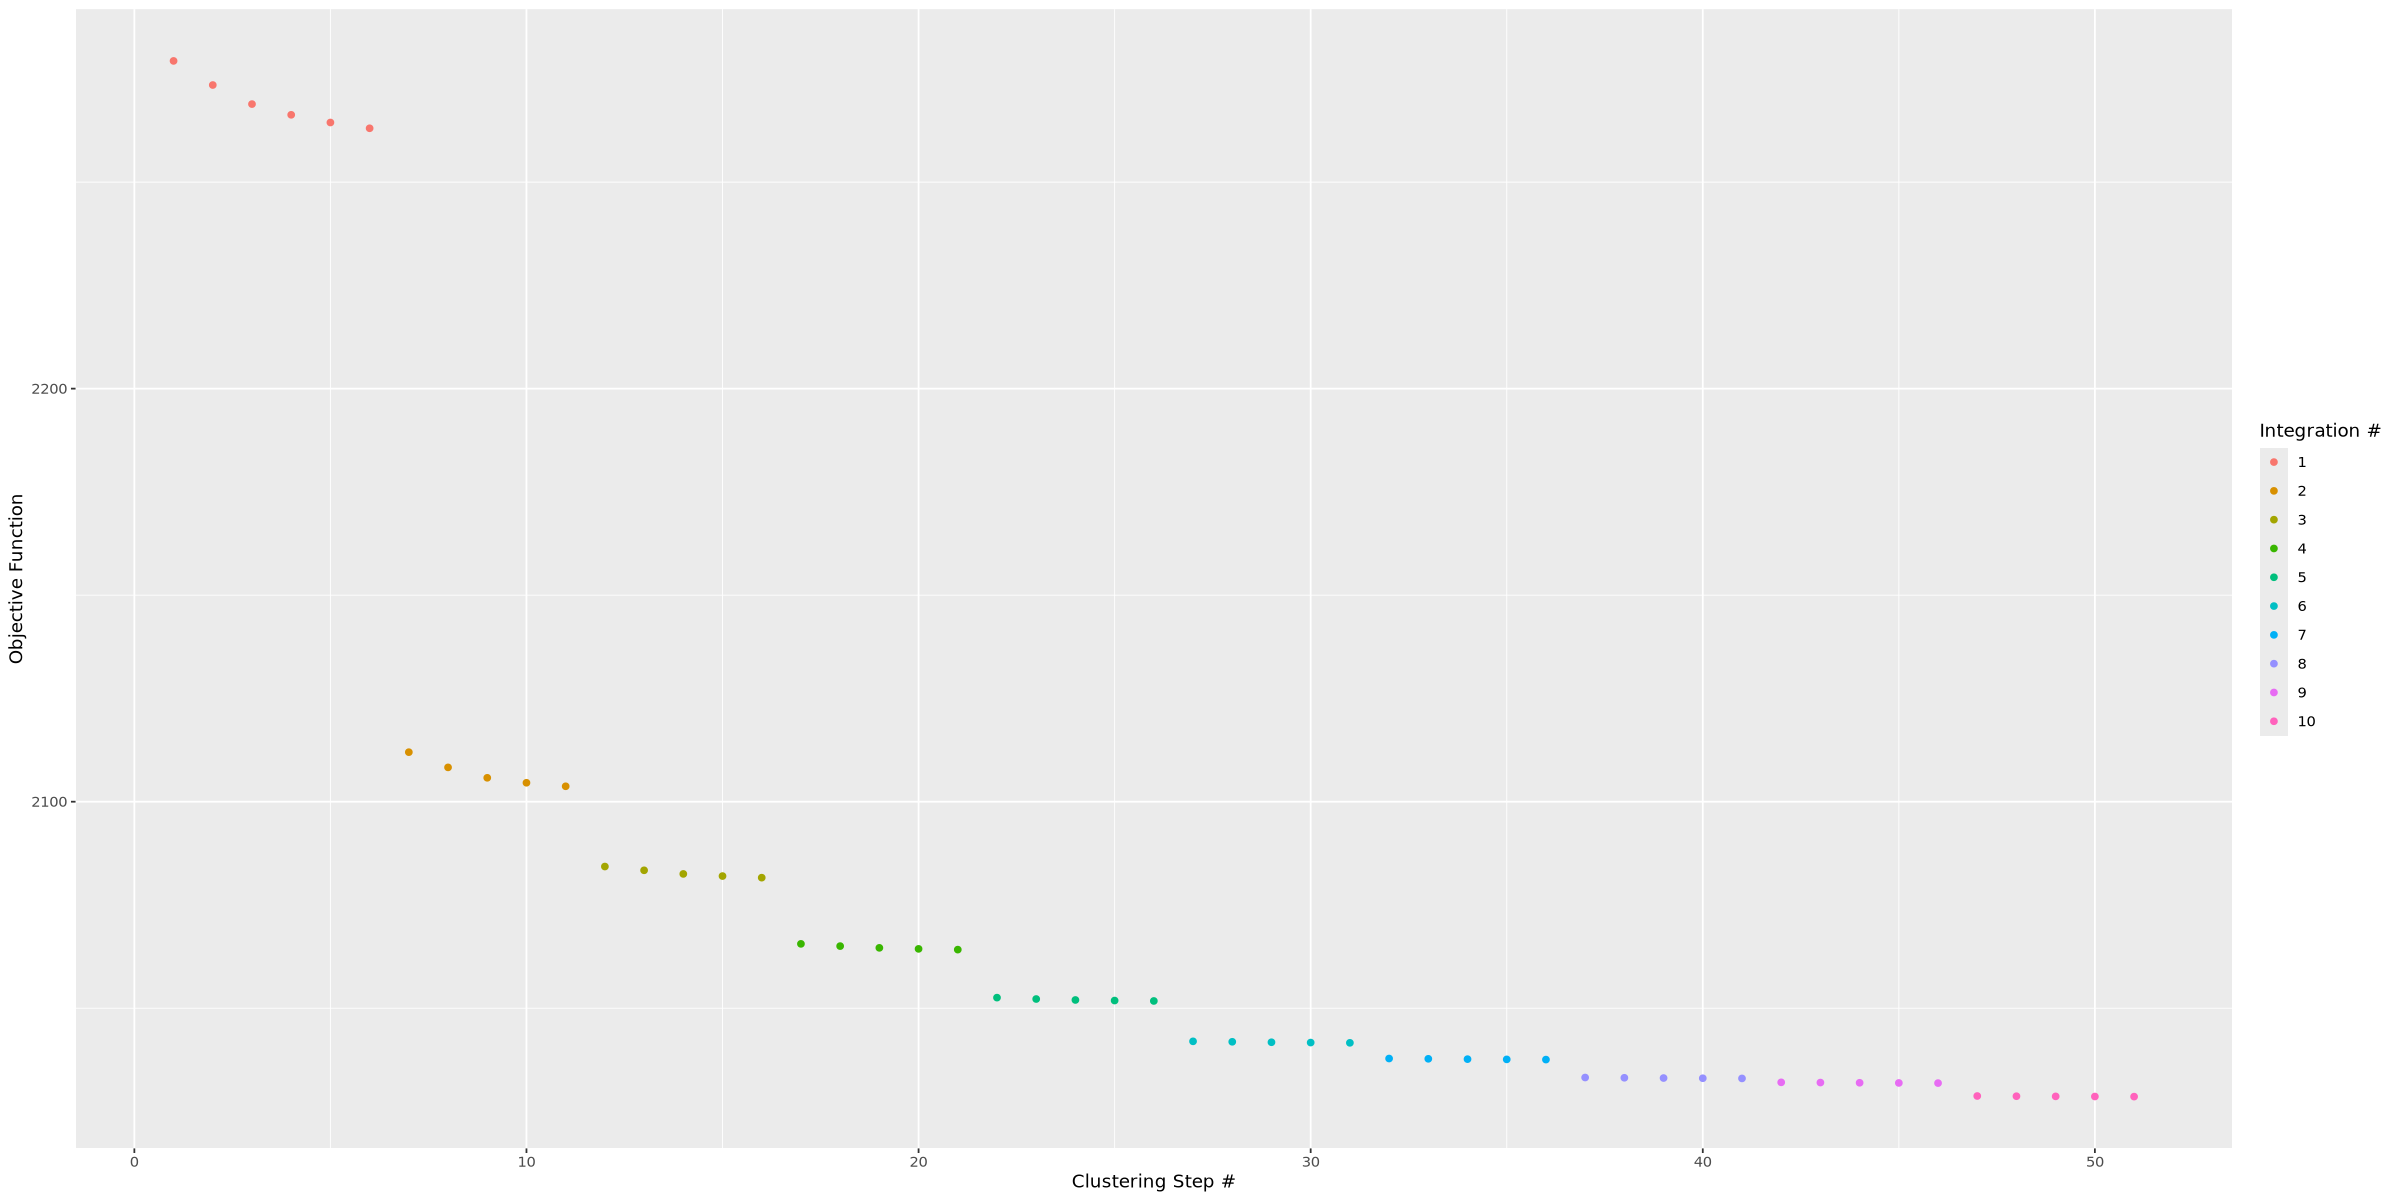

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



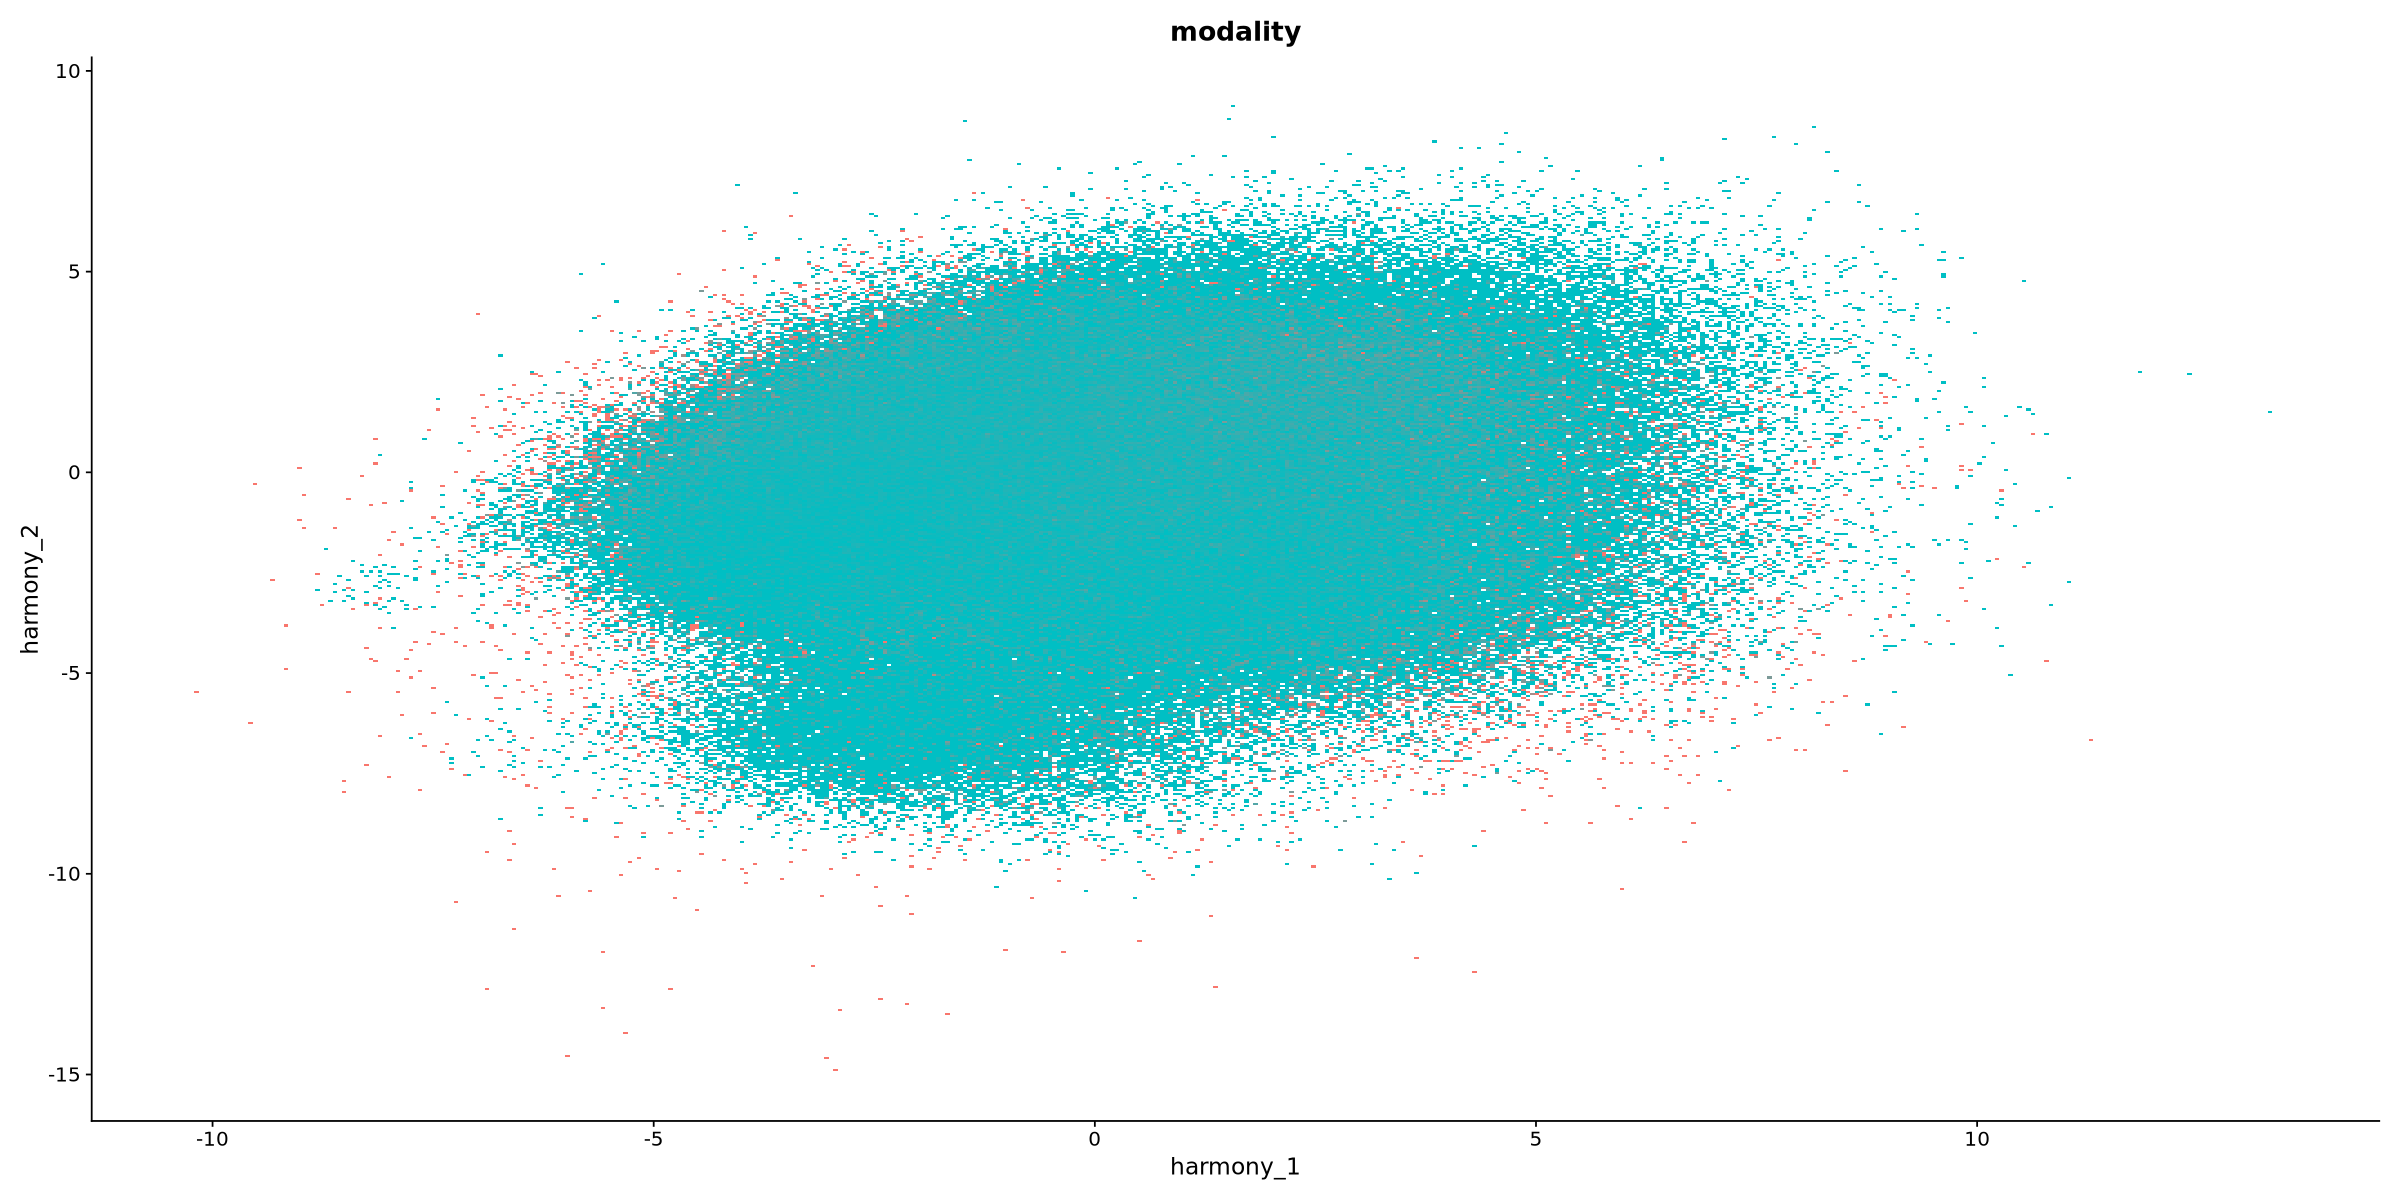

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[7/7] Running UMAP on the Harmony reduction... 


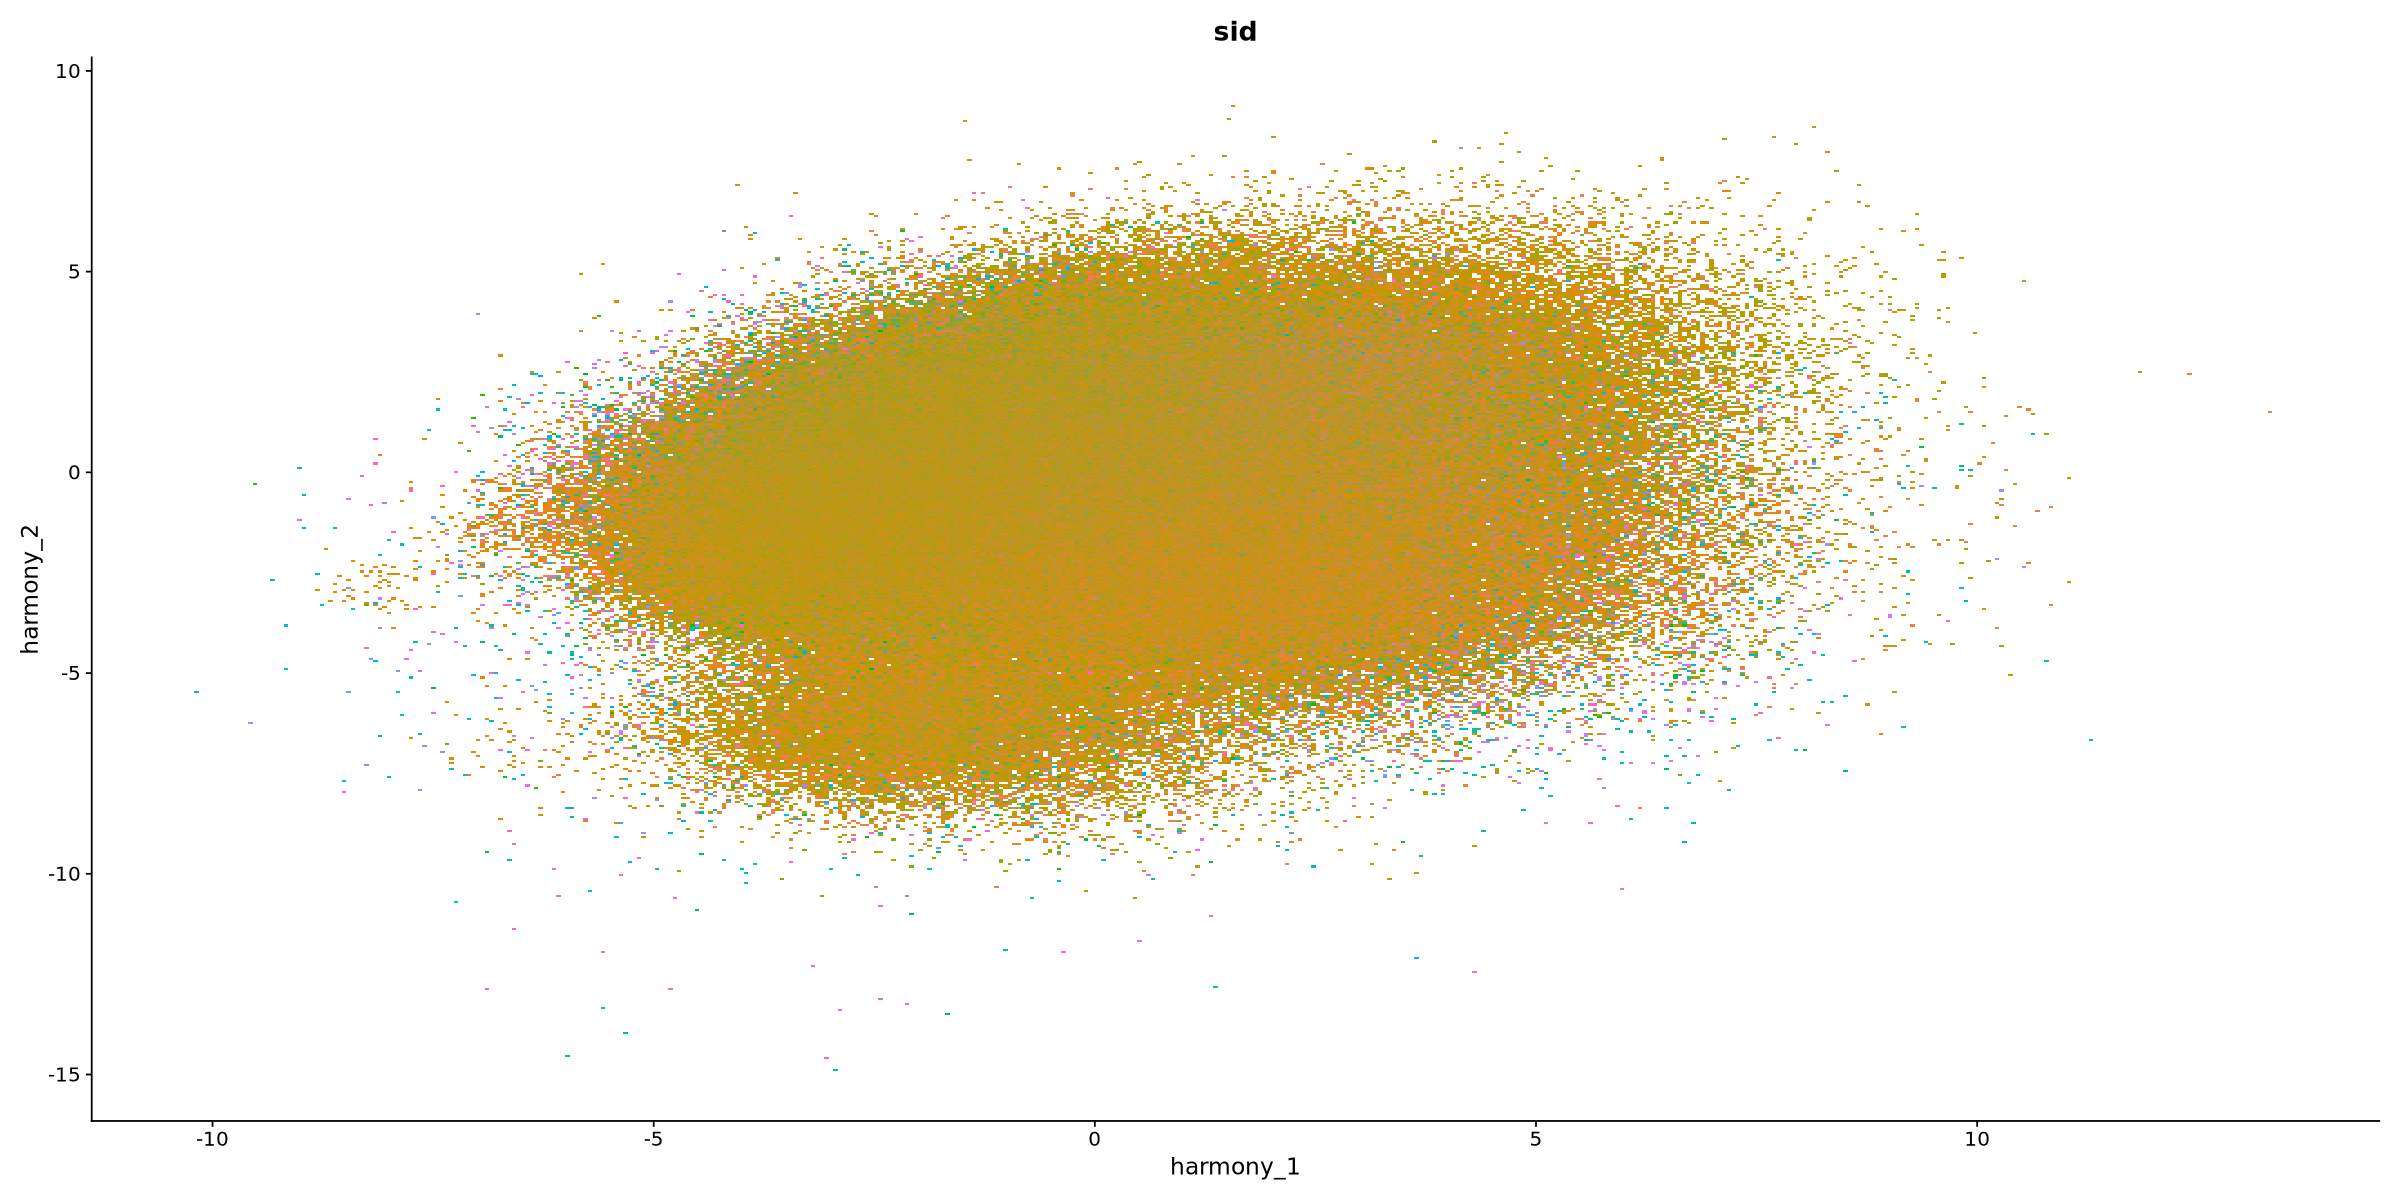

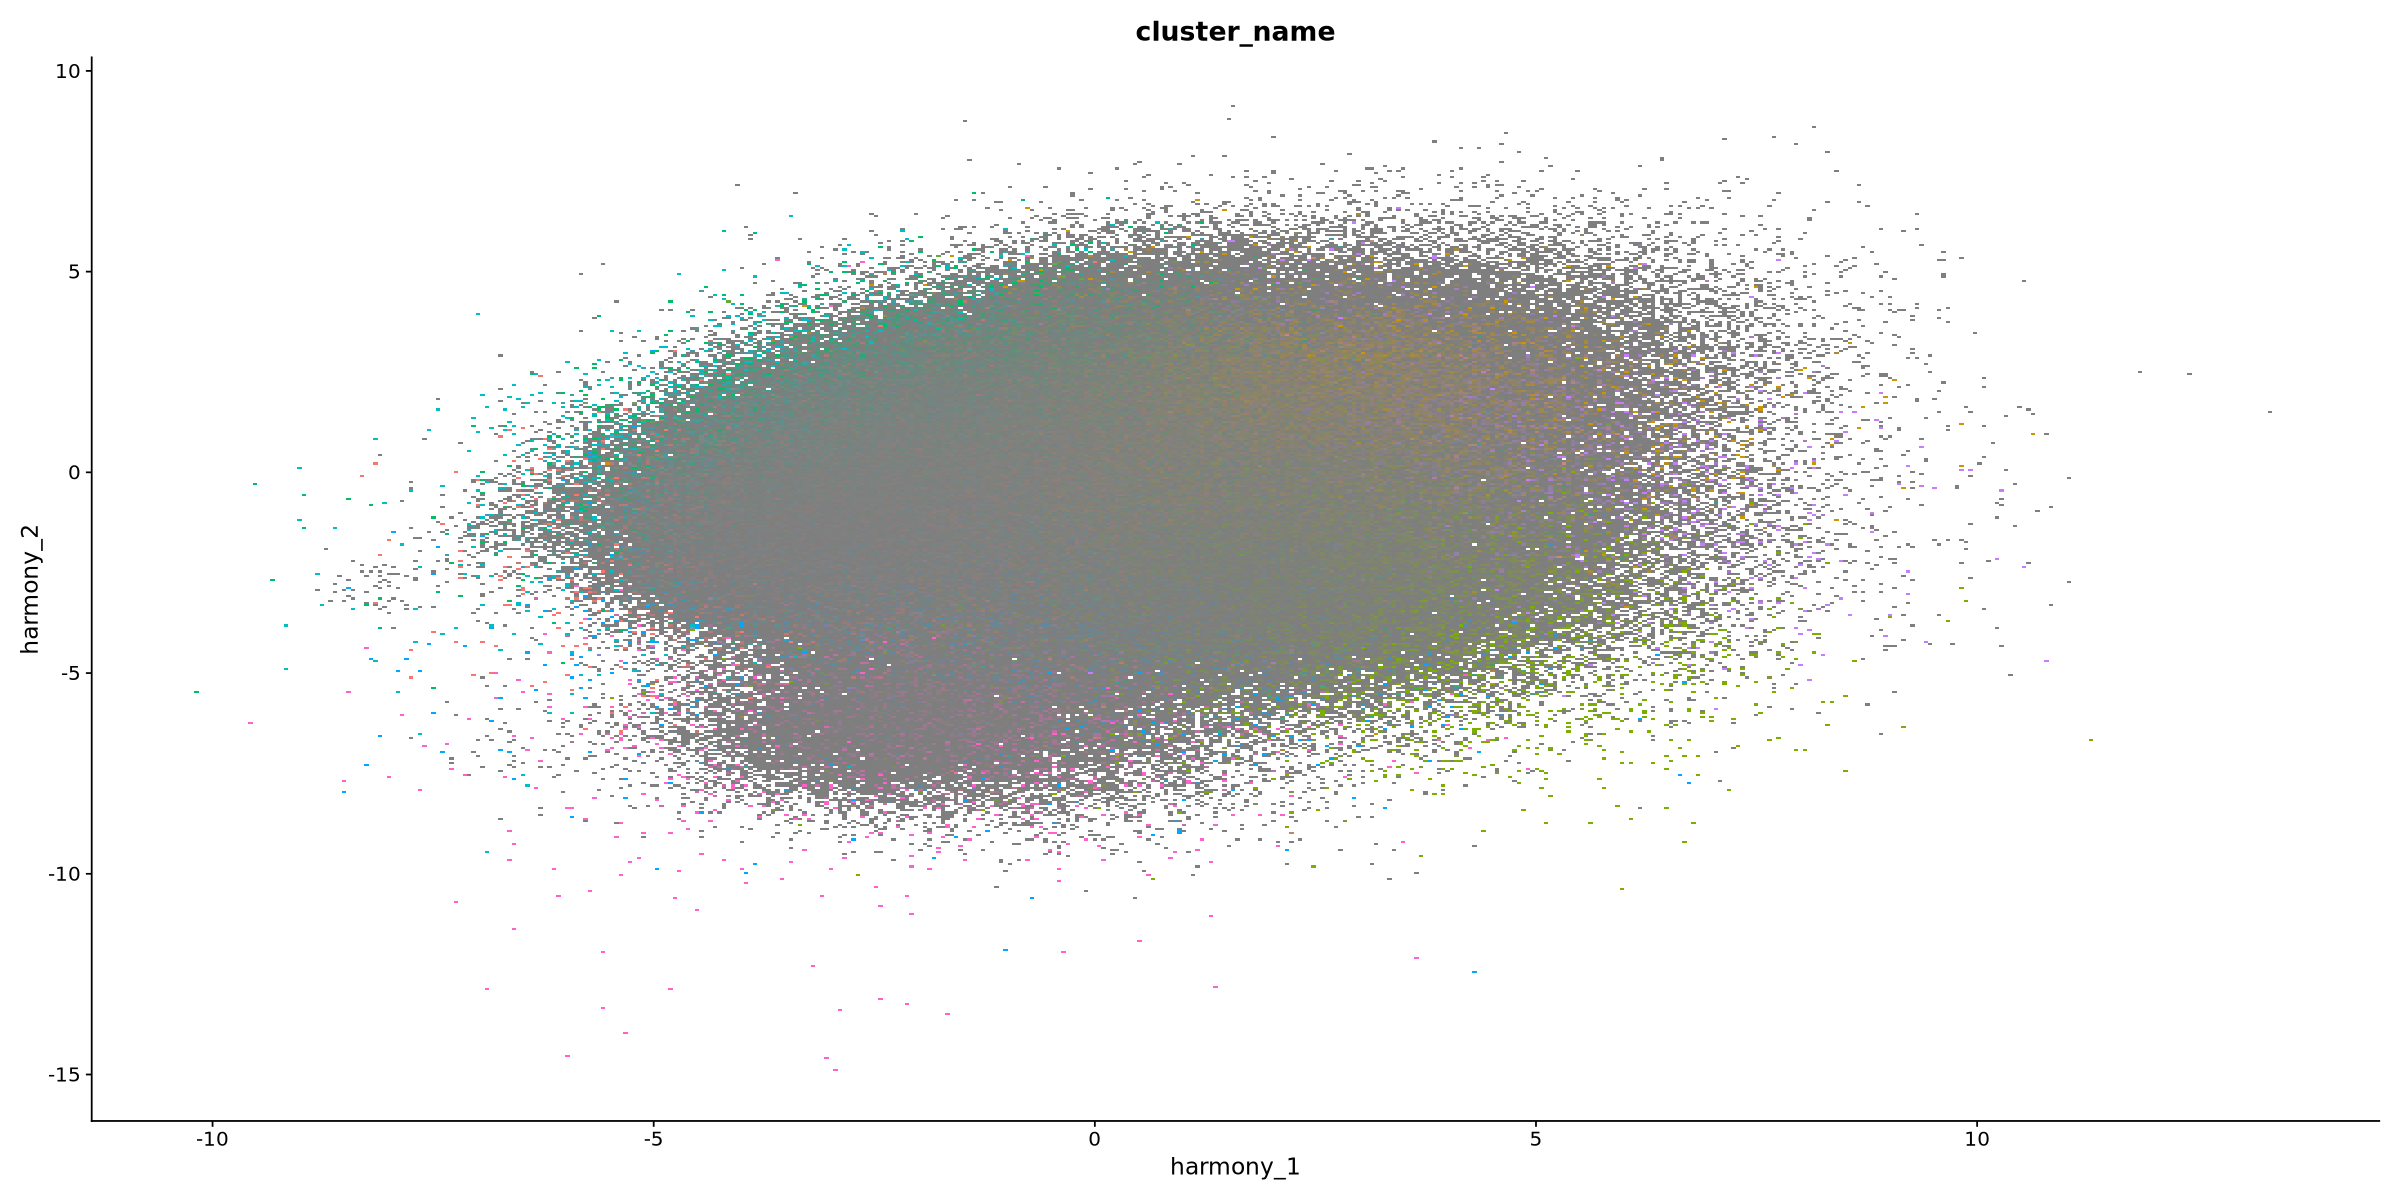

In [26]:
sl_merged <- BuildIntegratedReference(
    xen = xen_sl,
    sc = sc[, sc$cell_type == "Sublining"],
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cluster_name"
)

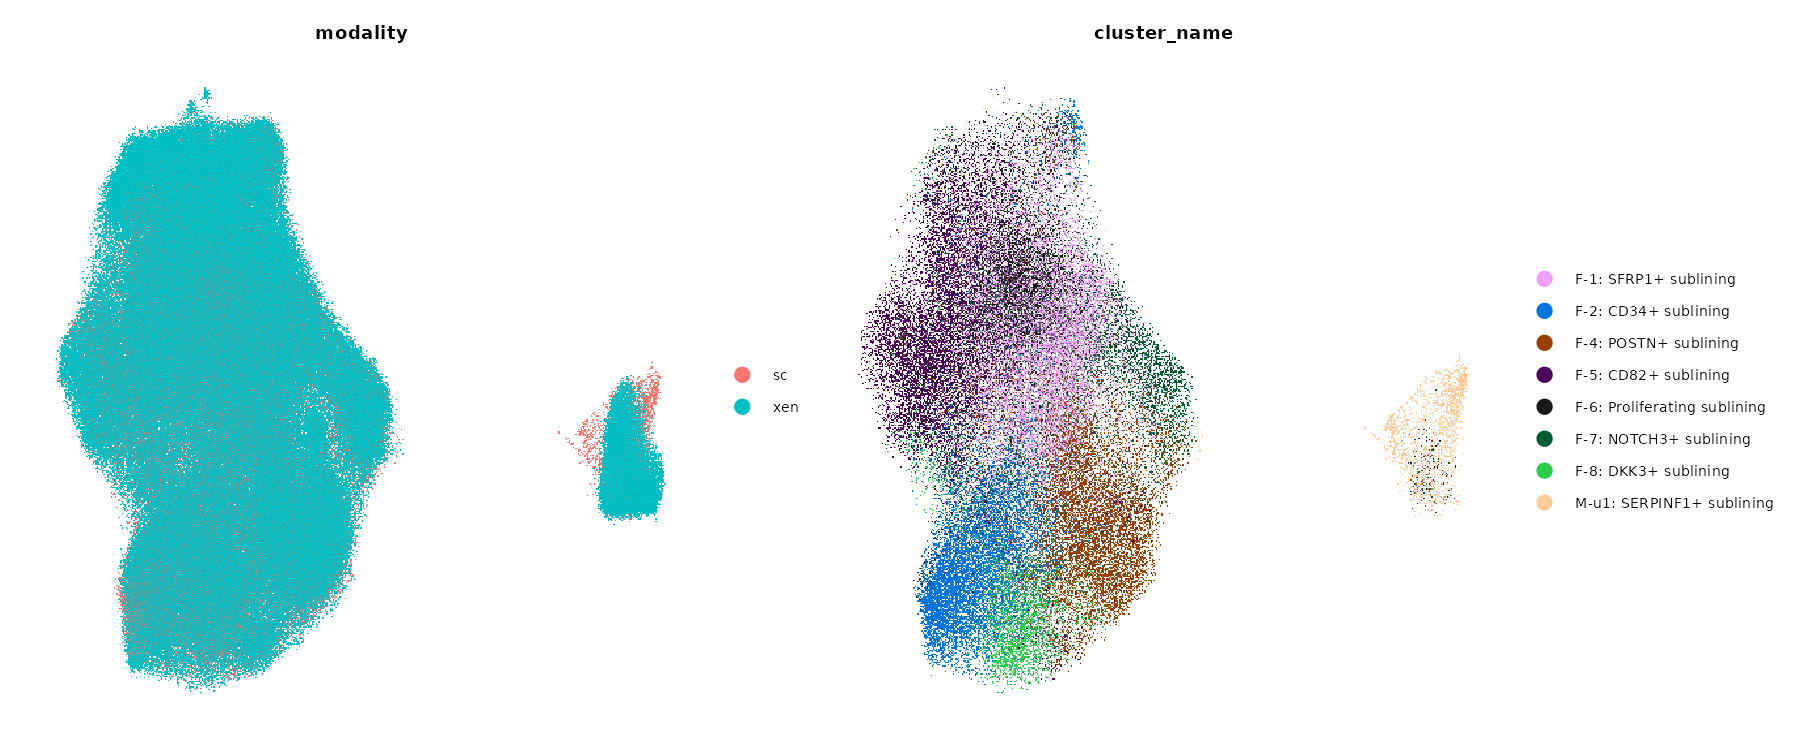

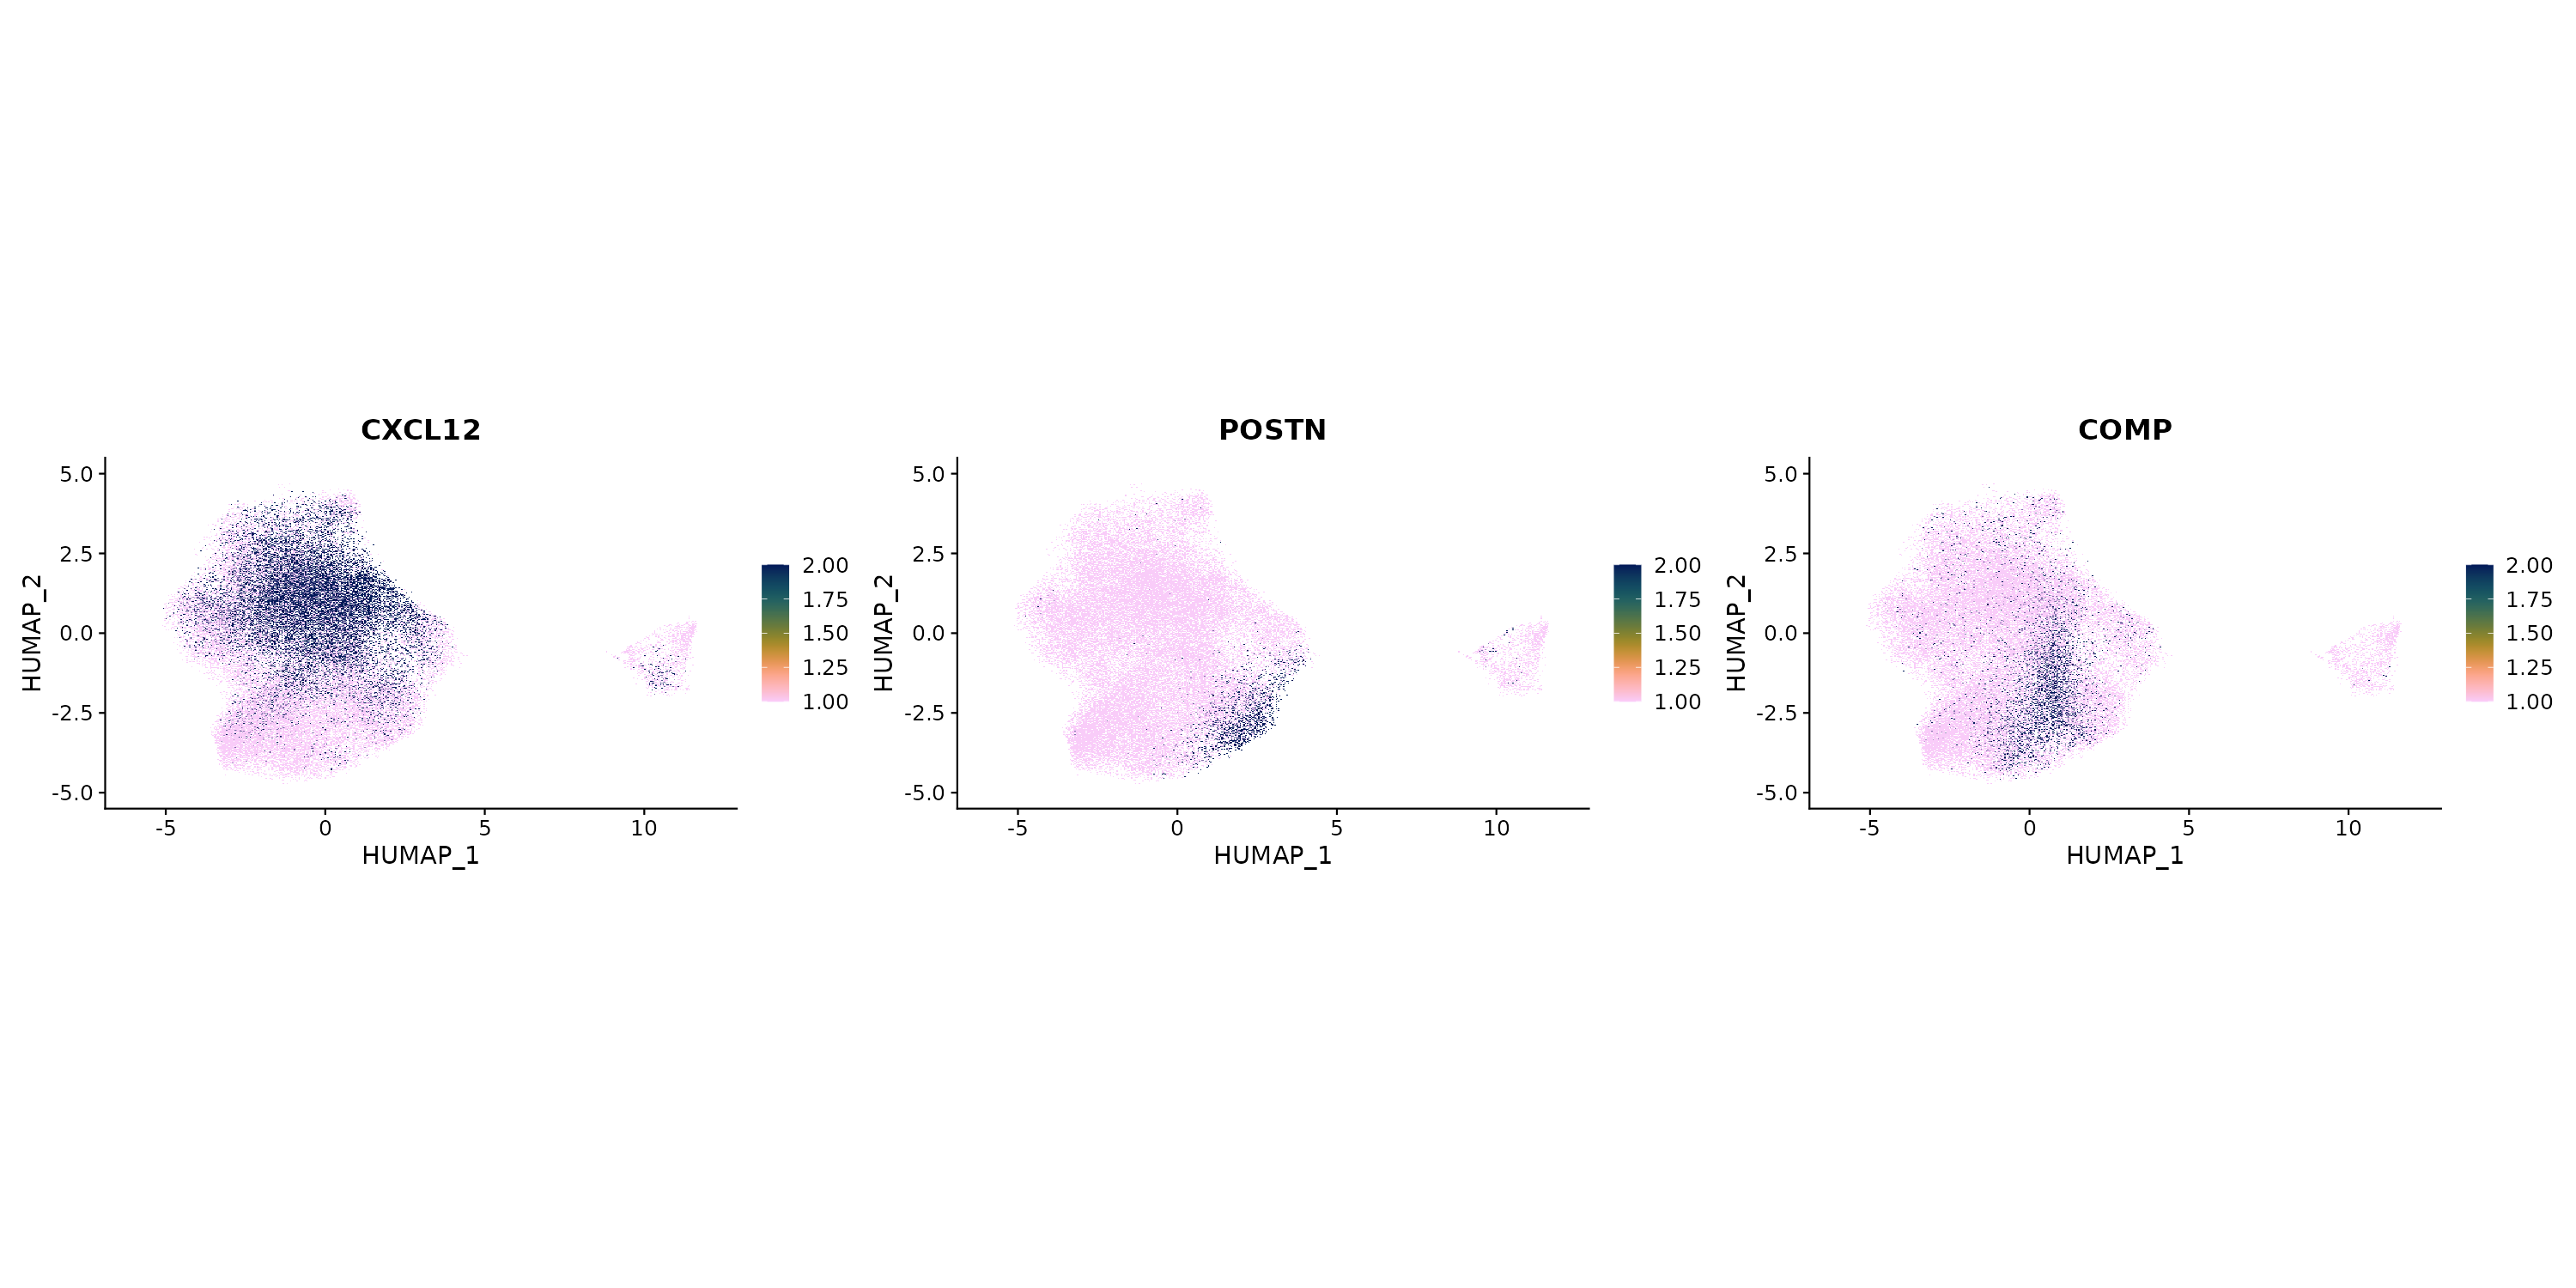

In [27]:
ShowTransferDiagnostics(
    merged = sl_merged,
    annotation_var = "cluster_name",
    genes_to_visualize = c("CXCL12", "POSTN", "COMP")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cluster_name 
  Using n_neighbors = 50 and min_ratio = 1.1 

[2/4] Computing nearest-neighbor graph from Harmony embedding... 
  Graph computation complete. 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cluster_name 
  Xen cells without transferred labels: 55174 

[4/4] Plotting unlabeled cells and final xen label map... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



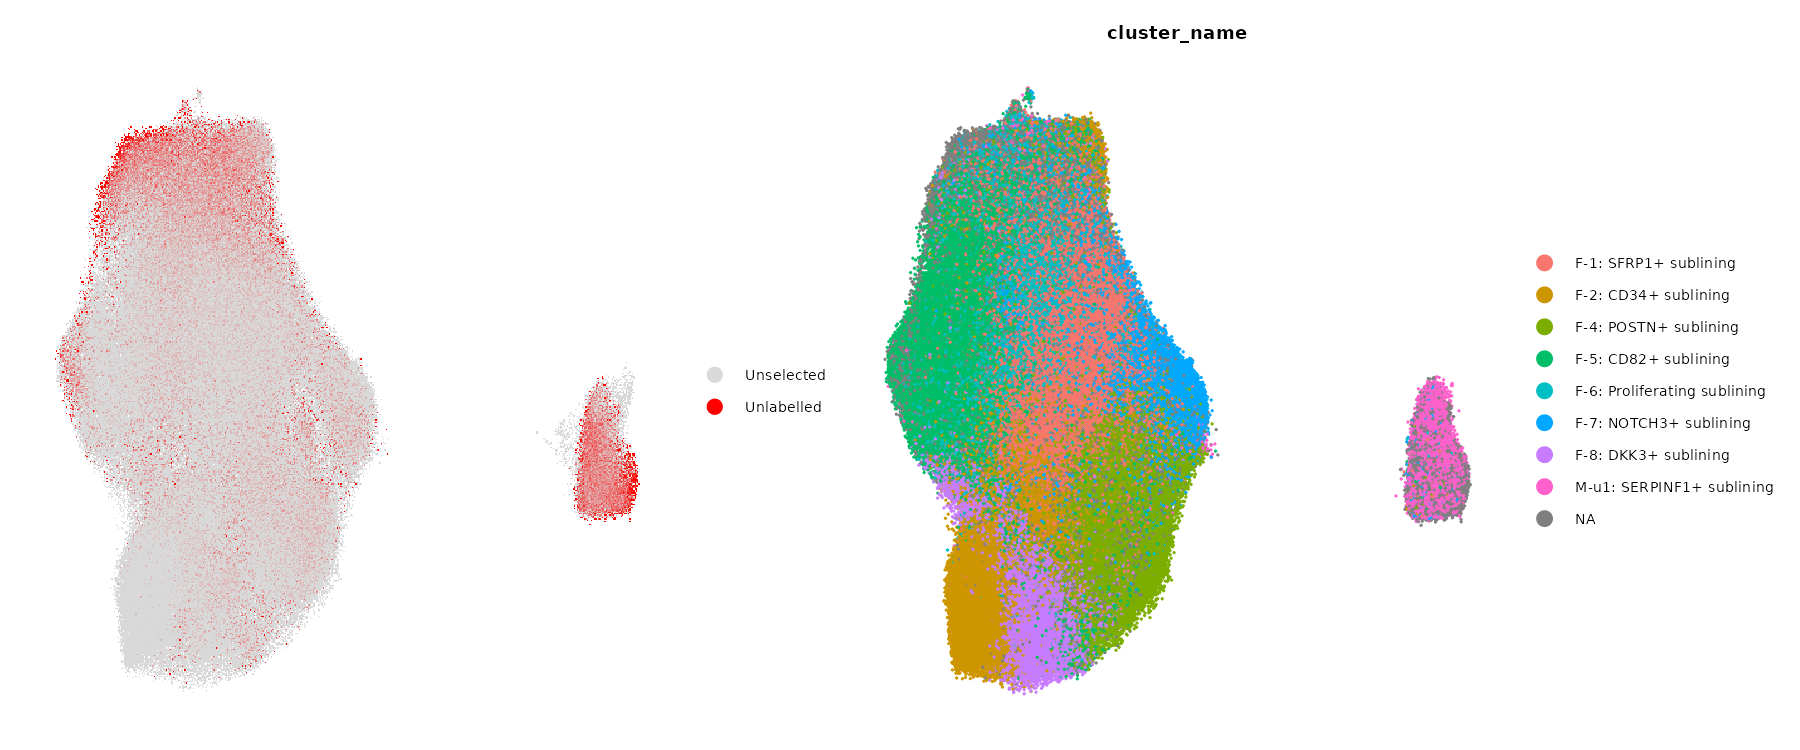

In [28]:
sl_merged <- TransferLabelsGraph(
    merged = sl_merged,
    annotation_var = "cluster_name",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [29]:
ShowClusterMarkers(sl_merged[, sl_merged$modality == "xen"], "cluster_name", n_show = 5)

Removing NA values from labels



row,F-1: SFRP1+ sublining,F-2: CD34+ sublining,F-4: POSTN+ sublining,F-5: CD82+ sublining,F-6: Proliferating sublining,F-7: NOTCH3+ sublining,F-8: DKK3+ sublining,M-u1: SERPINF1+ sublining
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CXCL12,TNXB,COMP,PRG4,CCL5,COL4A1,S100A10,COL4A1
2,C3,MFAP5,POSTN,CLU,MCL1,NID1,CRTAC1,TPM1
3,SFRP1,ACKR3,AEBP1,CRTAC1,CXCL12,C3,S100A4,MYH9
4,CLU,PRG4,COL5A1,MMP3,NR4A1,THY1,NBL1,ACTA2
5,WISP2,FSTL1,COL5A2,HTRA1,SOCS3,CFH,FMOD,CCL5


Removing NA values from labels



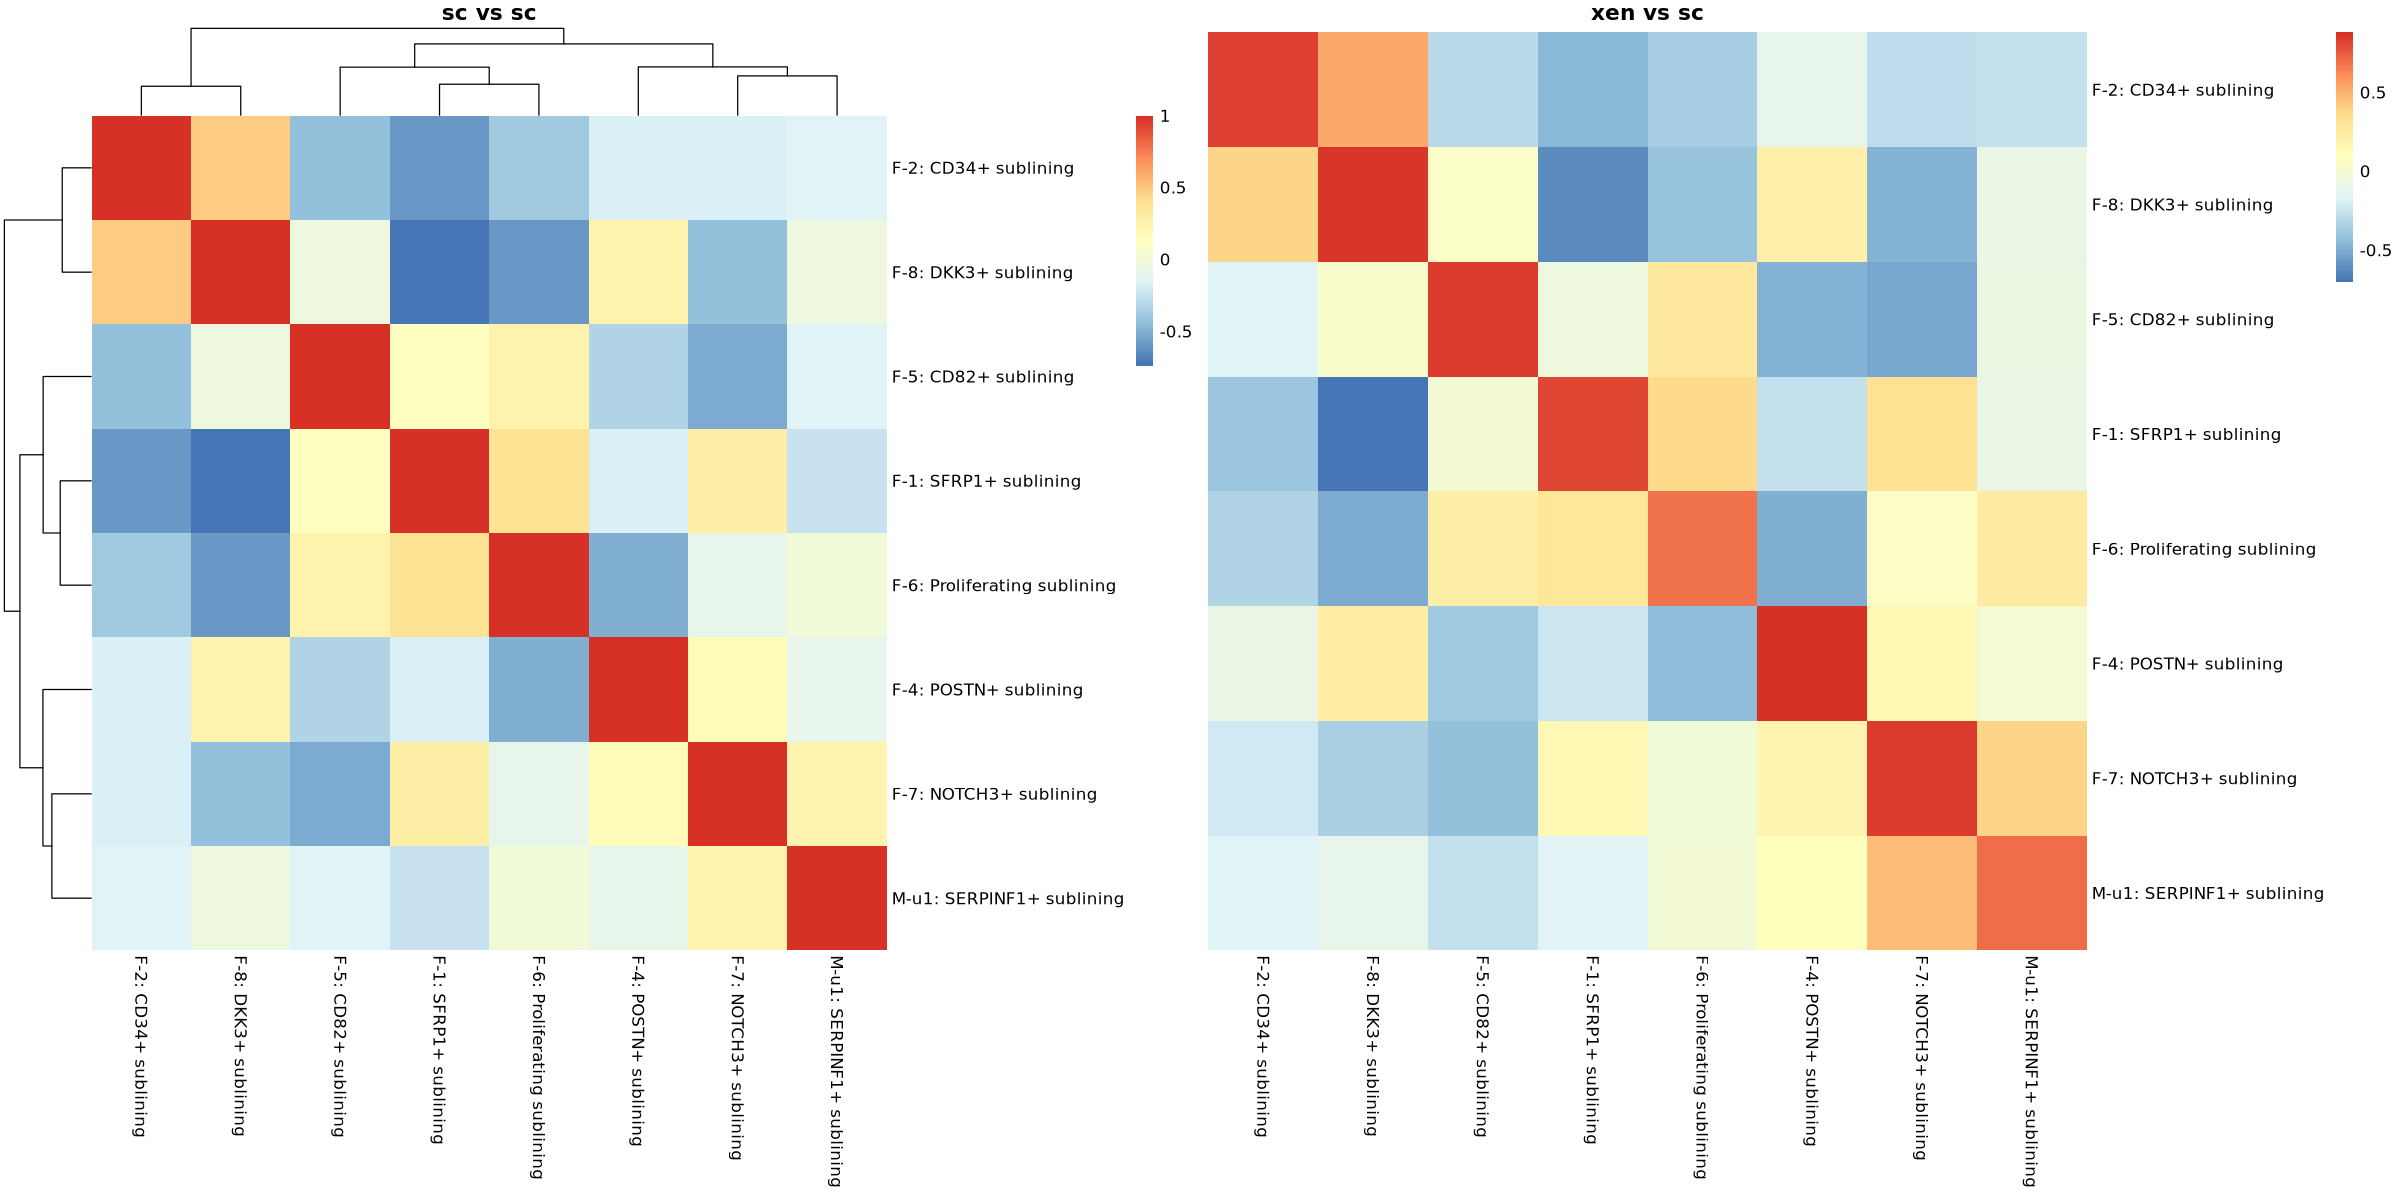

In [30]:
res <- CompareMarkerCorrelations(sl_merged[,sl_merged$modality == "xen"],
                                 sl_merged[,sl_merged$modality == "sc"], "cluster_name", bicluster = T)

## Save

In [31]:
xen_sl@meta.data <- subset(
  xen_sl@meta.data,
  select = -c(humap_fgraph_res.0.8, seurat_clusters)
)

colnames(sl_merged) <- sub("^xen_", "", colnames(sl_merged))

xen_sl$celltype.fine <- sl_merged$cluster_name[
  match(colnames(xen_sl), colnames(sl_merged))
]
xen_sl[[]]$celltype.fine[is.na(xen_sl[[]]$celltype.fine)] <- "F-9: Untyped"

In [32]:
saveRDS(xen_sl, file = "out_rds/intermediate/_Sublining_finetyped.rds")

# Call lining subtypes

In [ ]:
xen_l <- readRDS("out_rds/intermediate/_Lining.rds")

## Get discriminatory genes from sc

In [33]:
# select genes that differentiate sublining types in AMPp2
res <- FindHVGsFromGroups(sc[, sc$cell_type == "Lining"], group_var = "cluster_name", logFC_thresh = 0.1)
hvgs <- res$hvgs
info <- res$info

info %>%
    dplyr::select(feature, group) %>%
    dplyr::mutate(row = dplyr::row_number()) %>%
    tidyr::pivot_wider(names_from = group, values_from = feature) %>%
    head(n = 10)

Number of HVGs found: 257 


row,F-0: VCAM1+ lining,F-3: CLIC5+ lining,F-9: DKK3+ lining
<int>,<chr>,<chr>,<chr>
1,WISP2,HBEGF,ASPN
2,CXCL12,GPR1,SOD3
3,PLTP,PRG4,FMOD
4,RSPO3,DEFB1,DPT
5,STEAP4,TIMP3,COMP
6,CYP1B1,ERRFI1,DKK3
7,SOD2,CD55,COL6A1
8,DPT,C2orf40,TNC
9,COL6A1,NTN4,AEBP1


## filter xenium + sc to these genes and merge


[1/7] Retrieving count matrices and checking gene overlap... 
  Xenium counts dimensions: 4008 genes x 324120 cells 
  Single-cell counts dimensions: 4004 genes x 27123 cells 
  Number of genes shared between objects: 4004 

[2/7] Preparing Seurat objects for merging... 
  Merged object created. 
  Merged object summary: 
An object of class Seurat 
4004 features across 351243 samples within 1 assay 
Active assay: RNA (4004 features, 0 variable features)
 2 layers present: counts.xen, counts.sc
  Merged object dimensions: 4004 genes x 351243 cells 
  Cells by modality: 

    sc    xen 
 27123 324120 

[3/7] Choosing normalization scale factor... 
  Using mean of modality-specific medians. 
  Xen median nCount_RNA: 243 
  SC median nCount_RNA: 3196 
  Selected normalization scale factor: 1719.5 

[4/7] Normalizing data, setting variable features, and scaling... 
  HVGs supplied: 257 
  HVGs present in merged object: 257 


Centering and scaling data matrix

Centering and scaling data from split sc

Centering and scaling data from split xen




[5/7] Running dimensional reduction... 
  cca_weights is NULL/NA; running PCA. 


PC_ 1 
Positive:  TIMP3, CRTAC1, PRG4, ERRFI1, SEMA3C, ANGPTL2, ACKR3, TNC, HTRA1, LRP1 
	   HBEGF, APP, CLU, CTGF, CD55, COL4A1, ENPP1, COL6A1, AXL, SEMA3A 
	   COL5A2, GPR1, COLEC12, HSPG2, PFKP, RETREG1, PLEKHA1, SGK1, SOX5, LDHA 
Negative:  CXCL12, DPT, PALLD, GAS6, CTNNB1, CCND1, SOD2, SFRP4, IGF1, CYP1B1 
	   OLFML3, SLC40A1, NFATC2, DIO2, SLC9A3R2, PDLIM2, FHL2, CDKN1C, COMP, EEF1B2 
	   THY1, AEBP1, FGFBP2, ACTN1, SEPT6, SNTB2, GAP43, TSPO, CD59, MYO1D 
PC_ 2 
Positive:  PRG4, GPR1, COLEC12, HBEGF, TSPAN7, TIMP3, SEMA5A, APP, TFPI, ITGA6 
	   ERRFI1, NTN4, ABCC6, TIMP2, AXL, FLNB, SEMA6D, PRCP, EFNB2, GRK5 
	   CLU, TGFB2, KLF2, DNASE1L3, KLF4, CREB5, SEMA3C, ADGRA3, CRTAC1, SLC9A3R1 
Negative:  FMOD, COMP, ASPN, TREM1, THY1, COL5A1, DPT, DKK3, NDRG1, AEBP1 
	   COL6A1, TNC, KCNMA1, LTBP1, ACTN1, SOD3, SOD2, THBS2, LDHA, PKM 
	   ADAMTS2, SFRP1, ITGA5, PTGES, CD109, LTBP2, COL5A2, SLC7A2, PALLD, GAS6 
PC_ 3 
Positive:  MMP3, MMP1, SOD2, HTRA1, CYP1B1, SLC7A2, HLA-C, LDHA, STEAP

  Printing PCA diagnostic plots... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



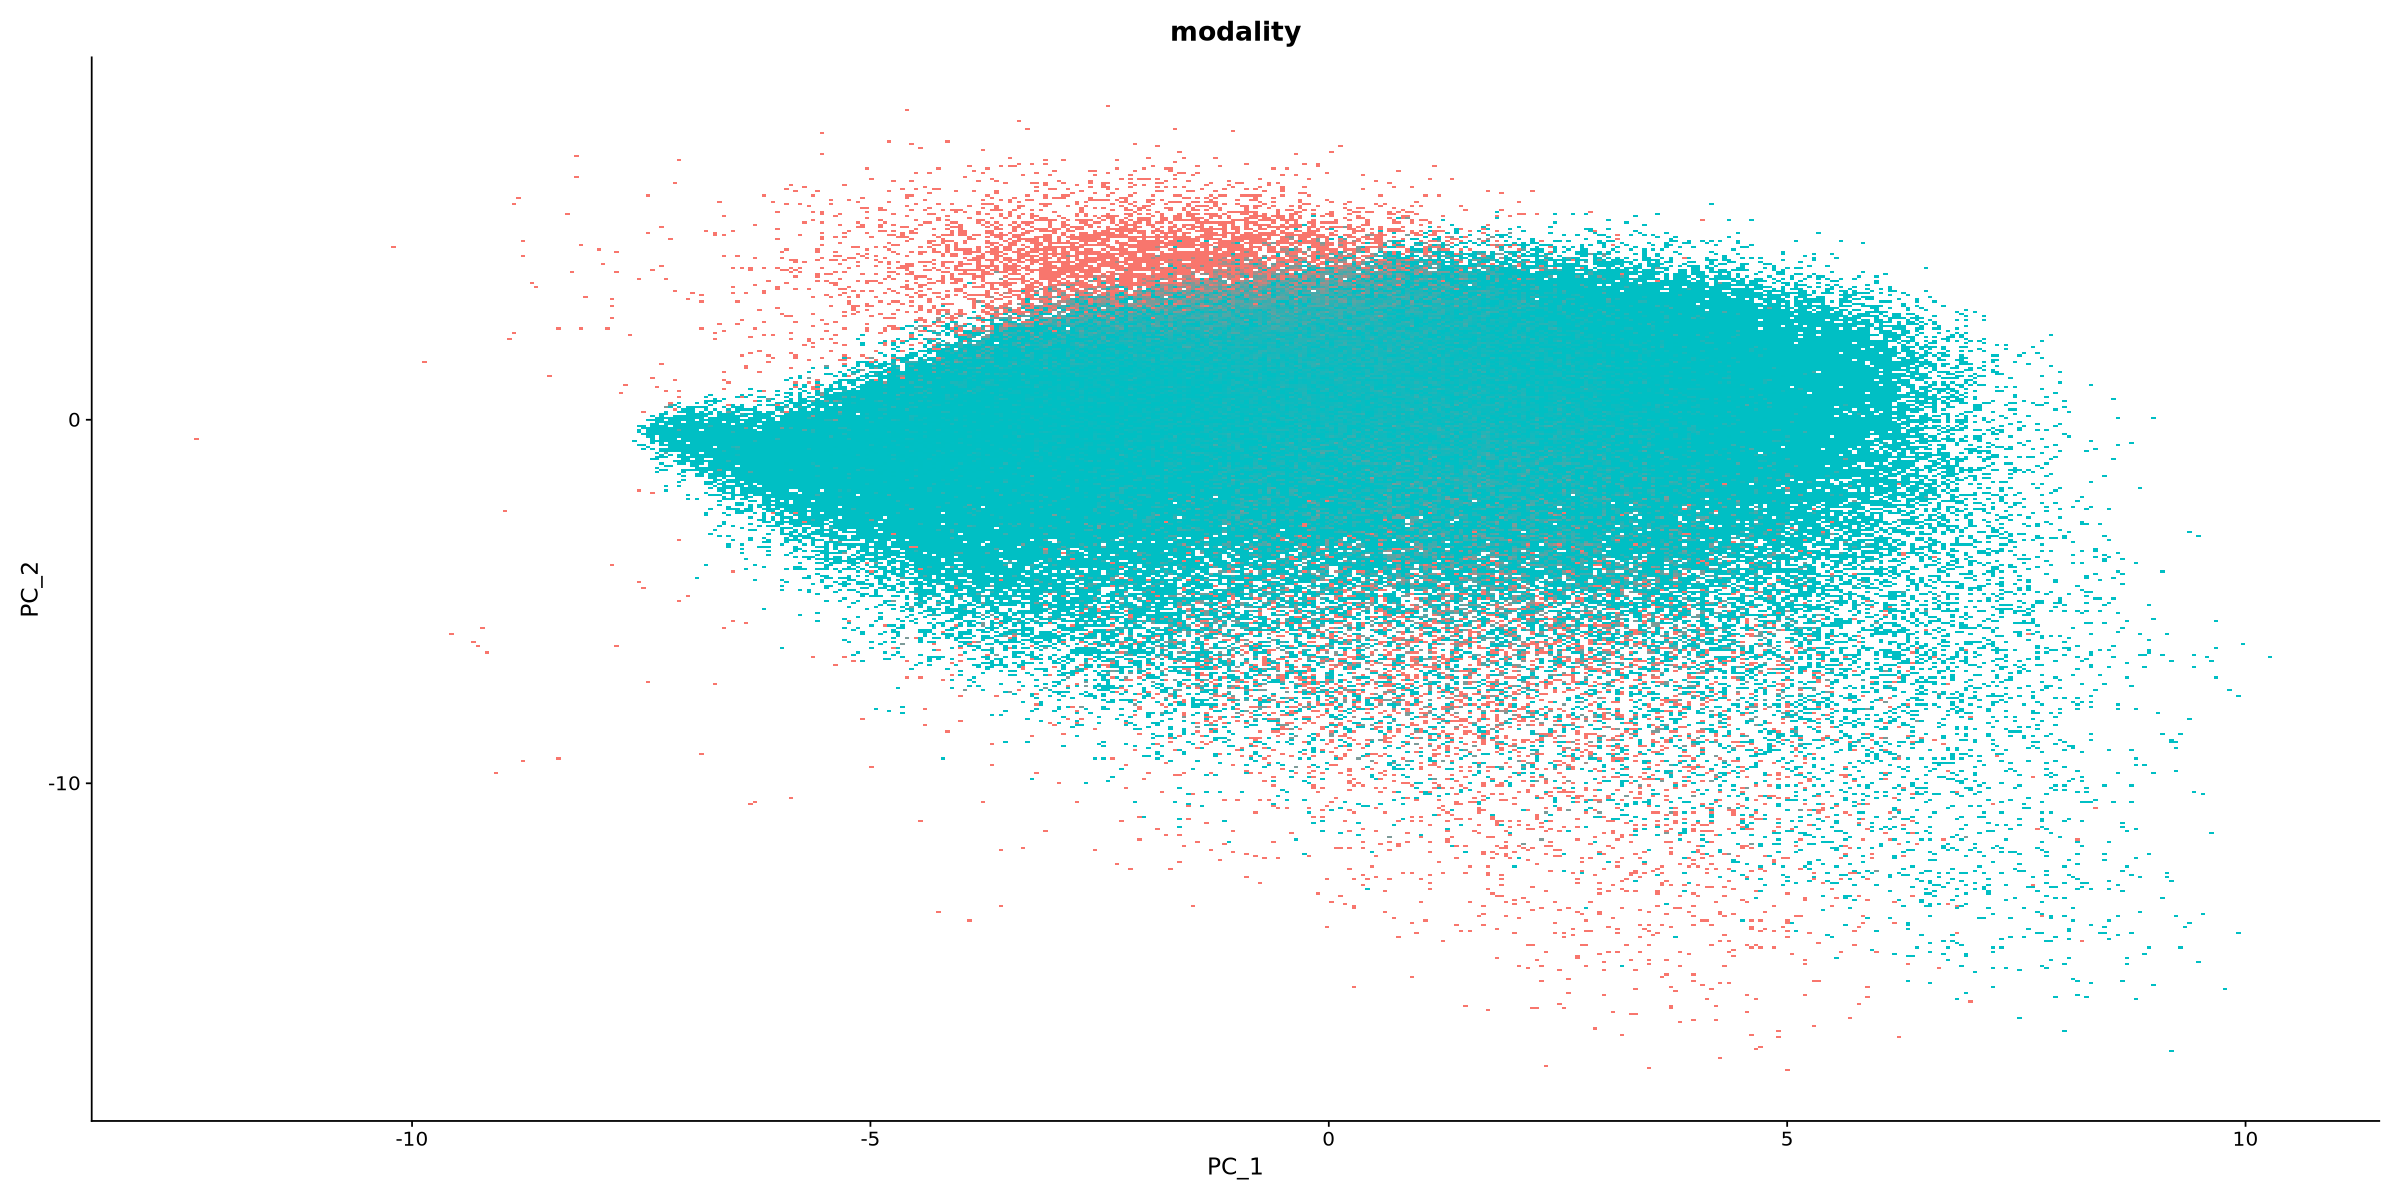

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[6/7] Running Harmony... 


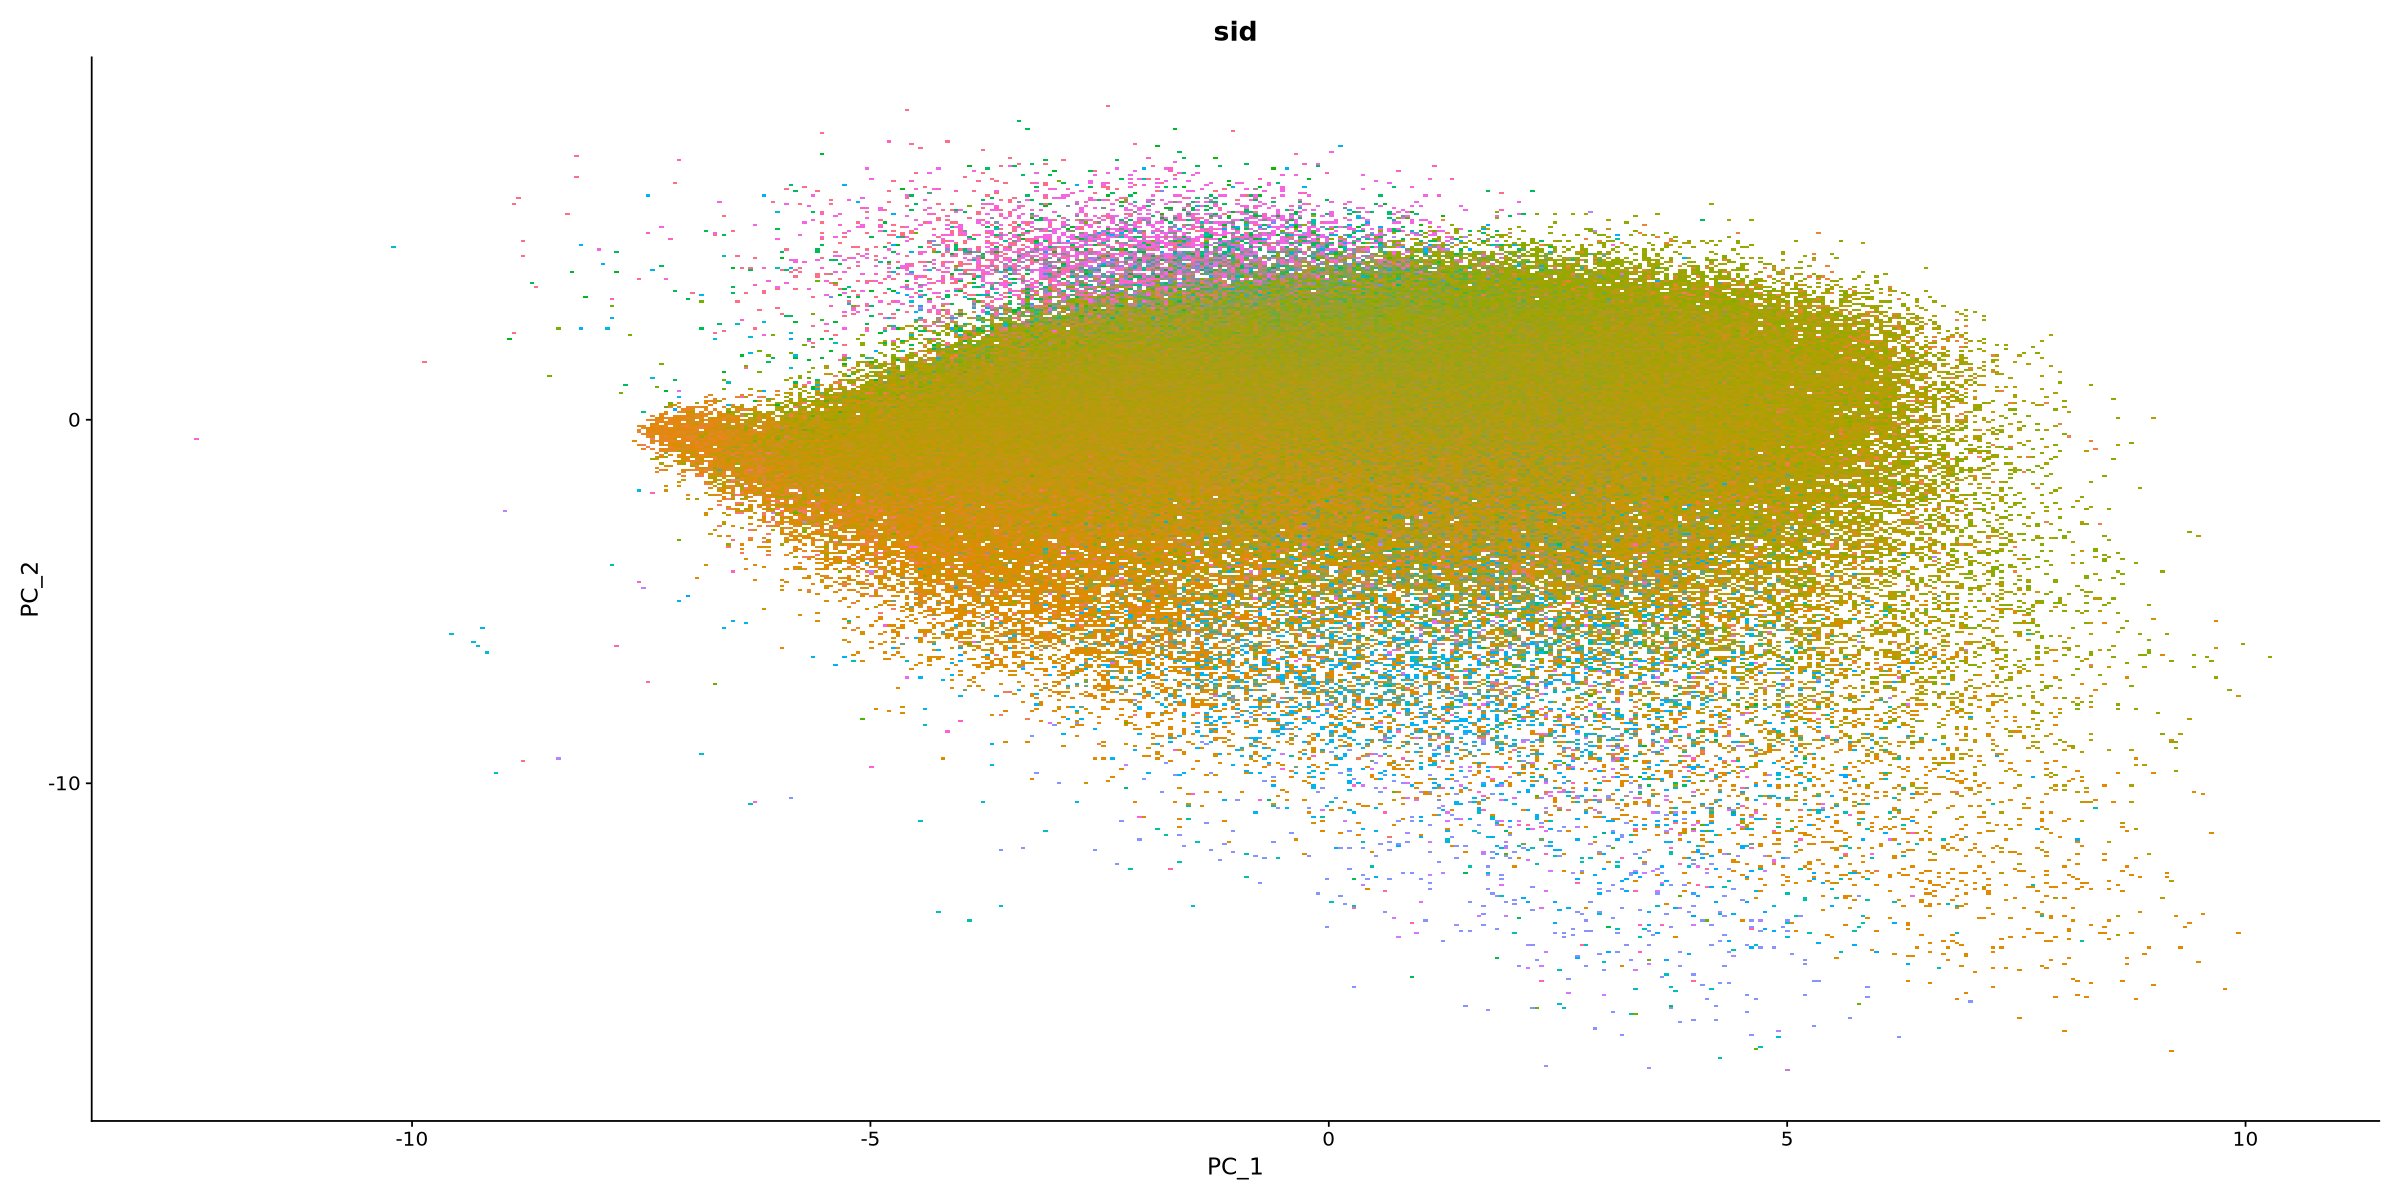

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 17562150)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10



  Printing Harmony diagnostic plots... 


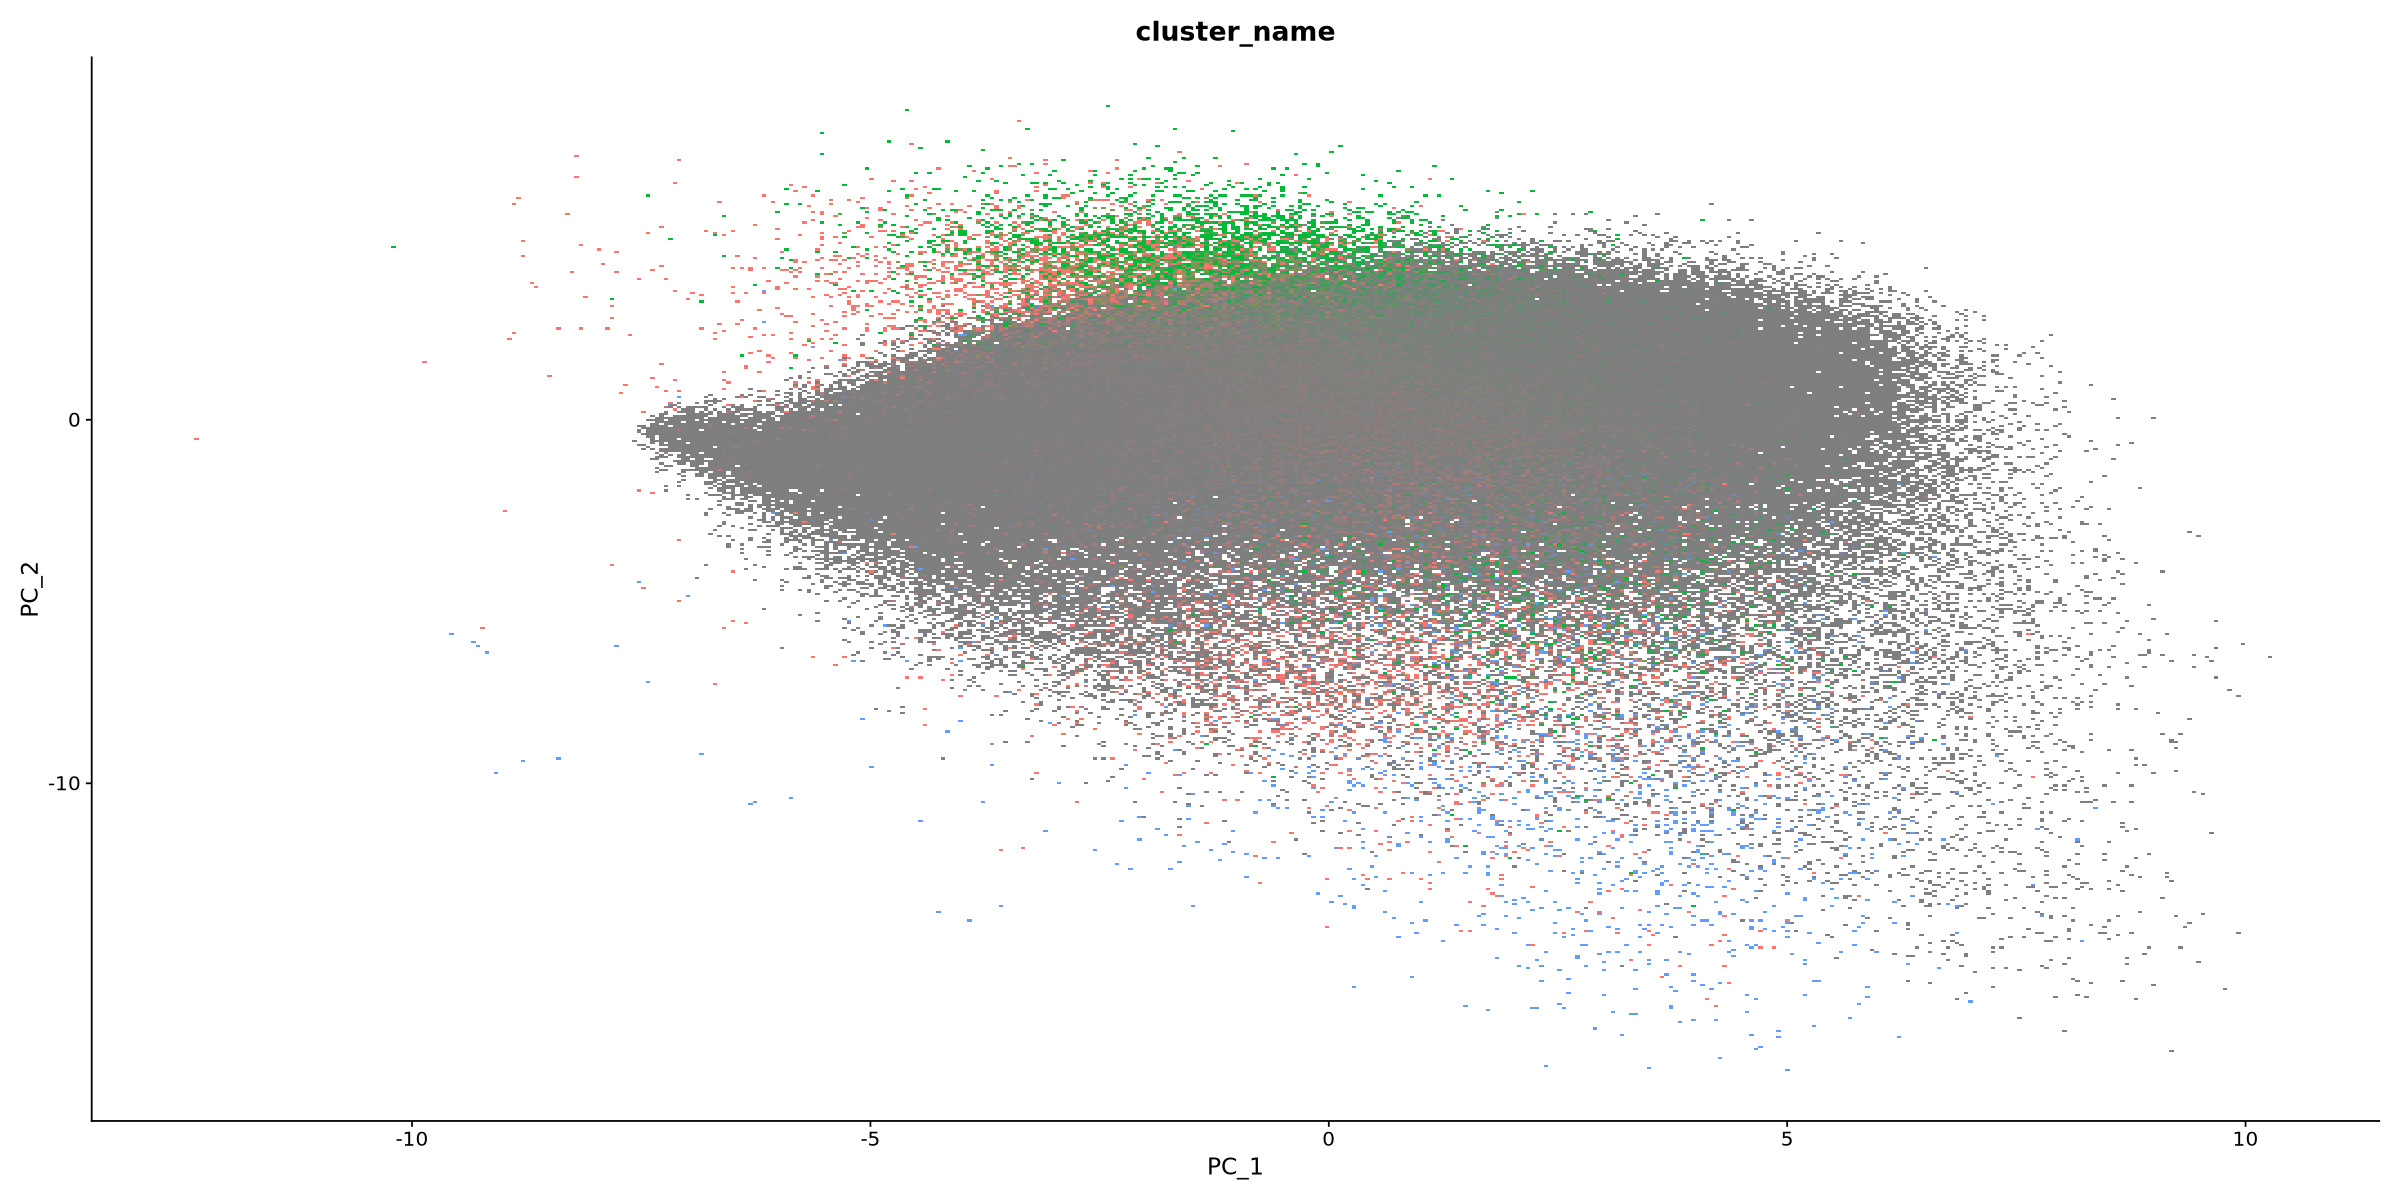

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



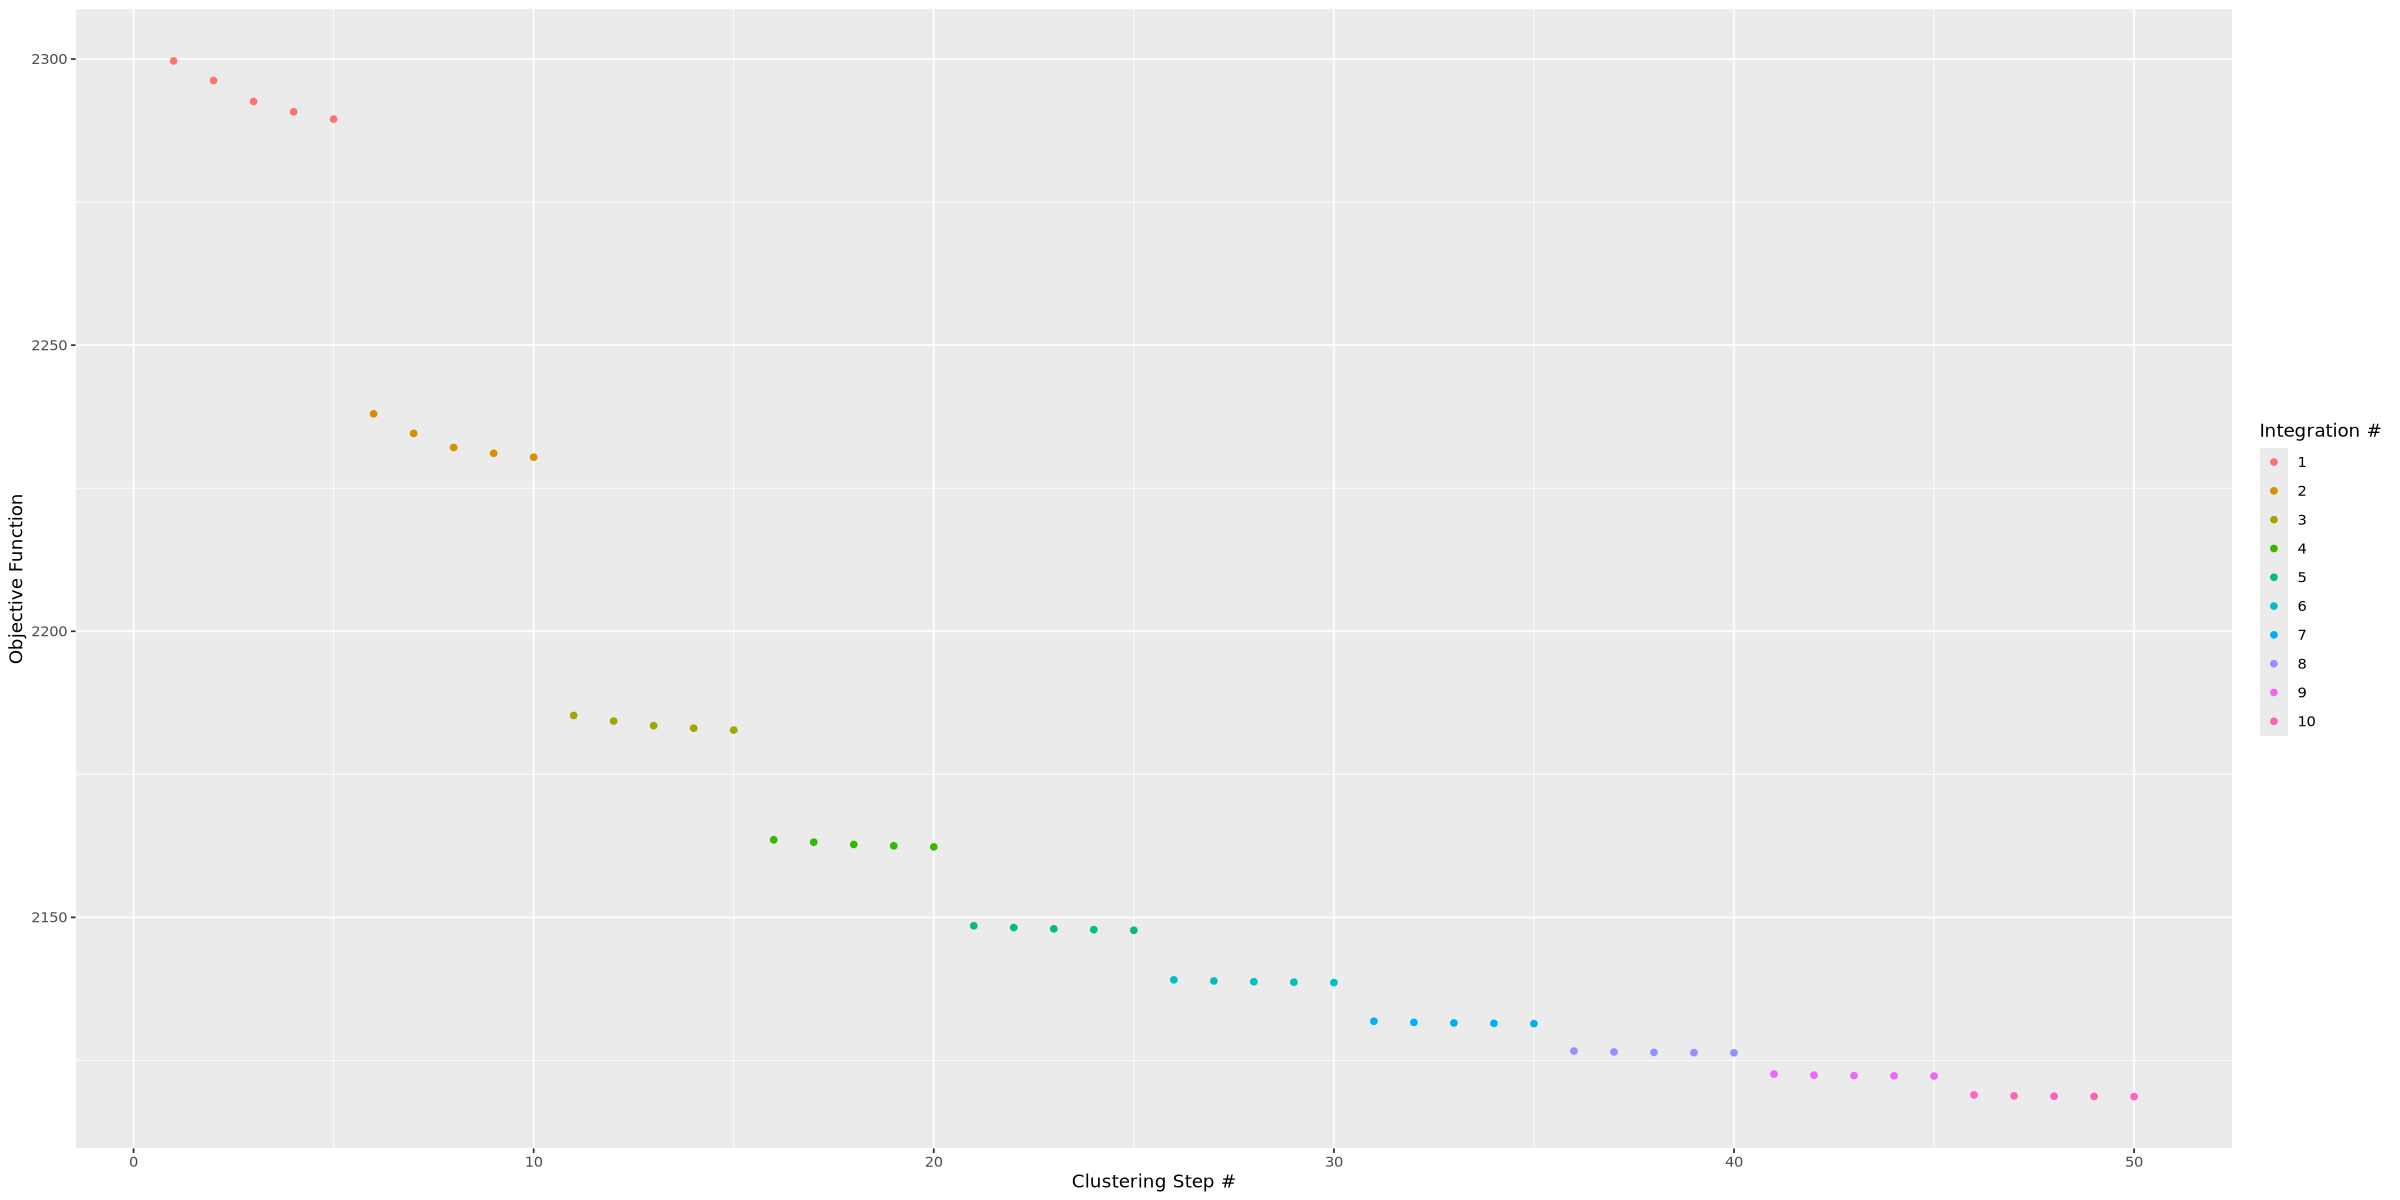

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



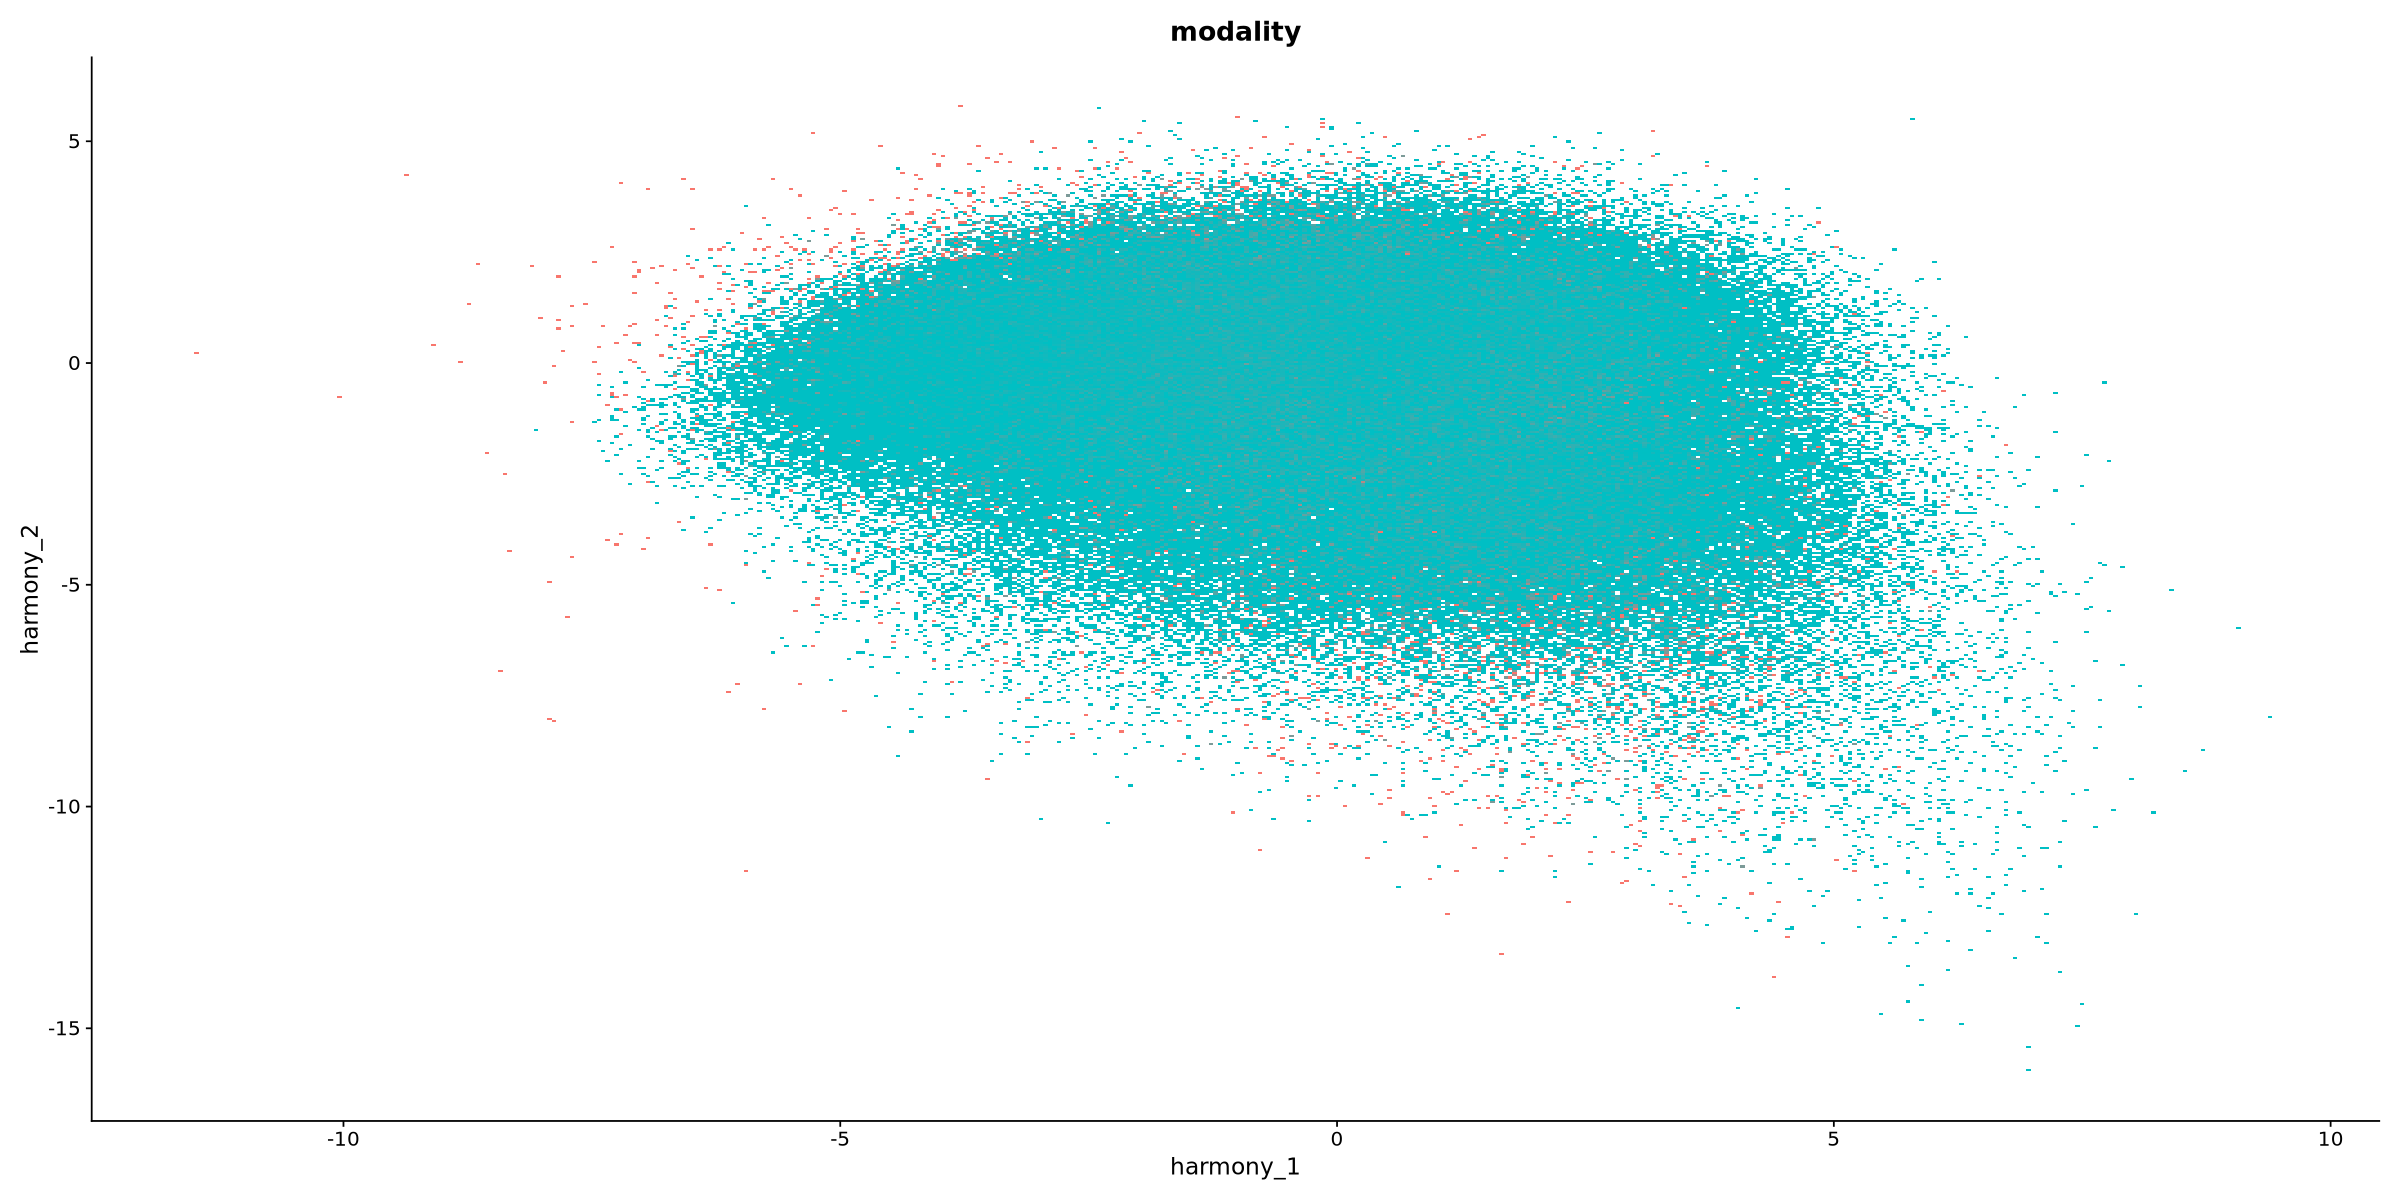

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`




[7/7] Running UMAP on the Harmony reduction... 


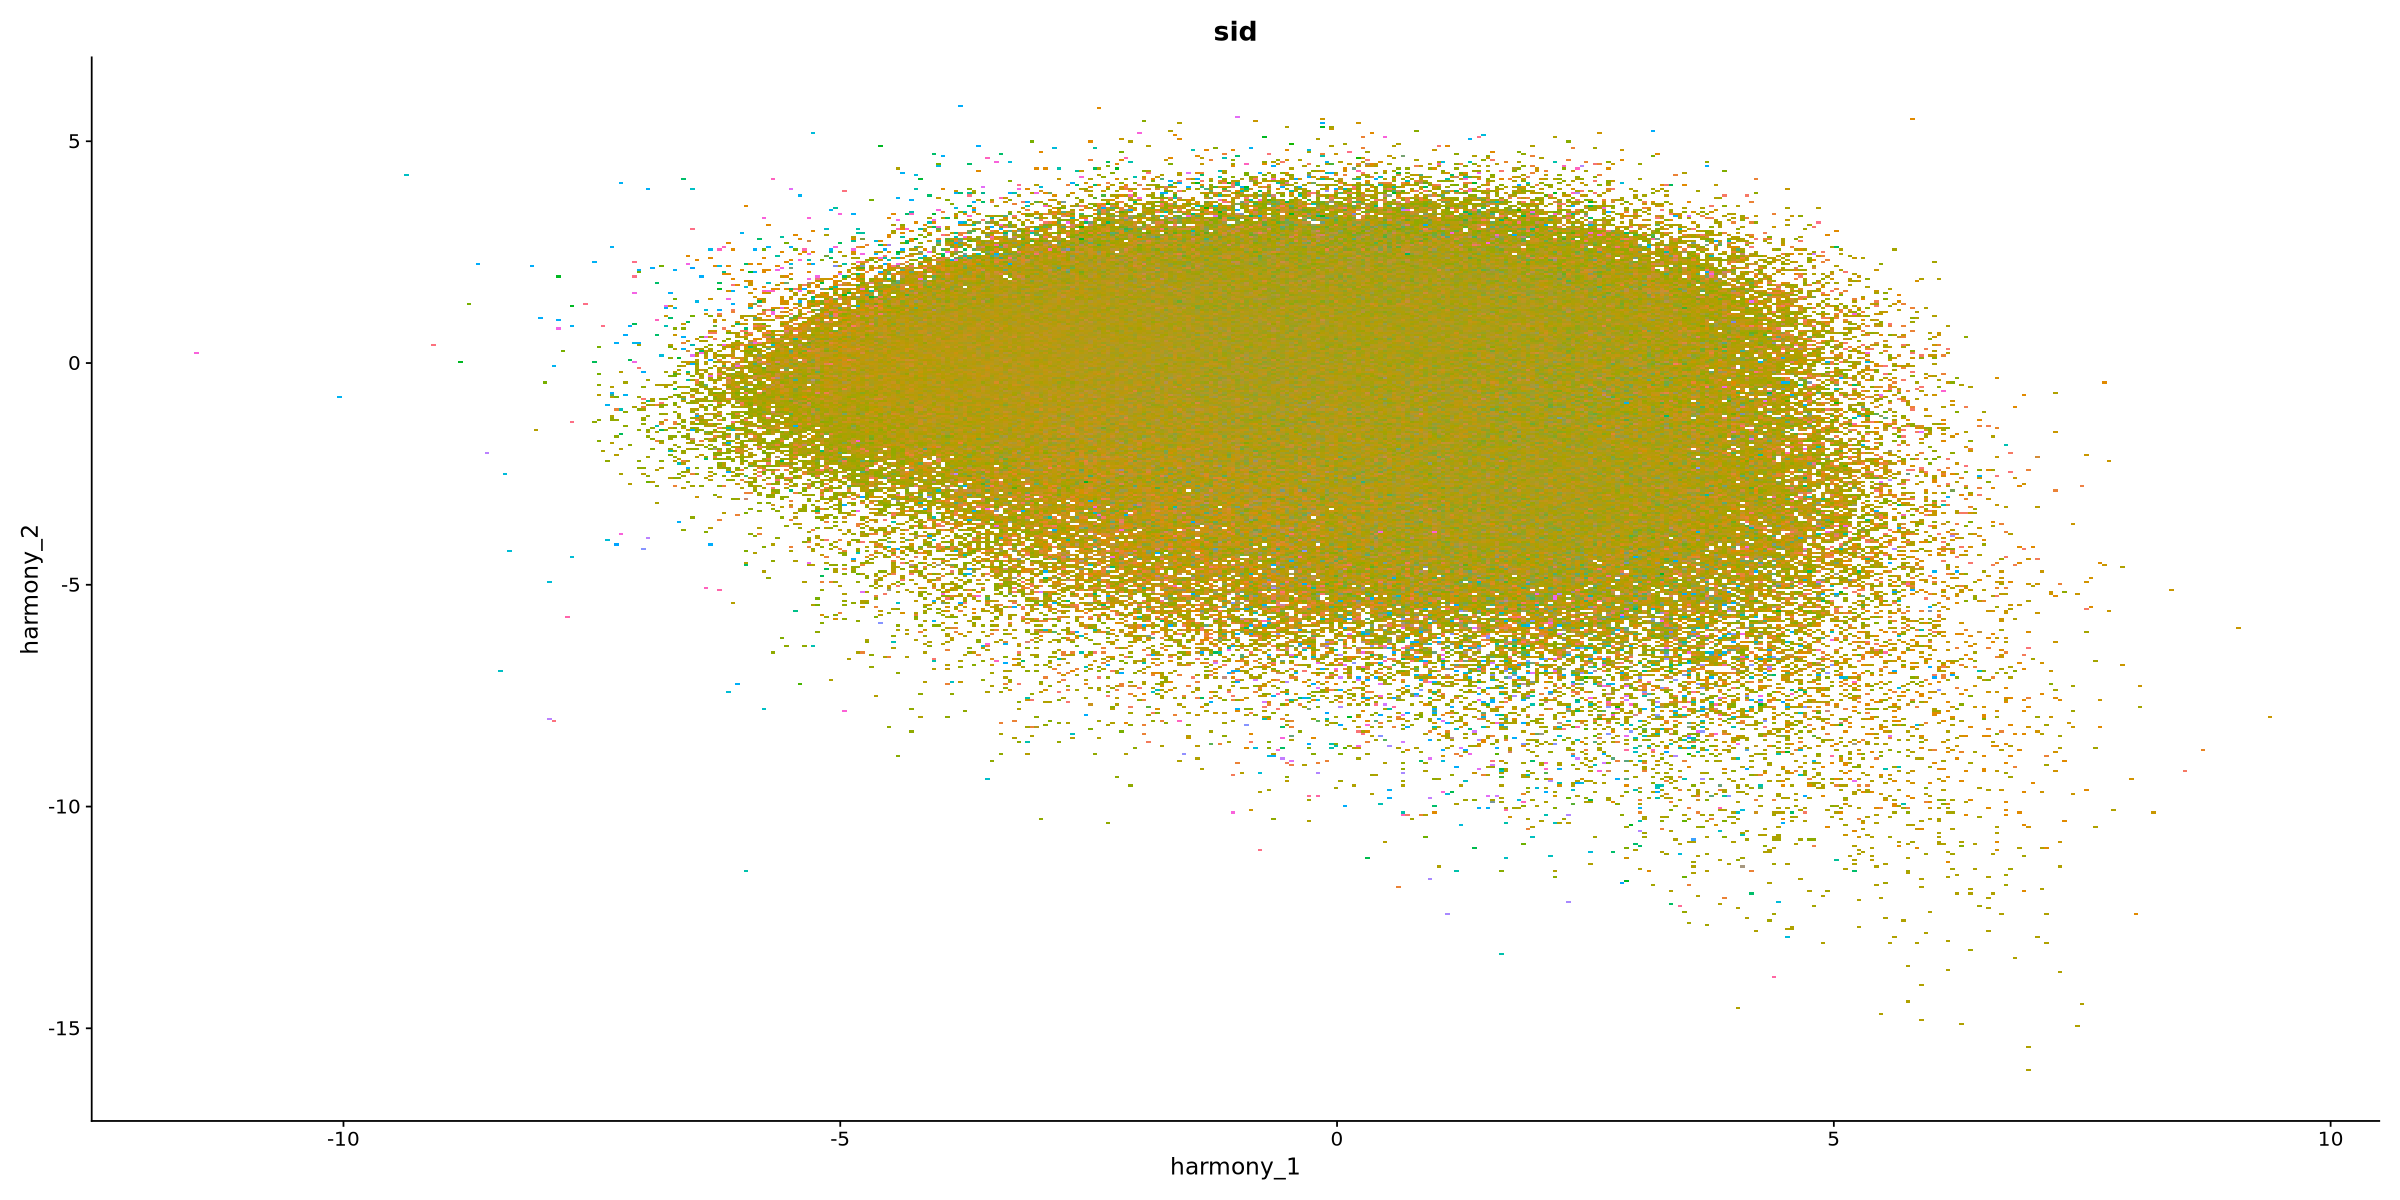

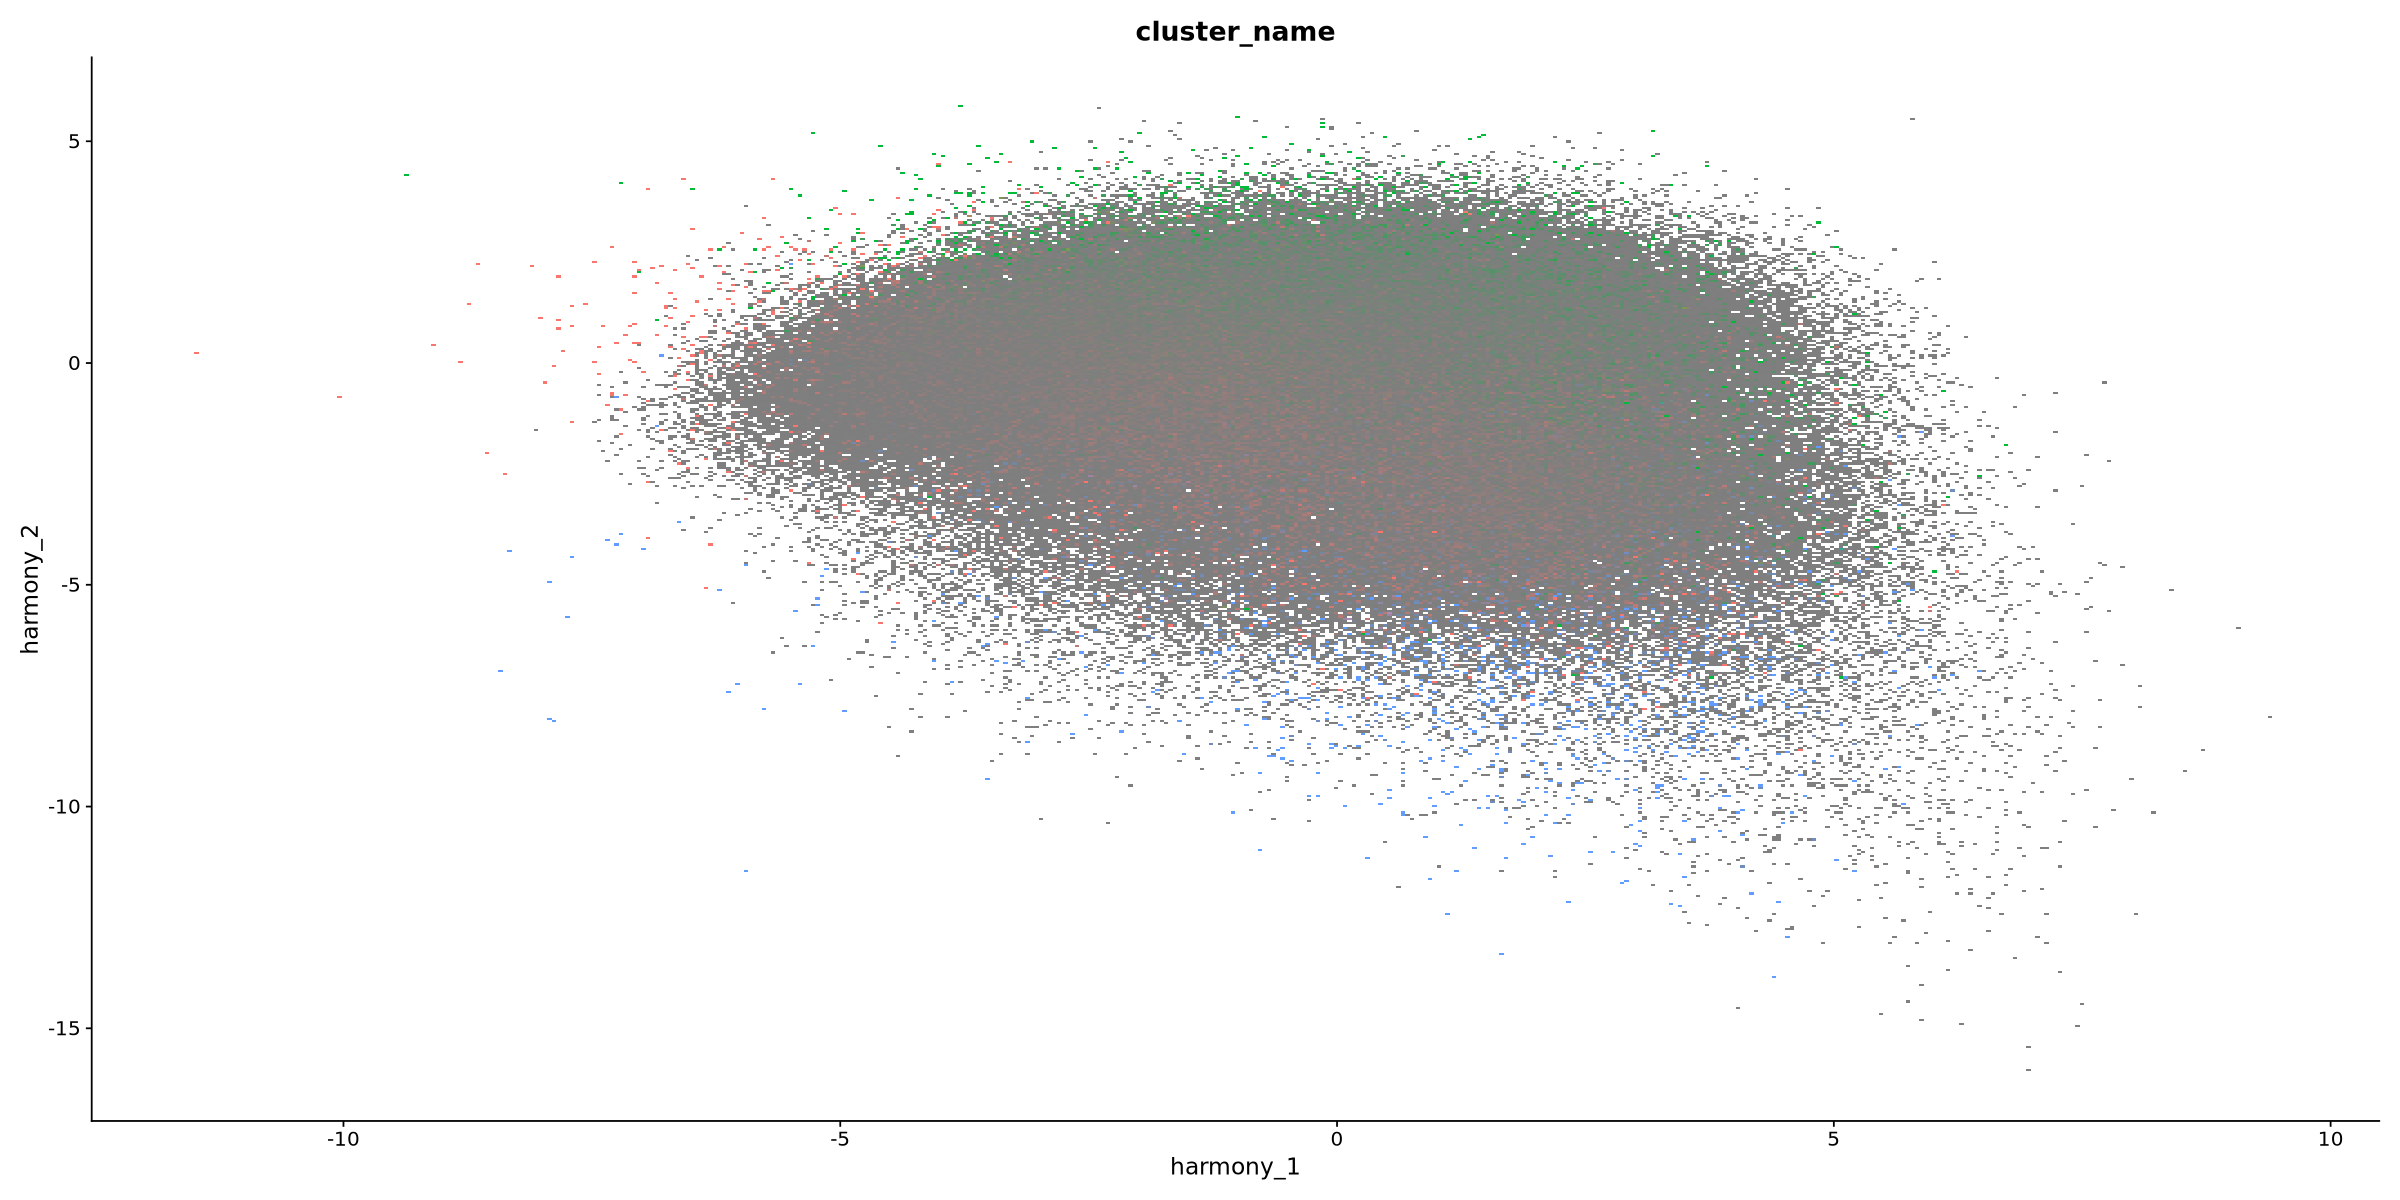

In [34]:
l_merged <- BuildIntegratedReference(
    xen = xen_l,
    sc = sc[, sc$cell_type == "Lining"],
    normalization_target = "mean_of_medians",
    hvgs = hvgs,
    annotation_var = "cluster_name"
)

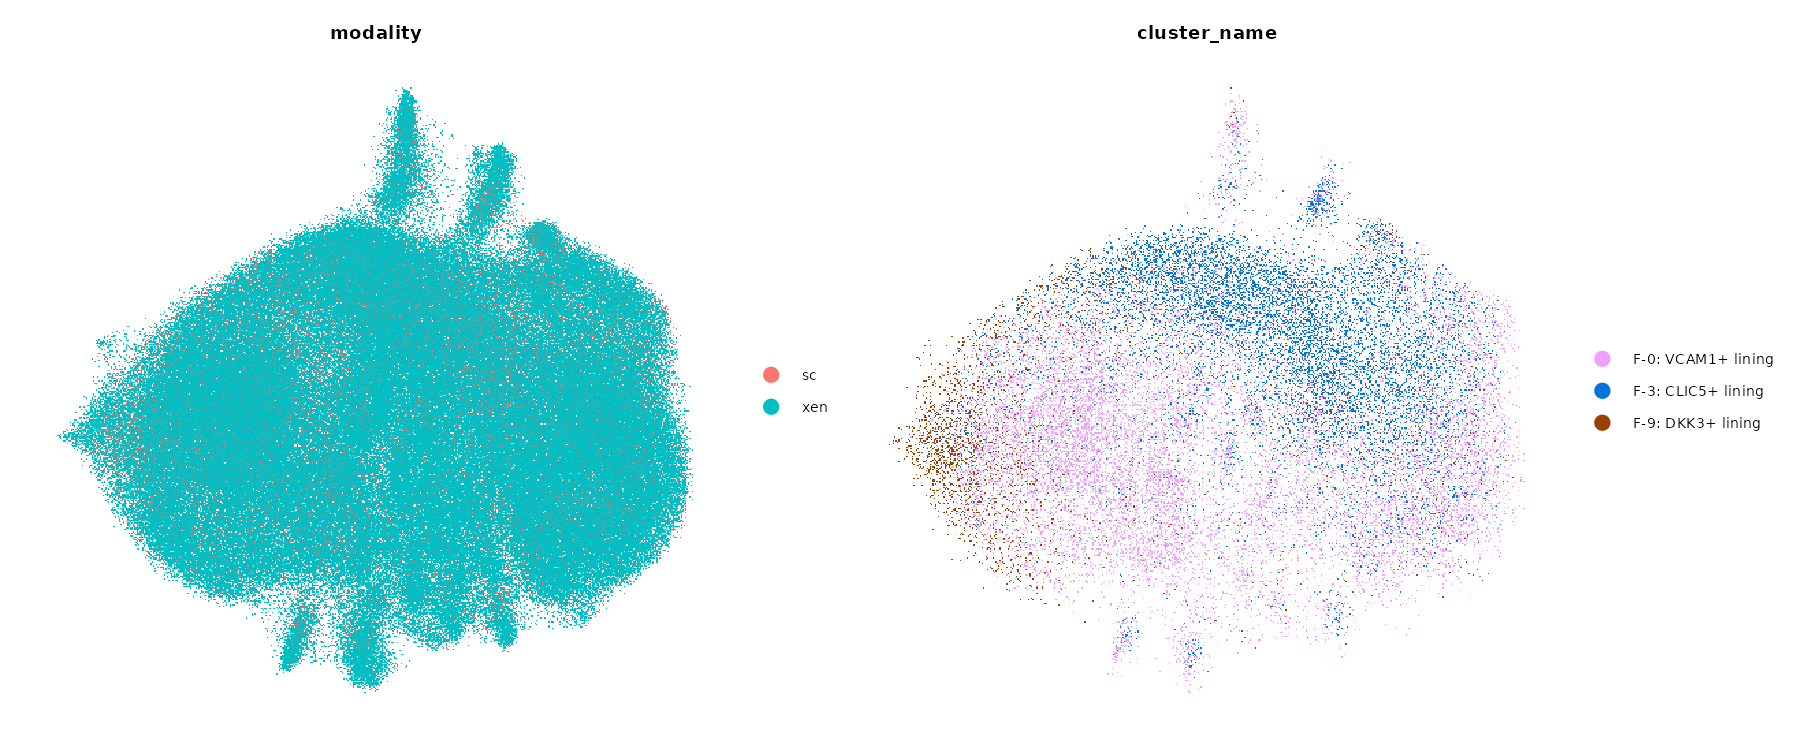

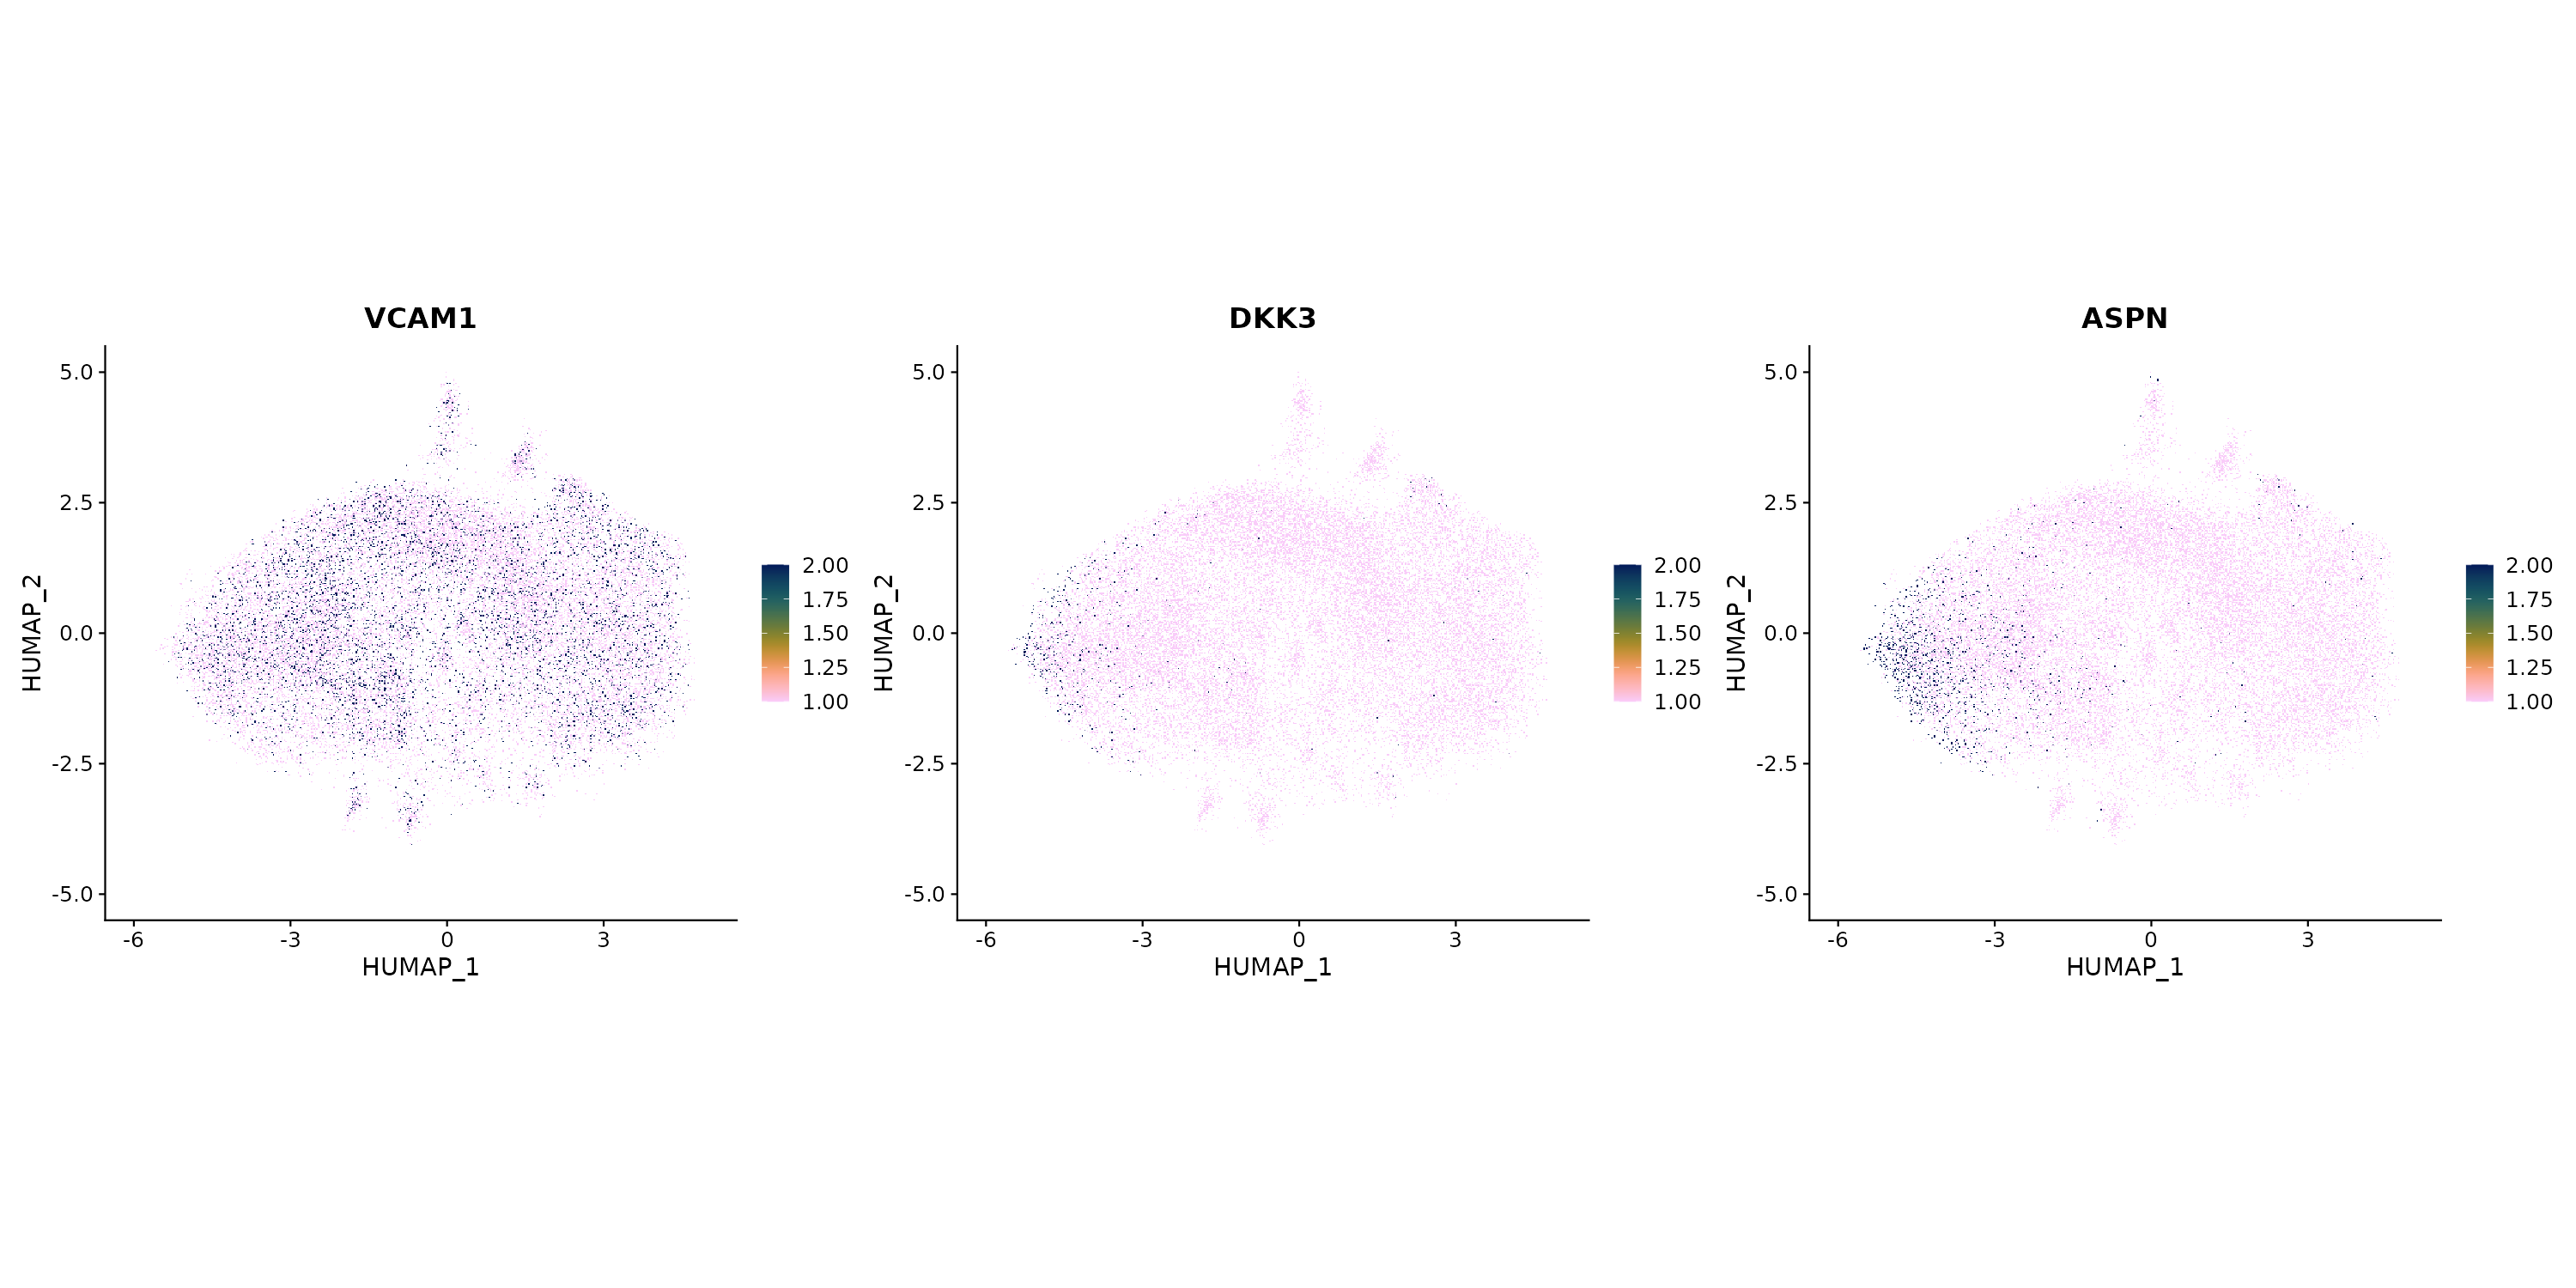

In [35]:
ShowTransferDiagnostics(
    merged = l_merged,
    annotation_var = "cluster_name",
    genes_to_visualize = c("VCAM1", "DKK3", "ASPN")
)

## Label transfer


[1/4] Checking inputs... 
  Using annotation variable: cluster_name 
  Using n_neighbors = 50 and min_ratio = 1.1 

[2/4] Computing nearest-neighbor graph from Harmony embedding... 
  Graph computation complete. 

[3/4] Transferring labels from sc cells to xen cells... 
  Labels written to: cluster_name 
  Xen cells without transferred labels: 38034 

[4/4] Plotting unlabeled cells and final xen label map... 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



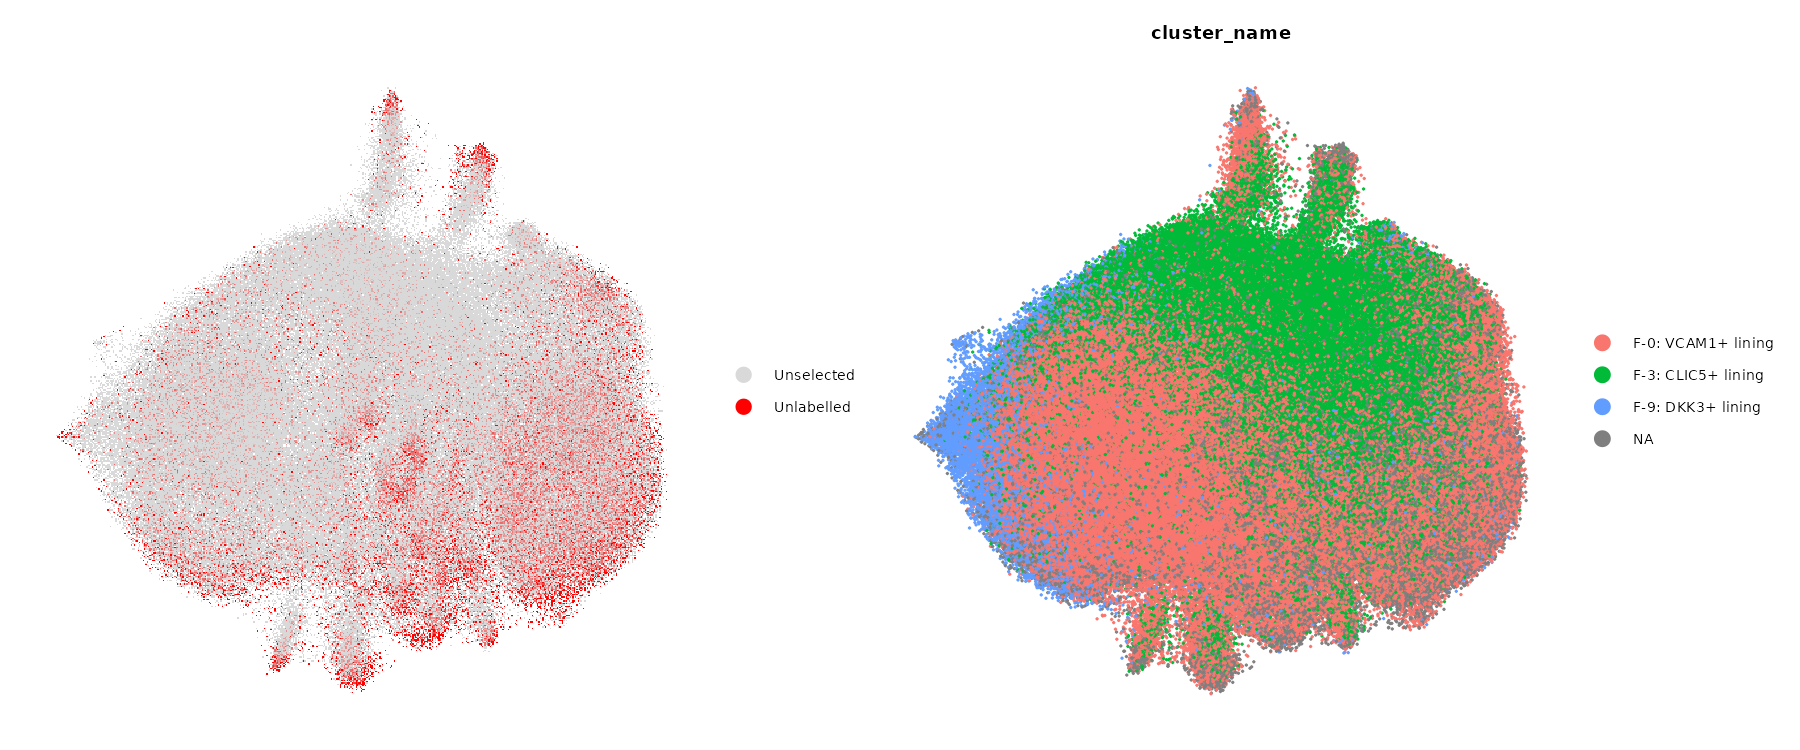

In [36]:
l_merged <- TransferLabelsGraph(
    merged = l_merged,
    annotation_var = "cluster_name",
    n_neighbors = 50,
    min_ratio = 1.1
)

## Examine marker genes

In [37]:
ShowClusterMarkers(l_merged[, l_merged$modality == "xen"], "cluster_name", n_show = 5)

Removing NA values from labels



row,F-0: VCAM1+ lining,F-3: CLIC5+ lining,F-9: DKK3+ lining
<int>,<chr>,<chr>,<chr>
1,CXCL12,PRG4,FMOD
2,WISP2,TIMP3,TNC
3,COL6A1,HBEGF,COL6A1
4,HLA-DRB1,ERRFI1,COMP
5,SOD2,GPR1,ASPN


Removing NA values from labels



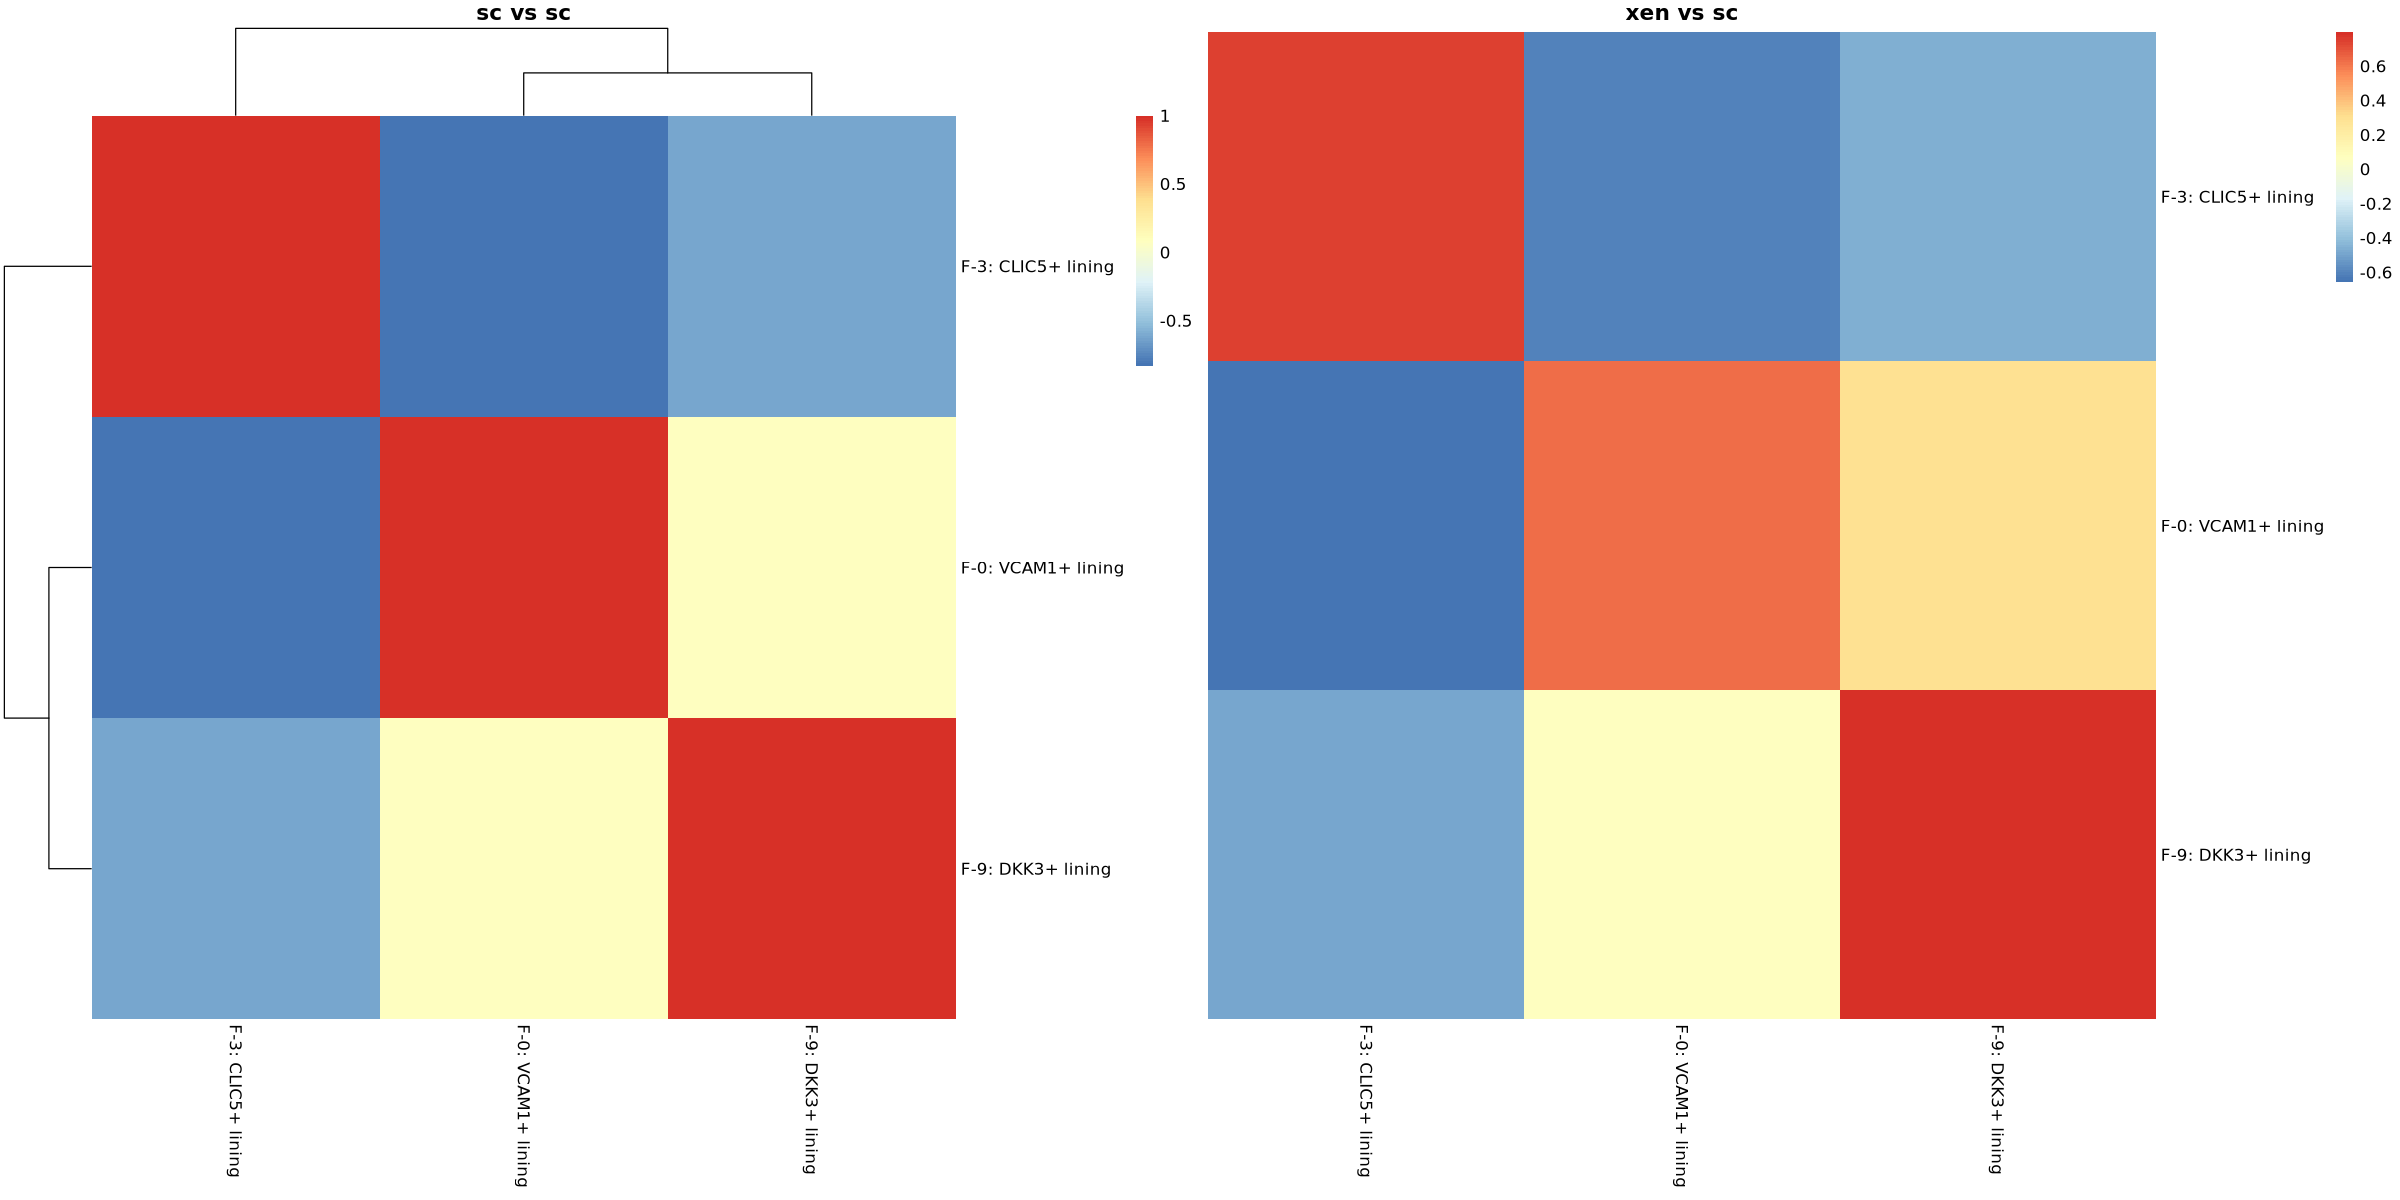

In [38]:
res <- CompareMarkerCorrelations(l_merged[,l_merged$modality == "xen"],
                                 l_merged[,l_merged$modality == "sc"], "cluster_name", bicluster = T)

## Save

In [39]:
xen_l@meta.data <- subset(
  xen_l@meta.data,
  select = -c(humap_fgraph_res.0.8, seurat_clusters)
)

colnames(l_merged) <- sub("^xen_", "", colnames(l_merged))

xen_l$celltype.fine <- l_merged$cluster_name[
  match(colnames(xen_l), colnames(l_merged))
]
xen_l[[]]$celltype.fine[is.na(xen_l[[]]$celltype.fine)] <- "F-10: Untyped lining"

In [40]:
saveRDS(xen_l, file = "out_rds/intermediate/_Lining_finetyped.rds")